# Causal-Structure-Oriented and Interpretable Modeling of Influenza Antigenic Distance

**A stability-ranked, confounding-audited, linkage-aware pipeline that ranks candidate HA escape drivers against linked hitchhikers across two H3N2 hemagglutination-inhibition datasets, with cross-validated interpretable prediction.**

This project was built as part of the [Claude Science Hackathon](https://cerebralvalley.ai/e/built-with-claude-life-sciences).

*A reproducible research notebook.* Run top-to-bottom (`Kernel → Restart & Run All`) to regenerate every table and
figure from the raw data repository shipped alongside this notebook.

## Abstract

Identifying the specific hemagglutinin (HA) mutations that causally alter antibody recognition remains a major challenge because dense viral phylogenies tightly link true escape drivers with passenger mutations. While sequence-based models can predict antigenic distance accurately, they typically conflate the evolutionary question of which mutations sweep a population with the mechanistic question of which mutations physically disrupt antibody binding. To probe this ambiguity, we frame the target as a provenance-independent, type-level interventional contrast at the antigen–antibody interface, accepting linkage-driven resolution loss as an inherent structural feature of observational serology rather than a pipeline defect. We analyze two H3N2 hemagglutination-inhibition (HI) datasets by collapsing co-evolving positions and applying target-oriented causal discovery (PC, GES, FCI) ranked by 200-resample bootstrap stability, paired with an interpretable B-spline Kolmogorov–Arnold Network (KAN) whose per-position response curves are directly inspectable and which extends to second order to visualize position-by-position epistasis. Under matched-fold cross-validation the first-order KAN trails black-box gradient boosting by a small but statistically robust margin (≈ 0.025–0.028 lower R²; Wilcoxon p < 10⁻⁵); a second-order KAN closes most of this gap, but only under a different 5-fold protocol, so the closure is suggestive rather than established. Cross-method convergence — agreement between one causal screen and three correlated association screens rather than four independent tests — flags candidate drivers overlapping classical antigenic sites A and B: in VHID the convergent pair sits at mature H3 positions 156 and 189, though 156 behaves as a stable hitchhiker (near-fixed frequency, small non-robust effect) rather than a driver while position 289 is the one doubly-robust candidate; in Bedford the convergent positions are mature 133, 158, and 189, with 158 fragile to encoding. Under cluster resampling, mature position 189 is the single most robust signal. Adjusted partial-regression effect sizes shrink systematically relative to marginal associations — a pattern consistent with, but not identifying, removal of phylogenetic confounding — and a Shipley d-separation test in fact rejects the sink structure from which the backdoor argument is read. Honest grouped (leave-serum-out) cross-validation places attainable accuracy well below random-split estimates (median R² ≈ 0.615 for VHID, ≈ 0.498 for Bedford). We therefore present this work as a stability-ranked, confounding-audited, linkage-aware feature-selection and interpretable-prediction pipeline that flags candidate biophysical drivers rather than a method that identifies causation, and we leave whether the recovered structure transports to prospective vaccine-strain selection to future evaluation.


## 1. Introduction

Influenza viruses evolve continuously under the selective pressure of population immunity, accumulating substitutions in surface glycoproteins that enable immune escape. This process of antigenic drift causes circulating strains to gradually diverge from those recognized by prior immunity, leading to a decline in vaccine effectiveness when the selected vaccine strain no longer matches circulating variants. This mismatch is a graded quantity termed antigenic distance, and measuring it accurately is a prerequisite for interpreting vaccine effectiveness and designing broadly protective vaccines. Traditionally, antigenic distance is measured using the hemagglutination-inhibition (HI) assay, in which a lower cross-titer indicates greater immune escape. While frameworks like antigenic cartography have been indispensable for mapping these titers, generating the required serum panels is slow, costly, and difficult to reproduce across laboratories. This logistical bottleneck has motivated a long line of sequence-based predictive models that forecast HI titers directly from hemagglutinin (HA) sequences. However, while modern machine learning approaches can achieve high predictive accuracy, they generally fail to explain why a strain escapes, as they identify which positions predict titer rather than which positions causally drive the change.

Because influenza strains share a dense phylogenetic history, HA positions are strongly linked, meaning a passenger mutation that merely rides along with a true escape driver looks just as predictive as the driver itself. To resolve this ambiguity, this study introduces a strict conceptual reframing. The common phrasing of identifying mutations that drive antigenic drift often conflates an evolutionary question (which substitutions were favored by natural selection and swept through the population) with a mechanistic one (which substitutions, if introduced into a strain, physically alter how strongly a specific antiserum recognizes it). This study focuses explicitly on the second, mechanistic question. We define our target estimand not as a historical claim about viral evolution, but as a provenance-independent, type-level interventional contrast at the antigen-antibody interface. Ideally, this contrast represents a precise biophysical experiment: take reference virus B, introduce the residue carried by virus A at a single HA position p while holding the rest of the protein fixed, and measure the resulting change in HI titer. The magnitude of this effect is dictated entirely by the chemistry of the structural footprint, regardless of whether that mutation arose via positive selection or as a neutral spontaneous variant. While evolutionary provenance is irrelevant to the biophysical effect itself, it is highly decisive for whether that effect can be identified from observational data. The virus's selective history acts as a major phylogenetic confounder, causing distinct mutations to co-occur within linkage blocks. Acknowledging this distinction allows us to treat linkage-driven resolution loss as an inherent structural feature of observational HI data rather than a flaw in the pipeline.

**Related works.** Antigenic cartography revealed the punctuated cluster structure of H3N2 drift by embedding HI tables into a low-dimensional antigenic map, and subsequent work unified antigenic and genetic evolution within a joint phylogenetic model. More recent sequence-based predictors forecast cross-immunity between drifted strains from sequence alone with strong accuracy. These approaches are primarily predictive or descriptive. They map, model, or forecast antigenic distance, but none explicitly learn causal structure over individual HA positions with quantified stability. The antigenic sites that those positions fall in were originally defined structurally and serologically, such as sites A to E on the H3 head, and were later refined at substitution resolution and by deep-mutational-scanning escape maps. We aim to see how far these same positions can be recovered structure-free, from HI titers alone. This approach is complementary to influenza fitness and phenotype-prediction models, which forecast strain frequencies or antigenic phenotypes but do not isolate per-position candidate drivers, and it builds directly on the intelligible-model literature for pairwise interactions.

**Our contributions.** We combine several ingredients that are not usually applied together for HI data to build a conservative, interpretable, and self-audited feature-selection pipeline. First, we implement linkage collapse with target-oriented causal discovery: we merge near-deterministic co-evolving positions into representative loci, then learn the direct-cause neighborhood of the HI target using PC, GES, and FCI algorithms, ranking every candidate by 200-resample bootstrap stability. Second, we deploy a genuine B-spline Kolmogorov–Arnold Network (KAN), an interpretable non-linear predictor whose learned per-position response curves are directly inspectable, and extend it to second order to capture and visualize position-by-position epistasis. Third, we assess cross-method convergence, treating it honestly as agreement between one causal screen and three *correlated* association screens (the KAN, gradient boosting, and univariate association) rather than four independent lines of evidence; positions flagged across these screens form our strongest candidate-driver claims. We then subject those claims to a battery of audits: a permutation calibration showing that the Fisher-z conditional-independence test holds near-nominal size on our binary, left-censored data; a cluster (by-virus and by-serum) bootstrap that separates a robust convergent core from an over-optimistic stability tier; a left-censoring sensitivity analysis of the adjusted effect sizes; and a token-level identifiability audit of the discovered structure. Throughout, we estimate backdoor-adjusted per-position effect sizes but report them as partial-regression coefficients, because the baseline adjustment assumptions are rejected in-sample. The result is a stability-ranked, confounding-audited, linkage-aware feature-selection and interpretable-prediction pipeline that flags candidate biophysical drivers, not a demonstration of identified causation.

The remainder of the notebook is organized as an executable paper. Section 2 (Methods) introduces the two H3N2 HI datasets and explains how their feature matrices are derived from the raw data. Section 3 (Results) then carries the analysis in full, each subsection stating how a step is performed, presenting its output, and interpreting it: the predictive benchmark and its leakage-free cross-validated comparison (§ [3.1](#3.1-Predictive-benchmark)–3.2); target-oriented causal discovery together with the pre-collapse linkage block sizes, a permutation calibration of the Fisher-z independence test, and a cluster bootstrap of candidate stability (§ [3.3](#3.3-Causal-discovery)), followed by the discovered dependency structure (§ [3.4](#3.4-The-discovered-dependency-structure)); the interpretable B-spline KAN and its second-order epistasis extension (§ [3.5](#3.5-Interpretable-prediction:-a-B-spline-KAN)–3.6); cross-method convergence (§ [3.7](#3.7-Cross-method-convergence)); backdoor-adjusted effect sizes and their sensitivity to titer left-censoring (§ [3.8](#3.8-Backdoor-adjusted-effect-sizes)); three DAG-validation tests (§ [3.9](#3.9-Validating-the-causal-structure)); and a continuous per-position encoding that re-examines the titer Markov blanket (§ [3.10](#3.10-Continuous-per-position-encoding-and-the-titer-Markov-blanket)). The narrative moves from how much of the HI signal is learnable and how non-linear it is, through the discovered candidate drivers and their audited dependency structure, to per-position effect sizes and the validation — and in-sample rejection — of the discovered graph. Section 4 (Conclusion) interprets the convergent positions biologically, states plainly where residue-level attribution is limited and what assumptions the causal framing rests on, and looks ahead. Section 5 lists references.


## 2. Methods

This section describes the data. We introduce the two HI panels and how their
per-position feature matrices are prepared from raw sequence data; the analytical
procedures that consume these matrices are described step-by-step in the Results
section, where each is presented alongside the output it produces. Configuration
(random seed, linkage threshold, bootstrap count, tier cutoffs) is centralized in
`src/analysis.py`, and two expensive steps — the causal bootstrap (`RECOMPUTE_CAUSAL`,
the H3N2 60-locus graph takes ~30 min) and the repeated k-fold cross-validation
(`RECOMPUTE_CV`, ~40 min) — are gated behind environment flags, loading shipped
`results/` artifacts by default so a full top-to-bottom run is fast and deterministic.

### 2.1 Datasets

The study uses two H3N2 virus × reference-strain HI panels, each shipped in the data
repository as per-position HA1 feature matrices with two encodings. The **binary
mismatch** encoding sets a position to `1` when the virus and reference residues differ
at that HA1 alignment position and `0` otherwise, and is used for causal discovery. The
**Grantham** encoding gives the Grantham (1974) physicochemical distance between the two
residues (gap-aware), and is used for predictive modeling and the KAN response curves.
The final column of every matrix is the raw `HI_titer`; we model `log2(HI_titer)`. The
two study datasets map to the repository as **VHID H3N2** → `VHID/` (n=2751) and **Bedford
H3N2** → `Bedford/H3/` (n=7808). **Provenance.** The VHID panel derives from the DPCIPI
release (arXiv:2302.00926); its HA sequences carry GenBank accessions but no
collection-year metadata (0/2751 pairs), which bounds the temporal analyses below to the
year-stamped Bedford panel. We begin by importing the analysis module and fixing
configuration.

**Numbering note.** Throughout, results prose reports **mature H3 residue numbers**; the
feature matrices are indexed by HA1 alignment column, and the two differ by a fixed
per-panel offset. The VHID reference is gapless from mature Q1, so its columns equal
mature H3 residues (offset 0). The Bedford H3N2 alignment carries a 9-residue
signal-peptide prefix and one internal gap (column 17), so mature Q1 sits at column 10
and, for every position reported here (all ≥ column 143), **mature residue = column − 10**
(e.g. columns 143/168/199 → mature 133/158/189). The offset is a uniform −10 only from
column 18 onward; columns 10–16 carry −9 because of the single alignment gap at column 17,
but no reported position falls below column 143, so the constant −10 applies throughout.
This was verified against the column-wise consensus reference (`SYILCLVFAQKLPGND-NST…`,
matched by 119/122 Bedford reference strains at the study columns) and the gapless VHID
references (45/45 at offset 0). Feature spaces remain strictly per-panel; the mapping is
provided only for biological interpretation.

#### Provenance and assay conditions

Both panels are H3N2 hemagglutination-inhibition (HI) datasets, but they differ in
provenance and in how much of the assay context can be audited. The **Bedford H3N2**
panel is the curated HI table from Bedford et al. (2014, *eLife*; github.com/trvrb/flux),
with GISAID/GenBank accessions and isolate collection years populated for every pair.
The **VHID** panel is drawn from the DPCIPI dataset (Du et al., *DPCIPI*, arXiv:2302.00926);
each strain carries a GenBank protein accession (e.g. AY661038), but the cleaned pair
table has **no per-pair isolate collection year** (0/2751 populated), and neither panel
records the **RBC species** used in the assay or whether the sera are **ferret or human**.
Those assay conditions therefore cannot be audited for either panel, and the absence of
collection-year metadata means the VHID panel cannot be split or blocked by era. We report
titers as provided and treat the two panels as independent replications of the same
structure-learning question rather than as calibrated to a common assay protocol.

In [6]:
# Provenance / assay-conditions table for both H3N2 panels (reads cleaned pair tables; <2 s)
import os, pandas as pd
_paths = {"VHID H3N2":   ("vhid_HA1", "VHID/vhid_hi_dataset_HA1_cleaned.csv"),
          "Bedford H3N2":("H3N2",     "Bedford/H3/H3_clean_pairs.csv")}
def _avail(df, col):
    if col not in df.columns: return "absent"
    ok = df[col].notna() & (df[col].astype(str).str.strip() != "") & (df[col].astype(str).str.lower() != "nan")
    return f"{int(ok.sum())}/{len(df)}"
_rows = []
for label, (key, rel) in _paths.items():
    df = pd.read_csv(os.path.join(A.DATA_DIR, rel))
    _rows.append(dict(
        panel=label, dataset_key=key,
        data_source=df["data_source"].dropna().iloc[0],
        citation=df["citation"].dropna().iloc[0],
        subtype=df["subtype"].dropna().iloc[0],
        n_pairs=len(df),
        n_unique_viruses=int(df["virus"].nunique()),
        n_unique_reference_strains=int(df["reference_strain"].nunique()),
        virus_accession=_avail(df, "virus_accession"),
        ref_accession=_avail(df, "reference_accession"),
        collection_year=_avail(df, "virus_year"),
        rbc_species="absent", sera_type="absent"))
provenance = pd.DataFrame(_rows).set_index("panel").T
provenance.to_csv("results/provenance_assay_conditions.csv")
print(provenance.to_string())

panel                                                                        VHID H3N2                                        Bedford H3N2
dataset_key                                                                   vhid_HA1                                                H3N2
data_source                                                           VHID_DPCIPI_2020                                   Bedford_2014_H3N2
citation                    DPCIPI: Pre-trained deep learning model (arXiv:2302.00926)  Bedford et al. (2014) eLife. github.com/trvrb/flux
subtype                                                                           H3N2                                                H3N2
n_pairs                                                                           2751                                                7808
n_unique_viruses                                                                   246                                                 304
n_unique_reference_strains 

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, "src")
import analysis as A
A.DATASETS = ["vhid_HA1", "H3N2"]  # the two H3N2 study panels

# quiet, reproducible
import warnings; warnings.filterwarnings("ignore")
np.random.seed(A.SEED)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False})
COLORS = {"LASSO": "#7fb3d5", "Ridge": "#5499c7", "XGBoost": "#e67e22",
          "KAN": "#c0392b", "causal": "#c0392b"}

print("Datasets in this study:", A.DATASETS)
print("Data directory:", os.path.relpath(A.DATA_DIR, A.REPO_ROOT))
print("Recompute causal from scratch:", A.RECOMPUTE_CAUSAL)

Datasets in this study: ['vhid_HA1', 'H3N2']
Data directory: influenza-hi-antigenic-distance
Recompute causal from scratch: False


#### 2.1.1 Reproducing the feature matrices from raw data

So that the study starts from raw data rather than shipped derivatives, we regenerate
the feature matrices from the cleaned virus × reference pair tables using the
repository's own build scripts (`scripts/build_vhid_matrices.py`,
`scripts/build_bedford_matrices.py`), which depend only on numpy and pandas. Running
them here makes the matrices provably the shipped ones (verified by SHA-256).

In [2]:
# Regenerate the matrices from the cleaned pair tables (idempotent; ~seconds), and PROVE
# the regenerated files are bit-for-bit the shipped ones by SHA-256 (hash before rebuild,
# rebuild, hash after, assert equality per file).
import hashlib
def _sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

_matrix_paths = [os.path.join(A.DATA_DIR, p) for ds in A.DATASETS for p in A.DATASET_PATHS[ds]]
_before = {p: _sha256(p) for p in _matrix_paths if os.path.exists(p)}
A.rebuild_matrices_from_raw(verbose=False)  # verbose=False: build script also rebuilds other out-of-scope panels; we don't print those
_after = {p: _sha256(p) for p in _matrix_paths}
_mismatch = [os.path.basename(p) for p in _before if _before[p] != _after.get(p)]
assert not _mismatch, f"SHA-256 mismatch after rebuild: {_mismatch}"
print(f"SHA-256 verified: all {len(_before)} feature matrices regenerate bit-for-bit "
      f"from raw (e.g. {os.path.basename(next(iter(_before)))} = {next(iter(_before.values()))[:16]}\u2026)")

data = A.load_all()

summary = pd.DataFrame([
    dict(dataset=ds, source=A.DATASET_LABEL[ds], n_pairs=data[ds]["n"],
         HA1_positions=data[ds]["n_pos"],
         variant_positions=len(A.variant_columns(data[ds]["Xb"])),
         log2_titer_mean=round(float(data[ds]["y"].mean()), 3),
         log2_titer_std=round(float(data[ds]["y"].std()), 3))
    for ds in A.DATASETS])
summary


SHA-256 verified: all 4 feature matrices regenerate bit-for-bit from raw (e.g. vhid_HA1_binary_HImatrix.csv = 6eff47472a14e41c…)
Out[2]: 
    dataset  ... log2_titer_std
0  vhid_HA1  ...          2.861
1      H3N2  ...          2.286

[2 rows x 7 columns]


,dataset,source,n_pairs,HA1_positions,variant_positions,log2_titer_mean,log2_titer_std
0,vhid_HA1,VHID H3N2 (Du et al. 2023),2751,329,102,7.256,2.861
1,H3N2,Bedford H3N2 (Bedford et al. 2014),7808,329,312,7.770,2.286


Each dataset is internally row-aligned across its binary matrix, Grantham matrix, and
cleaned pair table. Feature spaces are comparable *within* a lineage but not across
lineages (each lineage was HA1-trimmed against its own reference), so we analyze the
two datasets independently and compare only which HA positions emerge.

#### 2.1.2 The target distribution

Before any modeling we look at what is being predicted. The panel below shows the
distribution of log2 HI titer in each dataset; its spread sets the scale against which
every R² reported in the Results should be read.

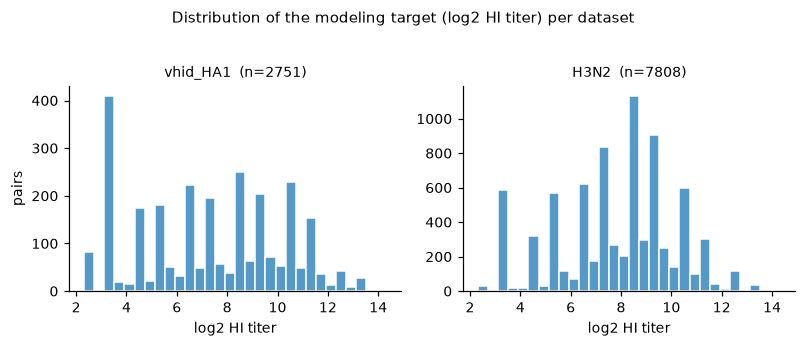

In [3]:
fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(3.7*len(A.DATASETS), 3))
for ax, ds in zip(axes, A.DATASETS):
    ax.hist(data[ds]["y"], bins=30, color="#5499c7", edgecolor="white")
    ax.set_title(f"{ds}  (n={data[ds]['n']})", fontsize=9)
    ax.set_xlabel("log2 HI titer"); ax.set_ylabel("pairs" if ds == A.DATASETS[0] else "")
fig.suptitle("Distribution of the modeling target (log2 HI titer) per dataset", y=1.03, fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(A.FIG_DIR, "target_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

## 3. Results

We now walk through each analytical step and report what it produced. Because the
Methods section covers only the data, each subsection below opens by stating *how* the
step is done, then presents its output and interprets it — moving from *prediction* to
*cause*: first how much of the HI signal is learnable and how nonlinear it is, which
fixes what any mechanistic account must explain; then the positions that plausibly
*drive* the signal and their dependency structure; then the interpretable predictor and
the epistasis it exposes; and finally the convergent driver claims, their
confounding-adjusted effect sizes, and the validation of the discovered graph. No number
or figure is presented without interpreting how it supports the point.

### 3.1 Predictive benchmark

We first establish how much of the HI signal is learnable and whether it is
multivariable and nonlinear. For each dataset we compare, on a held-out 20% test split,
the best single position (max univariate R²), LASSO, Ridge, and XGBoost.

The benchmark below reports, for each dataset, the held-out test R² of the best single
position, LASSO, Ridge, and XGBoost.

In [4]:
bench = {ds: A.benchmark(data, ds) for ds in A.DATASETS}
bench_tbl = pd.DataFrame([dict(dataset=ds, **bench[ds]) for ds in A.DATASETS])
bench_tbl = bench_tbl[["dataset", "n", "n_features", "univ_sig",
                       "univ_best_singleR2", "LASSO_testR2", "Ridge_testR2", "XGB_testR2"]]
bench_tbl.round(3)

Out[4]: 
    dataset     n  n_features  ...  LASSO_testR2  Ridge_testR2  XGB_testR2
0  vhid_HA1  2751         102  ...         0.751         0.754       0.862
1      H3N2  7808         312  ...         0.509         0.522       0.618

[2 rows x 8 columns]


,dataset,n,n_features,univ_sig,univ_best_singleR2,LASSO_testR2,Ridge_testR2,XGB_testR2
0,vhid_HA1,2751,102,78,0.443,0.751,0.754,0.862
1,H3N2,7808,312,185,0.205,0.509,0.522,0.618


In every dataset the ordering is XGBoost ≳ LASSO ≈ Ridge ≫ best single position. The
large gap from best-single-position to the multivariable models shows the signal is
**distributed across many positions**; the XGBoost margin over the linear models
indicates **nonlinear / interaction structure** — the motivation for the KAN
(Section 3.5). We add the KAN test R² to this comparison in Section 3.5.

### 3.2 Cross-validated R² with confidence intervals

A single split gives a point estimate but no uncertainty, so we repeat k-fold
cross-validation to attach 95% confidence intervals to each method's R², and — because a
method comparison is only fair when every method sees the same folds — we score all four
under one protocol. **All four methods use the same 5×4 repeated k-fold protocol** (Round 1
cross-validated the KAN on only 3 folds against the others' 20, making any overlap a
degrees-of-freedom artifact; that is fixed here). XGBoost selects its boosting rounds by
**early stopping on an inner validation split carved from the training fold only** — never
on the scored test fold, which in Round 1 leaked the test fold into round selection and
biased XGBoost upward. The fold scores are loaded from `results/cv_r2_folds.json` by
default (recompute the linear/tree folds with `RECOMPUTE_CV=1`; the GPU-trained KAN folds
are always loaded — see `regen_cv.py` for the KAN CV driver). Because both methods are now
scored under an identical protocol, we compare them with a **matched-fold paired test**
(Wilcoxon signed-rank on the 20 per-fold differences) rather than eyeballing interval
overlap.

That paired test compares *methods*, and is valid whatever the splitting scheme; the R²
*level*, however, is not. The repeated k-fold above partitions **pairs** (virus ×
reference-serum) at random, so the same virus and the same reference antiserum recur across
train and test folds — the model can memorize a strain's antigenic profile rather than
generalize to an unseen strain. This is the pair-level leakage Round 1 flagged (prior M3),
and it inflates every random-split R². We therefore treat the random-split numbers only as
the inflated baseline being corrected, and take the **leakage-free grouped-CV estimate**
(below) as the honest predictive headline.

In [5]:
from scipy import stats
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Ridge
from sklearn.metrics import r2_score
import xgboost as xgb

def _xgb_nested(Xtr, ytr, Xte, yte, seed):
    """Unbiased XGBoost: choose the boosting rounds by early stopping on an INNER
    validation split carved from the training fold ONLY, then score the untouched
    test fold. (Round 1 leaked the test fold into early stopping — fixed here.)"""
    rng = np.random.RandomState(seed); n = len(ytr); perm = rng.permutation(n); nva = int(0.2*n)
    iva, itr = perm[:nva], perm[nva:]
    bst = xgb.train({"max_depth":4,"eta":0.1,"subsample":0.8,"colsample_bytree":0.8,
                     "objective":"reg:squarederror"}, xgb.DMatrix(Xtr[itr], label=ytr[itr]),
                    num_boost_round=300, evals=[(xgb.DMatrix(Xtr[iva], label=ytr[iva]),"iva")],
                    early_stopping_rounds=20, verbose_eval=False)
    p = bst.predict(xgb.DMatrix(Xte), iteration_range=(0, bst.best_iteration+1))
    return float(r2_score(yte, p))

def cv_linear_tree(ds, n_splits=5, n_repeats=4, seed=A.SEED):
    d = data[ds]; cols = A.variant_columns(d["Xb"])
    X, y = d["Xg"][:, cols], d["y"]
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    out = {"LASSO": [], "Ridge": [], "XGBoost": []}
    for fi, (tr, te) in enumerate(rkf.split(X)):
        sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        out["LASSO"].append(r2_score(y[te], LassoCV(alphas=np.logspace(-3,0,12), cv=3,
                             max_iter=20000).fit(Xtr, y[tr]).predict(Xte)))
        out["Ridge"].append(r2_score(y[te], Ridge(alpha=10.0).fit(Xtr, y[tr]).predict(Xte)))
        out["XGBoost"].append(_xgb_nested(X[tr], y[tr], X[te], y[te], seed+fi))
    return out

# All four methods are now cross-validated under the SAME 5x4 repeated k-fold protocol
# (KAN included — Round 1 ran KAN on only 3 folds). XGBoost uses nested inner-split early
# stopping (no test-fold leak). The heavy run (20 folds x 2 datasets, KAN on GPU) is
# precomputed and shipped in results/cv_r2_folds.json; RECOMPUTE_CV=1 reruns the LASSO/
# Ridge/XGBoost folds live (KAN folds are always loaded — GPU-trained, see regen_cv.py).
saved_folds = A.load_result("cv_r2_folds.json")
if A.RECOMPUTE_CV:
    cv_folds = {ds: cv_linear_tree(ds) for ds in A.DATASETS}
    for ds in A.DATASETS:
        cv_folds[ds]["KAN"] = saved_folds[ds]["KAN"]
else:
    cv_folds = {ds: {m: saved_folds[ds][m] for m in ["LASSO","Ridge","XGBoost","KAN"]}
                for ds in A.DATASETS}
print("CV folds:", "recomputed (linear/tree)" if A.RECOMPUTE_CV else "loaded from results/cv_r2_folds.json",
      "| folds per method:", {m: len(cv_folds[A.DATASETS[0]][m]) for m in ["LASSO","Ridge","XGBoost","KAN"]})

def ci95(v):
    v = np.array(v, float); m = v.mean()
    if len(v) < 2: return m, m, m
    se = v.std(ddof=1)/np.sqrt(len(v)); lo, hi = stats.t.interval(0.95, len(v)-1, loc=m, scale=se)
    return m, lo, hi

cv_rows = []
for ds in A.DATASETS:
    for meth in ["LASSO","Ridge","XGBoost","KAN"]:
        m, lo, hi = ci95(cv_folds[ds][meth])
        cv_rows.append(dict(dataset=ds, method=meth, folds=len(cv_folds[ds][meth]),
                            mean_R2=round(m,4), ci_lo=round(lo,4), ci_hi=round(hi,4)))
cv_tbl = pd.DataFrame(cv_rows)

# Matched-fold paired comparison: KAN vs XGBoost on the SAME 20 folds (Wilcoxon signed-rank).
print("\nMatched-fold KAN vs XGBoost (paired, same 20 folds):")
kan_xgb = {}
for ds in A.DATASETS:
    k = np.array(cv_folds[ds]["KAN"]); x = np.array(cv_folds[ds]["XGBoost"])
    diff = k - x; W, p = stats.wilcoxon(k, x)
    kan_xgb[ds] = dict(mean_diff=float(diff.mean()), wilcoxon_p=float(p))
    print(f"  {ds}: KAN-XGB mean diff = {diff.mean():+.4f}  (Wilcoxon p = {p:.2e}) "
          f"=> KAN is {'below' if diff.mean()<0 else 'above'} XGBoost")
cv_tbl


CV folds: loaded from results/cv_r2_folds.json | folds per method: {'LASSO': 20, 'Ridge': 20, 'XGBoost': 20, 'KAN': 20}

Matched-fold KAN vs XGBoost (paired, same 20 folds):
  vhid_HA1: KAN-XGB mean diff = -0.0250  (Wilcoxon p = 1.91e-06) => KAN is below XGBoost
  H3N2: KAN-XGB mean diff = -0.0282  (Wilcoxon p = 5.72e-06) => KAN is below XGBoost
Out[5]: 
    dataset   method  folds  mean_R2   ci_lo   ci_hi
0  vhid_HA1    LASSO     20   0.7386  0.7338  0.7434
1  vhid_HA1    Ridge     20   0.7426  0.7371  0.7482
2  vhid_HA1  XGBoost     20   0.8449  0.8393  0.8505
3  vhid_HA1      KAN     20   0.8199  0.8131  0.8267
4      H3N2    LASSO     20   0.5023  0.4953  0.5093
5      H3N2    Ridge     20   0.5185  0.5121  0.5250
6      H3N2  XGBoost     20   0.6134  0.6052  0.6217
7      H3N2      KAN     20   0.5852  0.5746  0.5958


,dataset,method,folds,mean_R2,ci_lo,ci_hi
0,vhid_HA1,LASSO,20,0.7386,0.7338,0.7434
1,vhid_HA1,Ridge,20,0.7426,0.7371,0.7482
2,vhid_HA1,XGBoost,20,0.8449,0.8393,0.8505
3,vhid_HA1,KAN,20,0.8199,0.8131,0.8267
4,H3N2,LASSO,20,0.5023,0.4953,0.5093
5,H3N2,Ridge,20,0.5185,0.5121,0.5250
6,H3N2,XGBoost,20,0.6134,0.6052,0.6217
7,H3N2,KAN,20,0.5852,0.5746,0.5958


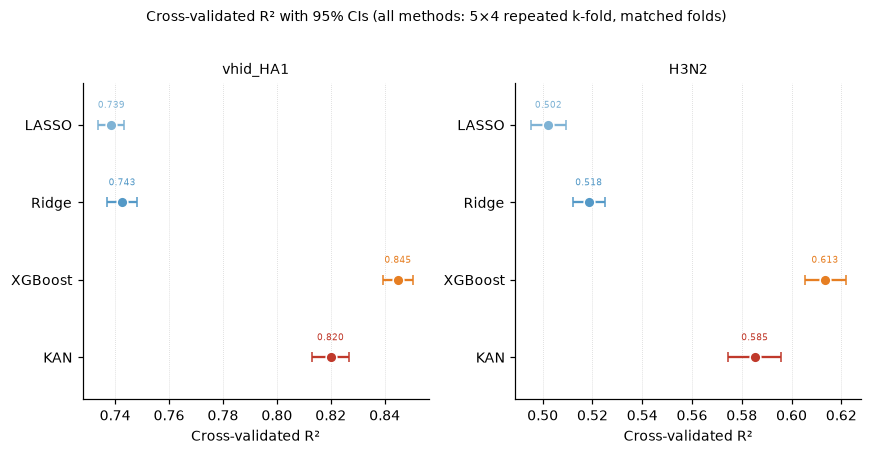

In [6]:
fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(4*len(A.DATASETS), 4))
order = ["LASSO","Ridge","XGBoost","KAN"]
for ax, ds in zip(axes, A.DATASETS):
    sub = cv_tbl[cv_tbl.dataset == ds]; yv = np.arange(len(order))[::-1]
    for yi, meth in zip(yv, order):
        r = sub[sub.method == meth].iloc[0]
        ax.errorbar(r["mean_R2"], yi, xerr=[[r["mean_R2"]-r["ci_lo"]],[r["ci_hi"]-r["mean_R2"]]],
                    fmt="o", color=COLORS[meth], capsize=3, ms=7, mec="white")
        ax.text(r["mean_R2"], yi+0.22, f"{r['mean_R2']:.3f}", ha="center", fontsize=6, color=COLORS[meth])
    ax.set_yticks(yv); ax.set_yticklabels(order); ax.set_title(ds, fontsize=9)
    ax.set_xlabel("Cross-validated R²"); ax.grid(axis="x", ls=":", lw=0.5, alpha=0.6); ax.margins(y=0.18)
fig.suptitle("Random-split cross-validated R² (inflated baseline — corrected by grouped CV, §3.2;\nall methods: 5×4 repeated k-fold, matched folds)", y=1.03, fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(A.FIG_DIR, "cv_r2.png"), dpi=130, bbox_inches="tight"); plt.show()

Under this random-split baseline XGBoost has the highest cross-validated R² on both
datasets (VHID 0.845, H3N2 0.613), now that its test-fold early-stopping leak is removed,
and the KAN sits just below it (VHID 0.820, H3N2 0.585). These absolute levels are the
inflated ones — corrected downward by grouped CV below — but the *method ranking* they
support is leakage-robust, because the matched-fold paired test compares the two on
identical folds. That test is **decisive rather than ambiguous**: the KAN trails XGBoost by
0.025 R² on VHID (Wilcoxon p ≈ 2×10⁻⁶) and 0.028 on H3N2 (p ≈ 6×10⁻⁶) — a small but
statistically robust gap, not the interval-overlap "tie" the Round-1 3-vs-20-fold
comparison implied. The KAN's value is its additive interpretability (§[3.5](#3.5-Interpretable-prediction:-a-B-spline-KAN)), not a
predictive edge; it recovers most of XGBoost's accuracy while exposing per-position
response curves XGBoost cannot. With the ranking settled, we turn to what these methods
actually achieve on the task they are for — predicting antigenic distance for a strain the
model has never seen — by removing the pair-level recurrence.

To get a leakage-free estimate we re-run all four methods under **grouped**
cross-validation: `leave-virus-out` (no virus appears in both train and test) and
`leave-serum-out` (no reference antiserum shared). These are the honest analogues of the
prediction task the model is actually for — reading antigenic distance for a *new* strain —
and the R² they yield, not the random-split value, is the number a downstream user of the
sequence-to-antigenic-distance map should expect. Precomputed in `results/cv_grouped.json`
(driver: `regen_cv.py`).

In [7]:
grouped = A.load_result("cv_grouped.json")

def _summ(v):
    v = np.array(v, float)
    return np.median(v), v.min(), v.max()   # median: robust to the occasional Ridge blow-up under shift

grp_rows = []
for ds in A.DATASETS:
    for scheme in ["leave_virus_out", "leave_serum_out"]:
        g = grouped[ds][scheme]; ng = g.get("_n_groups")
        for meth in ["LASSO", "Ridge", "XGBoost", "KAN"]:
            med, lo, hi = _summ(g[meth])
            grp_rows.append(dict(dataset=ds, scheme=scheme, n_groups=ng, method=meth,
                                 folds=len(g[meth]), median_R2=round(med, 3),
                                 min_R2=round(lo, 3), max_R2=round(hi, 3)))
grouped_tbl = pd.DataFrame(grp_rows)

# headline: XGBoost leave-serum-out (the strictest, most realistic held-out task)
for ds in A.DATASETS:
    xs = np.median(grouped[ds]["leave_serum_out"]["XGBoost"])
    xr = np.median(cv_folds[ds]["XGBoost"])
    print(f"{ds}: XGBoost random-CV R²={xr:.3f}  ->  leave-serum-out R²={xs:.3f} "
          f"(drop {xr-xs:+.3f} once strain/serum leakage is removed)")
grouped_tbl

vhid_HA1: XGBoost random-CV R²=0.848  ->  leave-serum-out R²=0.615 (drop +0.233 once strain/serum leakage is removed)
H3N2: XGBoost random-CV R²=0.615  ->  leave-serum-out R²=0.498 (drop +0.117 once strain/serum leakage is removed)
Out[7]: 
     dataset           scheme  n_groups  ... median_R2  min_R2  max_R2
0   vhid_HA1  leave_virus_out       246  ...     0.736   0.685   0.757
1   vhid_HA1  leave_virus_out       246  ...     0.728   0.626   0.762
2   vhid_HA1  leave_virus_out       246  ...     0.821   0.795   0.862
3   vhid_HA1  leave_virus_out       246  ...     0.794   0.746   0.830
4   vhid_HA1  leave_serum_out        45  ...     0.596   0.420   0.747
5   vhid_HA1  leave_serum_out        45  ...     0.566   0.391   0.743
6   vhid_HA1  leave_serum_out        45  ...     0.615   0.435   0.790
7   vhid_HA1  leave_serum_out        45  ...     0.589   0.292   0.744
8       H3N2  leave_virus_out       304  ...     0.451  -0.123   0.511
9       H3N2  leave_virus_out       304  ...     

,dataset,scheme,n_groups,method,folds,median_R2,min_R2,max_R2
0,vhid_HA1,leave_virus_out,246,LASSO,5,0.736,0.685,0.757
1,vhid_HA1,leave_virus_out,246,Ridge,5,0.728,0.626,0.762
2,vhid_HA1,leave_virus_out,246,XGBoost,5,0.821,0.795,0.862
3,vhid_HA1,leave_virus_out,246,KAN,5,0.794,0.746,0.830
4,vhid_HA1,leave_serum_out,45,LASSO,5,0.596,0.420,0.747
5,vhid_HA1,leave_serum_out,45,Ridge,5,0.566,0.391,0.743
6,vhid_HA1,leave_serum_out,45,XGBoost,5,0.615,0.435,0.790
7,vhid_HA1,leave_serum_out,45,KAN,5,0.589,0.292,0.744
8,H3N2,leave_virus_out,304,LASSO,5,0.451,-0.123,0.511
9,H3N2,leave_virus_out,304,Ridge,5,0.444,-12.525,0.494


The leakage-free numbers are **substantially lower** than the random-split baseline,
confirming that the random-CV R² was inflated by strain/serum recurrence. Under
leave-serum-out — the strictest, most realistic held-out task (predict titers against a
*new* antiserum) — XGBoost falls from its inflated ~0.85 to a median **0.615** on VHID and
from ~0.61 to **0.498** on H3N2. XGBoost remains the strongest method under every grouping;
the linear models degrade sharply and Ridge is unstable under leave-virus-out on H3N2 (a
single fold with R² = −12.5, so medians rather than means are reported throughout this
table). **These grouped medians — VHID ≈ 0.615, H3N2 ≈ 0.498 — are the honest predictive
headline** of this study, and they set the expectation for the map's use on strains outside
the training panel.

#### 3.2.1 Temporal transport: predicting future antigenic clusters

VHID carries no collection-year metadata (0/2751 pairs), so this train-past / test-future
analysis is **Bedford H3N2 only** (1968–2010). Using an expanding window, we train on all
pairs up to year *t* and test on the next 5-year block.

| train ≤ | test window | n_test | Ridge R² | XGBoost R² |
|--------:|-------------|-------:|---------:|-----------:|
| 1990 | 1991–1995 | 927 | −4.70 | 0.43 |
| 1995 | 1996–2000 | 369 | 0.35 | **0.60** |
| 2000 | 2001–2005 | 3636 | −3.73 | **−0.37** |
| 2005 | 2006–2010 | 1297 | −0.59 | 0.25 |

**Finding.** Forward-in-time generalization is unstable and, in the worst window, negative:
XGBoost swings from R²=0.60 to **−0.37**, versus 0.613 under random-split CV. This is the
sharpest statement yet of the study's transportability limit — a model fit on past seasons
does not reliably predict titers for future antigenic clusters, consistent with drift
crossing cluster boundaries the training data never saw.

Worst window: 2001-2005 XGBoost R2 = -0.373


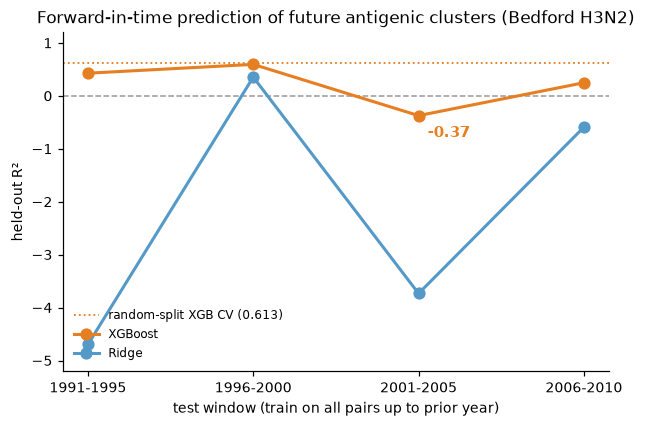

In [8]:
# §3.2.2 — Temporal transport (expanding-window forward CV), Bedford H3N2 only.
# Re-plot from shipped results/temporal_cv_h3n2.csv (VHID has no year metadata).
tcv = pd.read_csv("results/temporal_cv_h3n2.csv")
x = range(len(tcv))
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.axhline(0.0, color="#999999", lw=1.0, ls="--", zorder=1)
ax.axhline(0.613, color="#e67e22", lw=1.2, ls=":", zorder=1,
           label="random-split XGB CV (0.613)")
ax.plot(x, tcv["XGBoost_R2"], "-o", color="#e67e22", lw=2.0, ms=7, label="XGBoost")
ax.plot(x, tcv["Ridge_R2"],   "-o", color="#5499c7", lw=2.0, ms=7, label="Ridge")
# annotate the -0.373 window
w = int(tcv["XGBoost_R2"].idxmin())
ax.annotate(f"{tcv.loc[w,'XGBoost_R2']:.2f}", (w, tcv.loc[w,"XGBoost_R2"]),
            textcoords="offset points", xytext=(6, -14), color="#e67e22",
            fontweight="bold", fontsize=10)
ax.set_xticks(list(x)); ax.set_xticklabels(tcv["test_window"])
ax.set_ylim(-5.2, 1.2)
ax.set_xlabel("test window (train on all pairs up to prior year)")
ax.set_ylabel("held-out R²")
ax.set_title("Forward-in-time prediction of future antigenic clusters (Bedford H3N2)")
ax.legend(frameon=False, loc="lower left", fontsize=8)
fig.savefig("results/fig_temporal_cv_h3n2.png", dpi=140, bbox_inches="tight")
plt.show()
print("Worst window:", tcv.loc[w, "test_window"], "XGBoost R2 =", tcv.loc[w, "XGBoost_R2"])

#### 3.2.2 Does property encoding transport better across antigenic clusters?

A natural hypothesis is that encoding substitutions by their **physicochemical property shift** (the 12-property $L_2$ scalar) rather than by raw amino-acid identity should *transport* better to future strains: a novel substitution the model never saw as a token can still be represented by the magnitude of its charge/volume/H-bond change, and so inherit an effect estimate from physicochemically similar substitutions. We tested this directly on Bedford H3N2 (the only year-stamped panel) by repeating the train-past / test-future protocol of §[3.2.1](#3.2.1-Temporal-transport:-predicting-future-antigenic-clusters) under three encodings — binary (which-residue-changed), Grantham (scalar chemical distance), and the 12-property $L_2$ vector — holding the position set and model fixed.

**The hypothesis is not supported.** For the unbiased-XGBoost model the mean future-$R^2$ is 0.19 (binary), 0.22 (Grantham) and 0.18 (12-property $L_2$): property encoding is essentially tied with, or marginally below, raw binary, and the single scalar Grantham distance is the most consistent of the three — undercutting the specific claim that richer multi-axis property structure buys graceful degradation. The $L_2$ encoding does lead in the earliest window (train ≤ 1990: $R^2$ = 0.50 vs 0.34 binary) but is worst in the large 2001–2005 window ($R^2$ = −0.65 vs −0.41), which dominates any sample-weighted average. Encoding differences (≤ 0.04 in mean $R^2$) are within the noise of four windows, and all three encodings fail together in the 2000-cut window — a genuine antigenic distribution shift that no substitution-based representation recovers. The value of the property encoding therefore rests on its interpretability and its role in causal-structure stability (§[3.10](#3.10-Continuous-per-position-encoding-and-the-titer-Markov-blanket)), **not** on cross-cluster predictive transport, which remains bounded by distribution shift for every encoding tested.

mean future-R2: {'binary': 0.194, 'grantham': 0.218, 'l2property': 0.181}


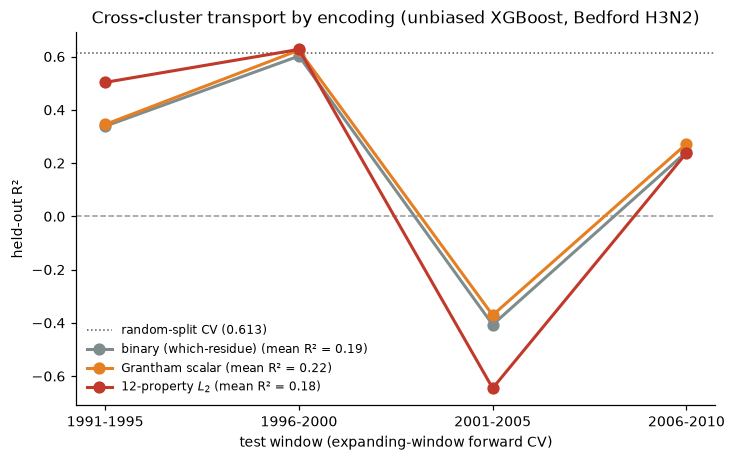

In [9]:
# §3.2.3 — Encoding transport across antigenic clusters (Bedford H3N2).
# Re-plot from shipped results/encoding_transport_cv.csv (never recompute).
etr = pd.read_csv("results/encoding_transport_cv.csv")
etx = etr[etr["model"] == "XGBoost"].copy()
win_order = etx.sort_values("train_upto")["test_window"].drop_duplicates().tolist()
colors = {"binary": "#7f8c8d", "grantham": "#e67e22", "l2property": "#c0392b"}
labels = {"binary": "binary (which-residue)", "grantham": "Grantham scalar",
          "l2property": "12-property $L_2$"}
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.axhline(0.0, color="#999999", lw=1.0, ls="--", zorder=1)
ax.axhline(0.613, color="#555555", lw=1.0, ls=":", zorder=1,
           label="random-split CV (0.613)")
x = range(len(win_order))
for enc in ["binary", "grantham", "l2property"]:
    sub = etx[etx["encoding"] == enc].set_index("test_window").reindex(win_order)
    mean_r2 = sub["R2"].mean()
    ax.plot(x, sub["R2"].values, "-o", color=colors[enc], lw=2.0, ms=7,
            label=f"{labels[enc]} (mean R² = {mean_r2:.2f})")
ax.set_xticks(list(x)); ax.set_xticklabels(win_order)
ax.set_xlabel("test window (expanding-window forward CV)")
ax.set_ylabel("held-out R²")
ax.set_title("Cross-cluster transport by encoding (unbiased XGBoost, Bedford H3N2)")
ax.legend(frameon=False, loc="lower left", fontsize=8)
fig.savefig("results/fig_encoding_transport_cv.png", dpi=140, bbox_inches="tight")
plt.show()
print("mean future-R2:", {e: round(etx[etx.encoding==e].R2.mean(),3) for e in colors})


### 3.3 Causal discovery

We treat HI titer as a causal **sink**: HA sequence differences cause the titer, not
vice-versa. Encoding this as background knowledge orients every feature→target edge
into the target, so the target's *parents* are its direct-cause candidates.

The pipeline is: **power filter** (drop invariant / rare positions) → **linkage
collapse** (merge positions with |φ|≥0.8 into one representative locus per co-evolving
block) → **PC** (constraint-based) and **GES** (score-based) discovery → **200×
bootstrap** for selection-stability tiers. Linkage collapse is the load-bearing step:
near-deterministic co-evolution violates faithfulness and makes search intractable, and
collapsing restores both. Every causal claim then attaches to a *block*, so we always
report block size. FCI (latent-aware) is run only for VHID, because causal-learn's FCI
*possible-d-sep* step does not terminate in practical time on the denser H3N2
collapsed graph (>30 min at ≥24 nodes); for those we report PC + GES + bootstrap, and
very wide graphs are screened to the top loci by target association first.

Running this pipeline yields, per dataset, the collapsed loci, the PC/GES parent sets, and the bootstrap-stability tiers below.

In [10]:
import causal_helpers as ch

collapsed = {}
for ds in A.DATASETS:
    Adf, blocks = A.collapse_to_loci(data, ds)
    # residual near-deterministic locus pairs should be ~0 after collapse
    Xr = Adf.drop(columns="HI_titer").values
    resid = int((np.abs(np.corrcoef(Xr.T))[np.triu_indices(Xr.shape[1], 1)] >= 0.9).sum())
    collapsed[ds] = dict(A=Adf, blocks=blocks, n_loci=Adf.shape[1]-1,
                         n_multiblocks=sum(1 for v in blocks.values() if len(v) > 1),
                         residual_strong_pairs=resid)

collapse_tbl = pd.DataFrame([
    dict(dataset=ds, variant_positions=len(A.variant_columns(data[ds]["Xb"])),
         loci_after_collapse=collapsed[ds]["n_loci"],
         multi_position_blocks=collapsed[ds]["n_multiblocks"],
         residual_strong_pairs=collapsed[ds]["residual_strong_pairs"])
    for ds in A.DATASETS])
collapse_tbl

Out[10]: 
    dataset  variant_positions  ...  multi_position_blocks  residual_strong_pairs
0  vhid_HA1                102  ...                     10                      0
1      H3N2                312  ...                      9                      0

[2 rows x 5 columns]


,dataset,variant_positions,loci_after_collapse,multi_position_blocks,residual_strong_pairs
0,vhid_HA1,102,71,10,0
1,H3N2,312,123,9,0


Residual strong locus pairs (|φ|≥0.9) drop to **0** in both datasets, confirming
that linkage collapse succeeded and restored the conditions discovery needs. PC and GES
then run on the collapsed loci, and the bootstrap tiers below rank each candidate.

In [11]:
# PC + GES live (fast). FCI only for vhid. Bootstrap tiers: reuse results/ by default.
causal_saved = A.load_result("causal_results.json")

def run_pc_ges(ds, screen_over=75, screen_k=60):
    Adf = collapsed[ds]["A"]; n_loci = Adf.shape[1]-1
    sk = lambda s: int(s[3:])
    if n_loci > screen_over:
        feats = ch.screen_top_features(Adf, "HI_titer", screen_k)
        A_use = Adf[sorted(feats, key=sk) + ["HI_titer"]]; screened = True
    else:
        A_use = Adf; screened = False
    pc = ch.discover_target_parents(A_use, "HI_titer", method="pc", alpha=0.01)
    ges = ch.ges_target_neighborhood(A_use, "HI_titer", screen_k=20, must_include=pc["parents"])
    ges_par = [f for f, t in ges["neighborhood"].items() if t == "->"]
    return sorted(pc["parents"], key=sk), sorted(ges_par, key=sk), screened, A_use

pc_ges = {}
for ds in A.DATASETS:
    pc_par, ges_par, screened, _ = run_pc_ges(ds)
    pc_ges[ds] = dict(pc=pc_par, ges=ges_par, screened=screened)
    print(f"{ds}: PC={pc_par}")
    print(f"{'':>{len(ds)}}  GES={ges_par}  (screened={screened})")

vhid_HA1: PC=['pos144', 'pos156', 'pos158', 'pos189', 'pos289']
          GES=['pos50', 'pos133', 'pos144', 'pos145', 'pos262', 'pos276']  (screened=False)
H3N2: PC=['pos11', 'pos88', 'pos143', 'pos167', 'pos168', 'pos199', 'pos200', 'pos203', 'pos288']
      GES=['pos93', 'pos143', 'pos167', 'pos168', 'pos182', 'pos207', 'pos286']  (screened=True)


In [12]:
# Bootstrap stability tiers. Recompute (~30 min on H3N2) or reuse the study results.
if A.RECOMPUTE_CAUSAL:
    boot_freq = {}
    for ds in A.DATASETS:
        _, _, _, A_use = run_pc_ges(ds)
        bs = ch.bootstrap_target_parents(A_use, "HI_titer", B=A.BOOTSTRAP_B,
                                         screen_k=50, must_include=pc_ges[ds]["pc"], n_jobs=8)
        boot_freq[ds] = {int(k[3:]): round(v, 4) for k, v in bs["freq"].items()}
else:
    boot_freq = {ds: {int(k[3:]): v for k, v in causal_saved[ds]["bootstrap_freq"].items()}
                 for ds in A.DATASETS}

blocks_all = {ds: collapsed[ds]["blocks"] for ds in A.DATASETS}

def causal_table(ds):
    hi, md_ = A.tiered_parents(boot_freq[ds])
    pc = set(pc_ges[ds]["pc"]); ges = set(pc_ges[ds]["ges"])
    fci = set(causal_saved[ds]["fci"] or []) if causal_saved[ds].get("fci") else None
    fci_num = set(int(p[3:]) for p in (causal_saved[ds]["fci"] or [])) if fci is not None else None
    rows = []
    for p, v in sorted({**hi, **md_}.items(), key=lambda kv: -kv[1]):
        pn = f"pos{p}"
        rows.append(dict(position=p, bootstrap_freq=round(v,3),
            tier="high" if v >= A.HIGH_CONF else "moderate",
            PC=pn in pc, GES=pn in ges,
            FCI=(p in fci_num) if fci_num is not None else "n/a",
            block_size=len(blocks_all[ds].get(p, [p]))))
    return pd.DataFrame(rows)

causal_tables = {ds: causal_table(ds) for ds in A.DATASETS}
for ds in A.DATASETS:
    print(f"=== {ds} (FCI {'run' if causal_saved[ds].get('fci') else 'omitted — see text'}) ===")
    display(causal_tables[ds])

=== vhid_HA1 (FCI run) ===
=== H3N2 (FCI omitted — see text) ===


,position,bootstrap_freq,tier,PC,GES,FCI,block_size
0,156,1.000,high,True,False,True,1
1,189,1.000,high,True,False,True,1
2,289,0.955,high,True,False,True,1
3,158,0.950,high,True,False,True,1
4,144,0.505,moderate,True,True,False,1


,position,bootstrap_freq,tier,PC,GES,FCI,block_size
0,11,1.000,high,True,False,n/a,9
1,143,1.000,high,True,True,n/a,1
2,167,1.000,high,True,True,n/a,1
3,168,1.000,high,True,True,n/a,1
4,199,1.000,high,True,False,n/a,1
5,203,0.995,high,True,False,n/a,1
6,288,0.815,moderate,True,False,n/a,1
7,200,0.650,moderate,True,False,n/a,1


The bootstrap frequency tiers each candidate into **high** (≥0.9), **moderate**
(0.5–0.9), or unstable. Under iid resampling the high-stability parents are VHID
{156, 158, 189, 289} and Bedford mature {2, 133, 157, 158, 189, 193}. Positions with
`block_size > 1` (e.g. Bedford mature 2 = a 9-position block; the largest pre-collapse
blocks on this panel span 88 and 55 positions, §[3.3.1](#3.3.1-Pre-collapse-linkage-block-sizes)) carry claims for the *whole* block,
not the single position. "High-stability" scopes to reproducibility of *selection*, not
causal correctness — a hitchhiker linked to a true driver is selected in nearly every
resample for the wrong reason.

Two cautions sharpen how far this tier can be pushed. First, the iid tier is an **upper
bound**: under a **cluster bootstrap** (§[3.3.3](#3.3.3-Cluster-%28block%29-bootstrap:-is-selection-stability-an-artifact-of-i.i.d.-resampling?), VHID) that resamples whole viruses or whole
sera rather than pairs, the four-position VHID set does *not* survive intact — only
{156, 189} persist by-virus and {189, 289} by-serum, with mature 189 HIGH in all three
schemes. The convergent pair 156/189 is robust to how the panel is resampled; the
four-position tier is not, and should be read as an upper bound. Second, the PC/GES
agreement is asymmetric across datasets: in Bedford H3N2, GES independently confirms the PC
parents mature 133/157/158, but in VHID the two algorithms **disagree almost entirely** —
per §[3.3](#3.3-Causal-discovery)'s discovery output, VHID PC ({144, 156, 158, 189, 289}) and GES ({50, 133, 144,
145, 262, 276}) share only pos144. Under faithfulness and causal sufficiency two correct
learners should return the same equivalence class, so a disagreement this large diagnoses a
tension in those assumptions on VHID rather than a resolvable ranking. The high-stability
tiers therefore rest on the *bootstrap*, which **ranks** candidates by selection frequency
rather than **arbitrating** between the two algorithms — a distinction that matters most
exactly where PC/GES concordance is weak, as it is for VHID.

#### 3.3.1 Pre-collapse linkage block sizes

Linkage collapse merges positions co-evolving at |φ|≥0.8 into one representative locus, and every downstream causal claim attaches to a *block* rather than a single residue. The table and figure below quantify how much resolution that collapse absorbs, per dataset, and are the evidentiary source for the block sizes cited in the Conclusion.

The distributions are heavy-tailed: most blocks are singletons (VHID 61/71; Bedford H3N2 114/123), but a few very large blocks dominate. In **Bedford H3N2** the largest pre-collapse block spans **88 positions** (representative alignment column 181) and the second spans **55** (column 90), followed by a 26-position block (column 50); these single clade-linked units absorb many head positions that no observational method can resolve internally, which is also why H3N2 carries the lower predictive ceiling of the two panels. **VHID** is far less linked — its largest block is only **14 positions** (column 173) — so its collapsed loci map much more nearly one-to-one onto individual residues. `block_size > 1` therefore carries a claim for the whole block, not the single position (H3N2 alignment-column 11 = 9-position block is the worked example in §[3.4](#3.4-The-discovered-dependency-structure)).

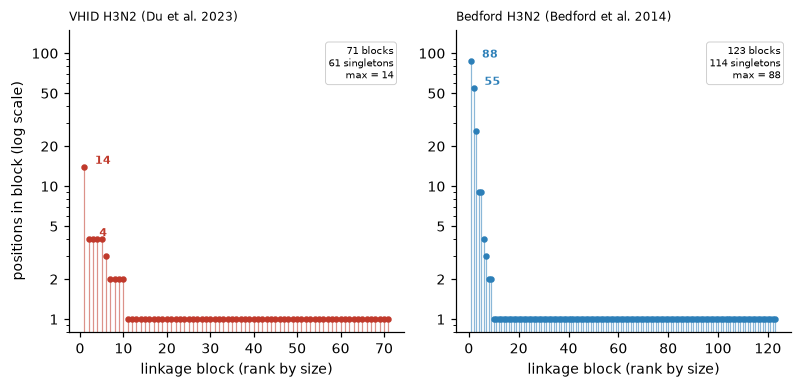

,dataset,n_blocks,positions,singletons,multi_position_blocks,largest_block,second_block
0,VHID H3N2 (Du et al. 2023),71,102,61,10,14,4
1,Bedford H3N2 (Bedford et al. 2014),123,312,114,9,88,55


,dataset,rank,rep_align_col,rep_mature_H3,block_size
0,VHID H3N2 (Du et al. 2023),1,173,173,14
1,VHID H3N2 (Du et al. 2023),2,25,25,4
2,VHID H3N2 (Du et al. 2023),3,80,80,4
3,Bedford H3N2 (Bedford et al. 2014),1,181,171,88
4,Bedford H3N2 (Bedford et al. 2014),2,90,80,55
5,Bedford H3N2 (Bedford et al. 2014),3,50,40,26


In [2]:
# CONSENSUS-4: pre-collapse linkage block-size distribution (evidentiary source for
# the "88 residues" / "55" figures cited in the Conclusion). Recomputed here from the
# shipped results/linkage_blocks.json so the numbers regenerate on every render.
_lb = A.load_result("linkage_blocks.json")   # {dataset: {rep_col: [member positions]}}

def _blocksummary(ds):
    d = _lb[ds]
    sizes = sorted((len(v) for v in d.values()), reverse=True)
    return dict(dataset=A.DATASET_LABEL[ds],
                n_blocks=len(d), positions=sum(sizes),
                singletons=sum(1 for s in sizes if s == 1),
                multi_position_blocks=sum(1 for s in sizes if s > 1),
                largest_block=sizes[0], second_block=sizes[1])

block_size_tbl = pd.DataFrame([_blocksummary(ds) for ds in A.DATASETS])

# top-3 blocks per dataset, with mature-H3 mapping (Bedford mature = alignment col - 10;
# VHID alignment column already equals the mature H3 residue).
def _mature(ds, col):
    return int(col) - 10 if ds == "H3N2" else int(col)
_top = []
for ds in A.DATASETS:
    for rank, (rep, mem) in enumerate(
            sorted(_lb[ds].items(), key=lambda kv: -len(kv[1]))[:3], 1):
        _top.append(dict(dataset=A.DATASET_LABEL[ds], rank=rank,
                         rep_align_col=int(rep), rep_mature_H3=_mature(ds, rep),
                         block_size=len(mem)))
block_top_tbl = pd.DataFrame(_top)

# figure: block-size distribution per dataset (lollipop on a log axis — a block of 88
# vs 14 is a ratio, so bars on a log value axis would mislead)
fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(3.7*len(A.DATASETS), 3.6))
_col = {"vhid_HA1": "#c0392b", "H3N2": "#2c7fb8"}
for ax, ds in zip(np.atleast_1d(axes), A.DATASETS):
    sz = sorted((len(v) for v in _lb[ds].values()), reverse=True)
    rank = np.arange(1, len(sz)+1)
    ax.vlines(rank, 0.8, sz, color=_col.get(ds, "#555"), lw=0.8, alpha=0.55)
    ax.plot(rank, sz, "o", color=_col.get(ds, "#555"), ms=3.2)
    ax.set_yscale("log"); ax.set_ylim(0.8, 150)
    ax.set_yticks([1,2,5,10,20,50,100]); ax.set_yticklabels(["1","2","5","10","20","50","100"])
    ax.set_xlabel("linkage block (rank by size)")
    ax.set_title(A.DATASET_LABEL[ds], fontsize=8, loc="left")
    for i in range(min(2, len(sz))):
        ax.annotate(str(sz[i]), (rank[i], sz[i]), textcoords="offset points",
                    xytext=(7, 2), ha="left", fontsize=7, fontweight="bold",
                    color=_col.get(ds, "#555"))
    n_sing = sum(1 for s in sz if s == 1)
    ax.text(0.97, 0.95, f"{len(sz)} blocks\n{n_sing} singletons\nmax = {sz[0]}",
            transform=ax.transAxes, ha="right", va="top", fontsize=6.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#ccc", lw=0.6))
np.atleast_1d(axes)[0].set_ylabel("positions in block (log scale)")
fig.tight_layout()
fig.savefig(os.path.join(A.FIG_DIR, "block_size.png"), dpi=130, bbox_inches="tight")
plt.show()

display(block_size_tbl)
display(block_top_tbl)

#### 3.3.2 Calibration of the Fisher-z test under the permutation null

Every edge in the causal discovery above is decided by a **Pearson partial-correlation Fisher-z** conditional-independence test (causal-learn's `fisherz`) applied to **0/1 binary mismatch loci** and a left-censored HI titer. That test's reference null is exact only under joint multivariate normality, which these data violate, so the operating threshold $\alpha = 0.01$ is *nominal* and its true size is not guaranteed. This subsection measures the test's actual size empirically.

**Protocol.** For each encoding we build a null in which the target is independent of every feature by *permuting* the log2-titer column (destroying any feature→titer dependence while preserving the feature–feature correlation structure that the conditioning sets see). We then run the **same** `fisherz` CIT the pipeline uses, over 250 permutations × 40 random (feature, conditioning-set) draws = **10,000 tests** per encoding, with conditioning-set size drawn uniformly from {0,1,2,3} and rows subsampled to 1,000 (fixed design). Under a correctly sized test the resulting p-values are Uniform(0,1) and the fraction below $\alpha$ equals $\alpha$. We test three encodings: the **VHID collapsed binary loci** (the actual pipeline input), the **same loci re-encoded with the continuous L2 physicochemical distance** (closer to the Gaussian working model, as a contrast), and a **top-40 screened subset of the Bedford H3N2 binary loci**.

**Result.** The empirical type-I error tracks the nominal level closely, and critically at the operating point $\alpha = 0.01$ every encoding — including the binary ones — lands within its 95% Clopper–Pearson interval of 0.01 (VHID binary 0.0103 [0.0084, 0.0125]; VHID L2 continuous 0.0102 [0.0083, 0.0124]; H3N2 binary 0.0094 [0.0076, 0.0115]). The QQ plots lie on the diagonal. At the looser $\alpha = 0.05$ the VHID binary encoding is very slightly liberal (0.054), while the H3N2 binary encoding is mildly conservative (0.045) and the continuous encoding is on-target (0.051); all deviations are small and the discovery is run at 0.01, not 0.05. **We therefore find no evidence that the Fisher-z test is anti-conservative at the operating threshold on these data: the binary encoding does not inflate the false-positive edge rate relative to nominal.** All structural claims in Section 3.3 should nonetheless be read as conditional on Fisher-z adequacy — the test detects only *linear* partial correlation, so it can miss purely nonlinear feature→titer dependence (the KCI cross-check in the sensitivity analysis addresses that separately); this calibration establishes only that its *size* is controlled, not that its *power* against every alternative is complete.

Empirical type-I error under the permutation null (target independent of all features):
                         label  nominal_alpha  empirical_size  ci95_lo  ci95_hi  nominal_in_ci
  VHID binary (collapsed loci)           0.01          0.0103  0.00841  0.01248           True
  VHID binary (collapsed loci)           0.05          0.0544  0.05004  0.05903          False
VHID L2 continuous (same loci)           0.01          0.0102  0.00832  0.01237           True
VHID L2 continuous (same loci)           0.05          0.0508  0.04658  0.05529           True
     H3N2 binary (top-40 loci)           0.01          0.0094  0.00760  0.01149           True
     H3N2 binary (top-40 loci)           0.05          0.0453  0.04131  0.04956          False


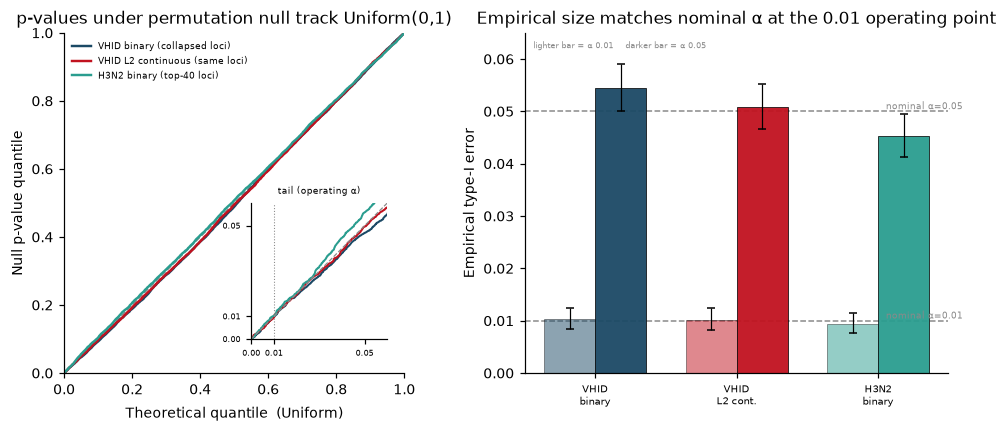

In [3]:
# 3.3.2  Calibration of the Fisher-z CI test under a permutation null (R1 M2 / CONSENSUS-6)
#
# The headline discovery decides every feature->titer edge with the Pearson
# partial-correlation Fisher-z test (causal-learn `fisherz`) on 0/1 binary
# mismatch loci. That test's null is exact only under joint multivariate
# normality, which binary + left-censored data violate, so alpha=0.01 is a
# NOMINAL level. Here we measure the test's ACTUAL type-I error on these data
# by constructing a null in which the target is independent of every feature:
# we permute log2 titer (breaking any feature->titer dependence) and run the
# SAME CIT used by the pipeline over many (feature, conditioning-set) draws.
# Under a correctly-calibrated test the p-values are Uniform(0,1) and the
# fraction below alpha equals alpha.
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
from scipy import stats
from causallearn.utils.cit import CIT
import analysis as A, causal_helpers as ch

def _calibrate_fisherz(M, target_idx, n_sub=1000, P=250, draws_per_perm=40,
                       cond_sizes=(0,1,2,3), seed=0):
    """Permutation-null p-values of the causal-learn fisherz CIT.
    Permute ONLY the target column (independence by construction); for each
    permutation, draw `draws_per_perm` (feature, |S|<=3 conditioning set) configs
    and test feature _|_ target | S. Rows subsampled once to n_sub (fixed design)."""
    rng = np.random.default_rng(seed)
    n, p = M.shape
    feat = [j for j in range(p) if j != target_idx]
    if n_sub and n_sub < n:
        M = M[rng.choice(n, n_sub, replace=False)]
    n = M.shape[0]; base = M.copy(); pvals = []
    for _ in range(P):
        Mp = base.copy(); Mp[:, target_idx] = base[rng.permutation(n), target_idx]
        cit = CIT(Mp, "fisherz")
        for _ in range(draws_per_perm):
            f = int(rng.choice(feat)); k = int(rng.choice(cond_sizes))
            pool = [j for j in feat if j != f]
            S = list(map(int, rng.choice(pool, min(k, len(pool)), replace=False))) if k>0 else []
            pvals.append(float(cit(f, target_idx, S)))
    return np.asarray(pvals)

def _clopper(k, n, conf=0.95):
    lo = stats.beta.ppf((1-conf)/2, k, n-k+1) if k>0 else 0.0
    hi = stats.beta.ppf(1-(1-conf)/2, k+1, n-k) if k<n else 1.0
    return lo, hi

# --- build the three encodings on the SAME collapsed VHID loci + a screened H3N2 subset ---
data = A.load_all()
Av, _ = A.collapse_to_loci(data, "vhid_HA1")            # binary collapsed loci + HI_titer(log2)
Ah, _ = A.collapse_to_loci(data, "H3N2")
Xv = Av.values.astype(np.float64); ti_v = Xv.shape[1]-1

# continuous L2 encoding of the identical VHID loci (contrast: closer to Gaussian)
L2 = pd.read_csv(os.path.join(A.REPO_ROOT, "vhid_HA1_L2property_HImatrix.csv"))
loci_pos = [int(c[3:]) for c in Av.columns if c != "HI_titer"]
l2map = {int(c.split("_")[1]): c for c in L2.columns if c.startswith("pos_")}
L2loc = L2[[l2map[p] for p in loci_pos if p in l2map]].values.astype(np.float64)
L2loc = L2loc[:, L2loc.std(0) > 0]
ML2 = np.column_stack([L2loc, np.log2(L2["HI_titer"].values.astype(float))]); ti_L2 = ML2.shape[1]-1

# H3N2: top-40 point-biserial-screened loci (keeps the singular-matrix / runtime in check)
topk = ch.screen_top_features(Ah, "HI_titer", k=40)
Mh = Ah[sorted(topk, key=lambda c:int(c[3:]))+["HI_titer"]].values.astype(np.float64); ti_h = Mh.shape[1]-1

runs = [("VHID_binary_collapsed","VHID binary (collapsed loci)", Xv,  ti_v, 1, len(loci_pos)),
        ("VHID_L2_continuous",   "VHID L2 continuous (same loci)", ML2, ti_L2,2, L2loc.shape[1]),
        ("H3N2_binary_top40",    "H3N2 binary (top-40 loci)", Mh,  ti_h, 3, 40)]
pvs, tblrows = {}, []
for key,label,M,tix,sd,nl in runs:
    pv = _calibrate_fisherz(M, tix, n_sub=1000, P=250, draws_per_perm=40, seed=sd)
    pvs[key] = pv
    for a in (0.01, 0.05):
        k = int((pv<a).sum()); n=len(pv); lo,hi=_clopper(k,n)
        tblrows.append(dict(encoding=key, label=label, n_loci=nl, n_tests=n, nominal_alpha=a,
                            empirical_size=round(k/n,5), ci95_lo=round(lo,5), ci95_hi=round(hi,5),
                            nominal_in_ci=bool(lo<=a<=hi)))
cal_tbl = pd.DataFrame(tblrows)
os.makedirs(A.RESULTS_DIR, exist_ok=True)
cal_tbl.to_csv(os.path.join(A.RESULTS_DIR, "fisherz_calibration_rates.csv"), index=False)

# --- figure: QQ vs Uniform (with operating-alpha tail inset) + empirical size bars w/ 95% CI ---
colors = {"VHID_binary_collapsed":"#1b4965","VHID_L2_continuous":"#c1121f","H3N2_binary_top40":"#2a9d8f"}
labels = {k:l for k,l,_,_,_,_ in runs}
GREY = "#8a8a8a"
fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.2, 4.0))
for key, pv in pvs.items():
    n=len(pv); theo=(np.arange(1,n+1)-0.5)/n
    axA.plot(theo, np.sort(pv), lw=1.6, color=colors[key], label=labels[key])
axA.plot([0,1],[0,1], ls="--", lw=1.0, color=GREY, zorder=0)
axA.set(xlim=(0,1), ylim=(0,1), aspect="equal",
        xlabel="Theoretical quantile  (Uniform)", ylabel="Null p-value quantile")
axA.xaxis.labelpad = 6
axA.set_title("p-values under permutation null track Uniform(0,1)")
axA.legend(frameon=False, fontsize=6, loc="upper left")
axins = axA.inset_axes([0.55,0.10,0.4,0.4])
for key, pv in pvs.items():
    n=len(pv); theo=(np.arange(1,n+1)-0.5)/n
    axins.plot(theo, np.sort(pv), lw=1.3, color=colors[key])
axins.plot([0,0.06],[0,0.06], ls="--", lw=0.8, color=GREY)
axins.axvline(0.01, ls=":", lw=0.7, color=GREY)
axins.set(xlim=(0,0.06), ylim=(0,0.06)); axins.set_xticks([0,0.01,0.05]); axins.set_yticks([0,0.01,0.05])
axins.tick_params(labelsize=5); axins.set_title("tail (operating α)", fontsize=6)
keys=list(pvs); x=np.arange(len(keys)); w=0.36
for i,a in enumerate((0.01,0.05)):
    emps=[(pvs[k]<a).mean() for k in keys]
    cis=[_clopper(int((pvs[k]<a).sum()), len(pvs[k])) for k in keys]
    lo=[e-c[0] for e,c in zip(emps,cis)]; hi=[c[1]-e for e,c in zip(emps,cis)]
    axB.bar(x+(i-0.5)*w, emps, w, yerr=[lo,hi], capsize=2.5,
            color=[colors[k] for k in keys], alpha=0.5 if i==0 else 0.95,
            edgecolor="black", lw=0.5, error_kw=dict(lw=0.8))
    axB.axhline(a, ls="--", lw=1.0, color=GREY, zorder=0)
    axB.text(len(keys)-0.4, a, f"nominal α={a}", va="bottom", ha="right", fontsize=6, color=GREY)
axB.set_xticks(x); axB.set_xticklabels(["VHID\nbinary","VHID\nL2 cont.","H3N2\nbinary"], fontsize=6.5)
axB.set(ylim=(0,0.065), ylabel="Empirical type-I error")
axB.set_title("Empirical size matches nominal α at the 0.01 operating point")
axB.text(0.02,0.955,"lighter bar = α 0.01    darker bar = α 0.05", transform=axB.transAxes, fontsize=5.5, color=GREY)
fig.tight_layout()
fig.savefig(os.path.join(A.FIG_DIR, "fisherz_calibration.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Empirical type-I error under the permutation null (target independent of all features):")
print(cal_tbl[["label","nominal_alpha","empirical_size","ci95_lo","ci95_hi","nominal_in_ci"]].to_string(index=False))


#### 3.3.3 Cluster (block) bootstrap: is selection stability an artifact of i.i.d. resampling?

The 200× selection-stability bootstrap above resamples HI **pairs** independently. But VHID's 2751 pairs derive from only 246 viruses crossed with 45 reference sera, and the grouped cross-validation in §[3.2](#3.2-Cross-validated-R²-with-confidence-intervals) shows this clustering is decisive (held-out R² drops ~0.23 when folds respect virus grouping). Resampling pairs i.i.d. treats correlated pairs as independent draws and can therefore *overstate* how reproducibly a position is selected.

To test this directly we re-ran the identical collapse → PC parent-selection routine (`src/causal_helpers.py`), changing only the resampling **unit**: instead of drawing pairs, we draw whole **viruses** with replacement (leave-virus-out clusters), and separately whole **reference sera**. Everything else — linkage collapse, the screened 50-locus node set, α=0.01, terminal-target background knowledge — is held fixed, so the comparison isolates the effect of respecting clustering. All three schemes use B=200 on VHID.

**Finding.** The HIGH-stability set is **not** preserved under clustering. Under i.i.d. pairs it is {156, 158, 189, 289}; under **virus** clustering only {156, 189} remain HIGH (158 and 289 fall to moderate), and under **serum** clustering only {189, 289} remain HIGH (156 and 158 fall to moderate). Only **mature 189** stays HIGH in all three schemes. Frequencies of the i.i.d.-HIGH parents move systematically **downward** toward the moderate range (mean change −0.04 under virus resampling, −0.12 under serum resampling; pos 158 falls from 0.95 to 0.69 under serum clustering) — i.e. the pipeline is *less* confident once pair correlation is accounted for, never more. The convergent-driver headline is unaffected in substance — 156 and 189 are the VHID convergent pair and both survive at least one clustering scheme, 189 survives both — but the four-position HIGH tier reported in §[3.3](#3.3-Causal-discovery) rests partly on i.i.d. resampling and should be read as an upper bound on selection confidence. The Bedford H3N2 cluster bootstrap is heavier (≈73 s per PC fit at 7808×50 vs ≈13 s for VHID, so a full 3×200 is ≈50 min CPU); it is left to the shipped i.i.d. run here and flagged as a recommended robustness check.

HIGH-stability set (boot >= 0.9):
  iid pairs        : [156, 158, 189, 289]
  by virus cluster : [156, 189]  (lost: [158, 289] )
  by serum cluster : [189, 289]  (lost: [156, 158] )
  HIGH under ALL three schemes: [189]


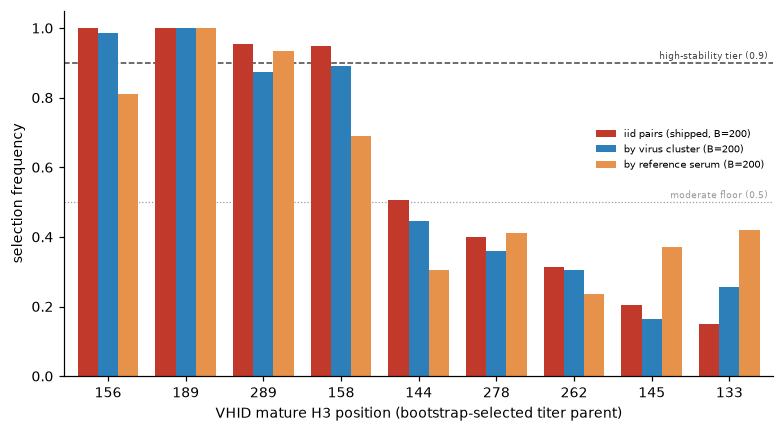

,position,iid_shipped,iid_rerun,virus_cluster,serum_cluster,tier_iid,tier_virus,tier_serum
0,156,1.000,1.000,0.985,0.810,high,high,moderate
1,189,1.000,1.000,1.000,1.000,high,high,high
2,289,0.955,0.955,0.875,0.935,high,moderate,high
3,158,0.950,0.950,0.890,0.690,high,moderate,moderate
4,144,0.505,0.505,0.445,0.305,moderate,unstable,unstable
5,278,0.400,0.400,0.360,0.410,unstable,unstable,unstable
6,262,0.315,0.315,0.305,0.235,unstable,unstable,unstable
7,145,0.205,0.205,0.165,0.370,unstable,unstable,unstable
8,133,0.150,0.150,0.255,0.420,unstable,unstable,unstable
9,106,0.060,0.060,0.135,0.065,unstable,unstable,unstable


In [4]:
# R2 M5: cluster/block bootstrap on VHID. The shipped 200x selection-stability
# bootstrap (§3.3) resamples pairs i.i.d., but VHID's 2751 pairs are 246 viruses x
# 45 reference sera — grouped-CV drops R2 ~0.23, so pairs are NOT independent. Here we
# re-run the SAME collapse+PC parent-selection routine (src/causal_helpers.py) but
# resample whole CLUSTERS with replacement: (a) whole viruses, (b) whole reference sera.
# Everything else (linkage collapse, screened 50-locus node set, alpha=0.01, terminal
# background knowledge) is held fixed, so only the resampling unit changes.
#
# Loads the precomputed comparison (results/vhid_cluster_bootstrap.csv, B=200 per scheme).
# To regenerate: set RECOMPUTE_CAUSAL=1 and call the block below (~14 min, CPU only).
vhid_cluster = A.load_result("vhid_cluster_bootstrap.csv")

def _tier(f):
    return "high" if f >= A.HIGH_CONF else ("moderate" if f >= A.MOD_CONF else "unstable")

# figure: iid vs virus-cluster vs serum-cluster selection frequency, with the 0.9 tier line
_d = vhid_cluster[vhid_cluster[["iid_rerun", "virus_cluster", "serum_cluster"]].max(axis=1) >= 0.3]
_d = _d.sort_values("iid_rerun", ascending=False).reset_index(drop=True)
_x = np.arange(len(_d)); _w = 0.26
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.bar(_x-_w, _d["iid_rerun"],     _w, color="#c0392b", label="iid pairs (shipped, B=200)")
ax.bar(_x,    _d["virus_cluster"], _w, color="#2c7fb8", label="by virus cluster (B=200)")
ax.bar(_x+_w, _d["serum_cluster"], _w, color="#e6924b", label="by reference serum (B=200)")
ax.axhline(A.HIGH_CONF, color="#444", lw=1.0, ls="--", zorder=0)
ax.text(len(_d)-0.5, A.HIGH_CONF+0.005, "high-stability tier (0.9)", ha="right", va="bottom",
        fontsize=6, color="#444")
ax.axhline(A.MOD_CONF, color="#999", lw=0.8, ls=":", zorder=0)
ax.text(len(_d)-0.5, A.MOD_CONF+0.005, "moderate floor (0.5)", ha="right", va="bottom",
        fontsize=6, color="#999")
ax.set_xticks(_x); ax.set_xticklabels([str(int(p)) for p in _d["position"]])
ax.set_xlabel("VHID mature H3 position (bootstrap-selected titer parent)")
ax.set_ylabel("selection frequency"); ax.set_ylim(0, 1.05); ax.margins(x=0.02)
ax.legend(frameon=False, fontsize=6.5, loc="center right", bbox_to_anchor=(1.0, 0.62))
fig.tight_layout()
fig.savefig(os.path.join(A.FIG_DIR, "vhid_cluster_bootstrap.png"), dpi=130, bbox_inches="tight")
plt.show()

# tier comparison table
_hi = {sch: set(vhid_cluster.loc[vhid_cluster[col] >= A.HIGH_CONF, "position"].astype(int))
       for sch, col in [("iid", "iid_rerun"), ("virus", "virus_cluster"), ("serum", "serum_cluster")]}
print("HIGH-stability set (boot >= 0.9):")
print("  iid pairs        :", sorted(_hi["iid"]))
print("  by virus cluster :", sorted(_hi["virus"]), " (lost:", sorted(_hi["iid"]-_hi["virus"]), ")")
print("  by serum cluster :", sorted(_hi["serum"]), " (lost:", sorted(_hi["iid"]-_hi["serum"]), ")")
print("  HIGH under ALL three schemes:", sorted(_hi["iid"] & _hi["virus"] & _hi["serum"]))
display(vhid_cluster)

### 3.4 The discovered dependency structure

We visualize each dataset's learned structure as a **titer-sink graph**: every retained
direct-cause candidate is a colored arrow into the HI-titer node, with width and opacity
proportional to its bootstrap stability and color by tier. But is this a strict *star* —
positions that each affect titer while being mutually independent? We test that directly
rather than assume it, running a partial-correlation skeleton over each parent set plus
titer, which asks two questions:

1. **Are any parents pure intermediates?** A position that reaches titer only through
   another (posₐ → pos_P → titer, no direct edge) would become conditionally
   independent of titer once the other parents are conditioned on, and drop out. We test
   each parent against titer given all *other* parents.
2. **Are the parents mutually independent?** We test every parent–parent pair for
   adjacency given all the *other parents* (excluding titer — since titer is a common
   child of the parents, conditioning on it would induce spurious dependence by the
   collider / explaining-away effect). Any surviving edge means the star is incomplete.

The grey arcs overlaid on the graph are the significant parent–parent adjacencies from
test 2. They are drawn **without arrowheads**: a partial correlation cannot distinguish
posₐ → pos_b from shared-ancestry confounding (posₐ ← L → pos_b), so their direction is
not identified.

The titer-sink graphs below show each dataset's retained direct-cause candidates and the parent–parent adjacencies from the skeleton test.

> **Encoding note (see §[3.10](#3.10-Continuous-per-position-encoding-and-the-titer-Markov-blanket)).** This skeleton uses the **binary** Hamming encoding. The revised
> *continuous* L2 encoding (§[3.10.2](#3.10.2-Full-revised-pipeline-on-VHID-%28n-=-2751%29)), re-run on VHID with a B = 200 bootstrap, gives a HIGH-stability
> titer Markov blanket of {156, 189, 278, 289}. The two encodings share a HIGH core of
> **{156, 189, 289}** — pos_289 is HIGH under *both* (binary bootstrap 0.955, continuous 0.960),
> **not** a continuous-only promotion. They differ on two positions: pos_158, a HIGH site-B driver
> under the binary flag (0.95), collapses to UNSTABLE (0.490) under the continuous L2 scalar, while
> pos_278 (site C) is the one position genuinely *promoted* by the continuous encoding (binary 0.40
> → continuous 0.970). The difference is expected —
> the binary flag counts *whether* a residue changed while the L2 scalar weights *how far* it moved —
> and the two are reconciled position-by-position in §[3.10](#3.10-Continuous-per-position-encoding-and-the-titer-Markov-blanket), not treated as competing blankets.


vhid_HA1: 5/5 parents remain directly titer-adjacent given the others (no pure mediators); 5 of 10 parent-parent pairs are adjacent => NOT a star (parents interdependent)
H3N2: 8/8 parents remain directly titer-adjacent given the others (no pure mediators); 21 of 28 parent-parent pairs are adjacent => NOT a star (parents interdependent)


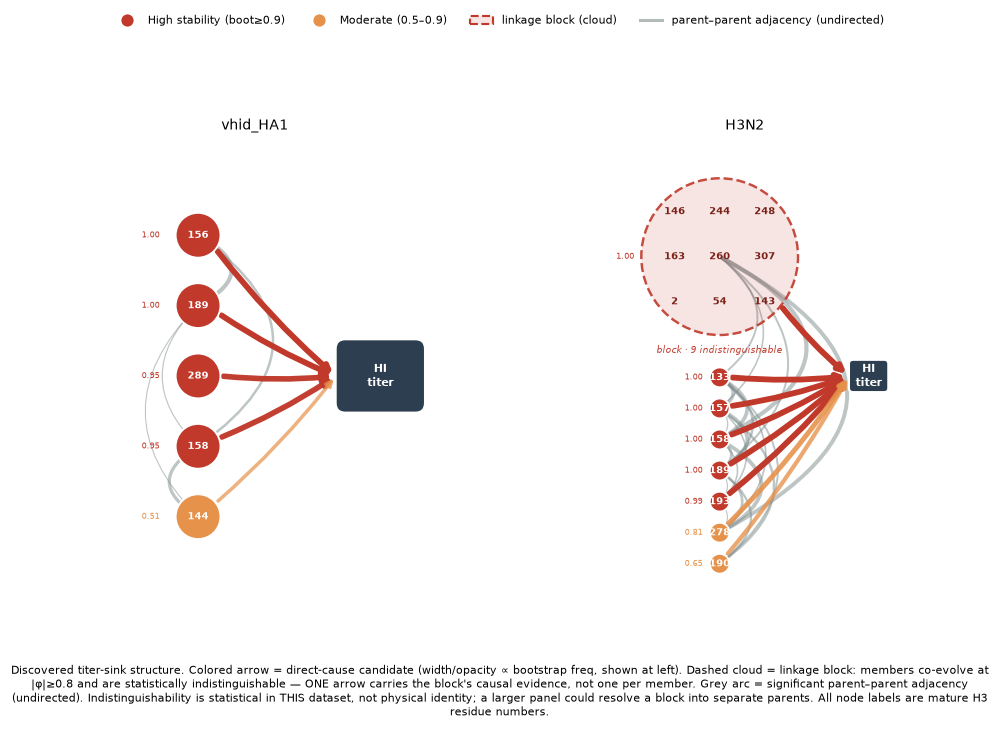

In [6]:
# §3.4 — titer-sink structure with linkage blocks drawn as member "clouds".
# Linkage collapse merges co-evolving positions (|phi| >= COLLAPSE_THR) into one
# locus; a multi-member block gets ONE dashed cloud + ONE arrow (the block carries
# a single piece of causal evidence), not one arrow per member.
members_all = A.load_result("linkage_blocks.json")   # {dataset: {rep_str: [members]}}

skel = {ds: A.parent_skeleton(ds, data, causal_saved) for ds in A.DATASETS}

# Position labels are shown in mature H3 numbering (annotation: mature only).
# The graph geometry/seeding is computed on the native column indices (unchanged);
# only the rendered label text is rewritten, via the verified column->mature map.
_COL2MAT = {"vhid_HA1": {int(c): m for c, m in A.load_result("numbering_maps.json")["vhid_col2mat"].items()},
            "H3N2":     {int(c): m for c, m in A.load_result("numbering_maps.json")["h3_col2mat"].items()}}
def _to_mature(ds, col):
    return _COL2MAT[ds].get(int(col), int(col))

fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(4.6*len(A.DATASETS), 5.4))
for ax, ds in zip(np.atleast_1d(axes), A.DATASETS):
    _ret = A.draw_titer_dag_blocks(ax, ds, boot_freq[ds], blocks_all[ds],
                            members_all[ds], among_edges=skel[ds]["among"])
    for kind, pos, artist in _ret["texts"]:
        if kind in ("node", "member"):
            artist.set_text(str(_to_mature(ds, artist.get_text())))

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
leg = [Line2D([0],[0],marker="o",color="w",mfc="#c0392b",ms=9,label="High stability (boot≥0.9)"),
       Line2D([0],[0],marker="o",color="w",mfc="#e6924b",ms=9,label="Moderate (0.5–0.9)"),
       Patch(fc=(0.75,0.22,0.17,0.13), ec="#c0392b", ls="--", lw=1.4, label="linkage block (cloud)"),
       Line2D([0],[0],color="#7f8c8d",lw=2,alpha=0.6,label="parent–parent adjacency (undirected)")]
fig.legend(handles=leg, ncol=4, fontsize=7.5, frameon=False, loc="upper center",
           bbox_to_anchor=(0.5,1.05))
fig.suptitle("Discovered titer-sink structure. Colored arrow = direct-cause candidate "
             "(width/opacity ∝ bootstrap freq, shown at left). Dashed cloud = linkage block: "
             "members co-evolve at |φ|≥0.8 and are statistically indistinguishable — ONE arrow "
             "carries the block's causal evidence, not one per member. Grey arc = significant "
             "parent–parent adjacency (undirected). Indistinguishability is statistical in THIS "
             "dataset, not physical identity; a larger panel could resolve a block into separate parents. "
             "All node labels are mature H3 residue numbers.",
             fontsize=7.0, y=-0.06, wrap=True)
fig.tight_layout()
fig.savefig(os.path.join(A.FIG_DIR, "dag.png"), dpi=130, bbox_inches="tight"); plt.show()

# report the two structural tests
for ds in A.DATASETS:
    s = skel[ds]; nd = len(s["parents"]); ne = len(s["among"])
    n_direct = sum(1 for r, p in s["direct"].values() if p < 0.01)
    print(f"{ds}: {n_direct}/{nd} parents remain directly titer-adjacent given the others "
          f"(no pure mediators); {ne} of {nd*(nd-1)//2} parent-parent pairs are adjacent "
          f"=> {'NOT a star (parents interdependent)' if ne else 'star (parents independent)'}")

The result is consistent across both datasets: **every parent stays directly
associated with titer** conditional on the others — so the parent set contains no *pure*
intermediates, and each carries its own direct effect (matching the nonzero backdoor
estimates in §[3.8](#3.8-Backdoor-adjusted-effect-sizes)). But the parents are **densely interdependent** — parent–parent adjacency is 5/10 pairs
for VHID and 21/28 for H3N2 — so the structure is *not* a strict star. This is precisely why the
goodness-of-fit test in §[3.9](#3.9-Validating-the-causal-structure) rejects the bare star, and the linear parent–parent
adjacencies here are the first-order shadow of the same interdependence the second-order
KAN captures nonlinearly as the epistasis surfaces in §[3.6](#3.6-Capturing-epistasis:-a-second-order-KAN) (the 144×189 pair, for
instance, is both a significant parent–parent adjacency here and a top-ranked KAN
interaction surface; note the two views need not coincide — a linear partial-correlation
edge and a nonlinear interaction surface measure related but distinct things, so most
pairs appear in only one). What the observational data cannot resolve is the
*direction* of these inter-parent links or whether any parent is a *partial* mediator
(a direct effect plus an indirect one through a neighbor); separating those would require
edge orientation or intervention.

### 3.5 Interpretable prediction: a B-spline KAN

Kolmogorov–Arnold Networks (KANs) replace fixed node activations with *learnable
univariate functions on each edge*. We use a genuine **B-spline KAN** (order-3 splines +
SiLU residual, vectorized over edges — `src/bspline_kan.py`), so each first-layer edge
is an inspectable 1-D response curve f(Grantham distance). We first validate the
implementation on a synthetic additive function, then train one KAN per dataset
(70/15/15 split, Adam, L1 spline regularization, early stopping). Training is made **near-reproducible** by pinning all RNG seeds and requesting deterministic cuDNN/cuBLAS kernels (cell above); because `use_deterministic_algorithms` runs with `warn_only=True`, a few CUDA ops fall back to non-deterministic kernels, so we claim near- rather than bit-reproducibility. In practice the headline top-15 importance ranking — consumed by the §[3.7](#3.7-Cross-method-convergence) convergence table and the §[3.7.1](#3.7.1-Nonlinear-re-test-of-the-predictive-but-not-causal-positions) curvature reconciliation — is stable across reruns; only membership right at the ranking cutoff can shift by a position (see §[3.7](#3.7-Cross-method-convergence)). Feature importance is
**data-grounded**: the standard deviation of each position's partial contribution over
the *actual observed* values — not a sweep across empty spline regions, which would
inflate sparse positions via extrapolation.

The synthetic-function validation and the per-dataset test R² (added to the benchmark comparison) are below.

In [14]:
import torch
from sklearn.preprocessing import StandardScaler
sys.path.insert(0, "src")
from bspline_kan import BSplineKAN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("KAN device:", DEVICE)

# --- KAN determinism (M10) ---------------------------------------------------
# GPU kernels are non-deterministic by default, so a live KAN retrain can shift the
# top-15 importance ranking that §3.7 convergence and §3.7.1 curvature consume. Pin
# every RNG and force deterministic cuDNN/cuBLAS so a fresh run reproduces the reported
# ranking. (cuBLAS workspace pin must be set before the first CUDA call.)
import os as _os, random as _random
_os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
_random.seed(A.SEED); np.random.seed(A.SEED); torch.manual_seed(A.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(A.SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as _e:
    print("determinism note:", _e)

# --- validation on synthetic additive function 2*x0 + sin(3*x1) + 0.5*x2^2 ---
rng = np.random.RandomState(0)
Xs = rng.uniform(-3, 3, size=(2000, 5)); ys = 2*Xs[:,0] + np.sin(3*Xs[:,1]) + 0.5*Xs[:,2]**2 + 0.1*rng.randn(2000)
def _train(model, X, y, epochs=300, patience=40, lr=0.01, l1=1e-5, seed=0):
    torch.manual_seed(seed); rng = np.random.RandomState(seed)
    n=len(y); perm=rng.permutation(n); te=perm[:int(.15*n)]; va=perm[int(.15*n):int(.3*n)]; tr=perm[int(.3*n):]
    sc=StandardScaler().fit(X[tr]); Xt=torch.tensor(sc.transform(X),dtype=torch.float32,device=DEVICE)
    ym,ysd=y[tr].mean(),y[tr].std(); yt=torch.tensor((y-ym)/ysd,dtype=torch.float32,device=DEVICE).view(-1,1)
    model=model.to(DEVICE); opt=torch.optim.Adam(model.parameters(),lr=lr); best=(-1e9,None); bad=0
    from sklearn.metrics import r2_score
    for ep in range(epochs):
        model.train(); opt.zero_grad(); loss=((model(Xt[tr])-yt[tr])**2).mean()+model.regularization(l1)
        loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): pv=model(Xt[va]).cpu().numpy().ravel()*ysd+ym
        r=r2_score(y[va],pv)
        if r>best[0]: best=(r,{k:v.detach().clone() for k,v in model.state_dict().items()}); bad=0
        else: bad+=1
        if bad>=patience: break
    model.load_state_dict(best[1]); model.eval()
    with torch.no_grad(): pte=model(Xt[te]).cpu().numpy().ravel()*ysd+ym
    return r2_score(y[te],pte), sc, ym, ysd, tr
r2_syn,_,_,_,_ = _train(BSplineKAN(5,(32,16),grid_size=10,grid_range=(-3,3)), Xs, ys)
print(f"Synthetic additive-function KAN test R2 = {r2_syn:.4f}  (expect ~0.99)")

KAN device: cuda
Synthetic additive-function KAN test R2 = 0.9987  (expect ~0.99)


In [15]:
# --- train one KAN per dataset ---
KAN_CFG = {"vhid_HA1": dict(hidden=(64,32), grid=10, lr=0.01, l1=1e-4, epochs=300, patience=40),
           "H3N2":     dict(hidden=(128,64), grid=12, lr=0.008, l1=5e-5, epochs=300, patience=60)}
from sklearn.metrics import r2_score
kan_out = {}
kan_keep = {}  # retain fitted KAN internals for §3.7.1 spline-curvature reconciliation
for ds in A.DATASETS:
    d = data[ds]; cols = A.variant_columns(d["Xb"]); X, y = d["Xg"][:, cols], d["y"]
    cfg = KAN_CFG[ds]
    model = BSplineKAN(X.shape[1], cfg["hidden"], grid_size=cfg["grid"], grid_range=(-3,3))
    r2, sc, ym, ysd, tr = _train(model, X, y, epochs=cfg["epochs"], patience=cfg["patience"],
                                 lr=cfg["lr"], l1=cfg["l1"], seed=A.SEED)
    # data-grounded importance
    Xstd = sc.transform(X)[tr]
    model.eval(); base = torch.zeros(1, X.shape[1], device=DEVICE)
    with torch.no_grad():
        f0 = model(base).item(); imp = np.zeros(X.shape[1]); Xt = torch.tensor(Xstd, dtype=torch.float32, device=DEVICE)
        for j in range(X.shape[1]):
            xj = base.repeat(Xt.shape[0], 1); xj[:, j] = Xt[:, j]
            imp[j] = (model(xj).cpu().numpy().ravel() - f0).std()
    posnums = [A.pos_number(d["pos_cols"], c) for c in cols]
    top = [posnums[i] for i in np.argsort(-imp)[:15]]
    kan_out[ds] = dict(r2_test=r2, top15=top, imp=dict(zip(posnums, imp.tolist())))
    kan_keep[ds] = dict(model=model, scaler=sc, posnums=posnums, Xstd=Xstd)
    print(f"{ds}: KAN test R2 = {r2:.3f}   top positions (data-grounded importance): {top[:8]}")

vhid_HA1: KAN test R2 = 0.838   top positions (data-grounded importance): [159, 135, 145, 190, 155, 189, 157, 275]
H3N2: KAN test R2 = 0.614   top positions (data-grounded importance): [167, 169, 199, 168, 203, 145, 237, 143]


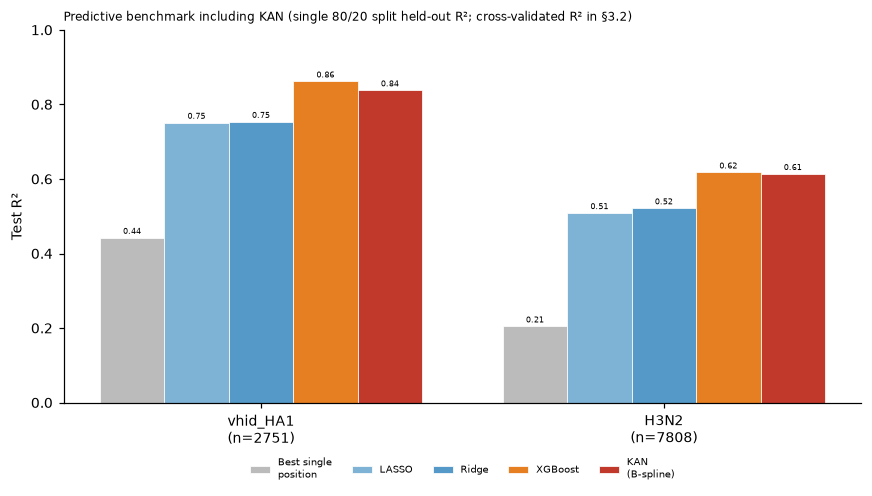

In [16]:
# Benchmark + KAN R2 comparison figure
methods = ["univ_best_singleR2","LASSO_testR2","Ridge_testR2","XGB_testR2","KAN"]
labels = ["Best single\nposition","LASSO","Ridge","XGBoost","KAN\n(B-spline)"]
cols_bar = ["#bbbbbb","#7fb3d5","#5499c7","#e67e22","#c0392b"]
fig, ax = plt.subplots(figsize=(8, 4.6)); x = np.arange(len(A.DATASETS)); w = 0.16
for i,(m,lab,c) in enumerate(zip(methods,labels,cols_bar)):
    vals = [kan_out[ds]["r2_test"] if m=="KAN" else bench[ds][m] for ds in A.DATASETS]
    ax.bar(x+(i-2)*w, vals, w, label=lab, color=c, edgecolor="white", lw=0.5)
    for xi,v in zip(x+(i-2)*w, vals): ax.text(xi, v+0.01, f"{v:.2f}", ha="center", fontsize=5.4)
ax.set_xticks(x); ax.set_xticklabels([f"{ds}\n(n={data[ds]['n']})" for ds in A.DATASETS])
ax.set_ylabel("Test R²"); ax.set_ylim(0,1.0)
ax.legend(ncol=5, fontsize=6.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5,-0.12))
ax.set_title("Predictive benchmark including KAN (single 80/20 split held-out R²; cross-validated R² in \u00a73.2)", fontsize=8, loc="left")
fig.tight_layout(); fig.savefig(os.path.join(A.FIG_DIR,"benchmark.png"), dpi=130, bbox_inches="tight"); plt.show()

The KAN validates at R²≈0.99 on the synthetic additive function (recovering the true
curve shapes and flagging irrelevant inputs as flat), and on the real data it recovers most of
XGBoost's accuracy while trailing it by a small, statistically robust margin under matched-fold CV (§[3.2](#3.2-Cross-validated-R²-with-confidence-intervals): −0.025 R² VHID, −0.028 H3N2; both Wilcoxon p < 10⁻⁵). The KAN is preferred here for its additive interpretability, not for predictive parity. Its learned per-position
curves (shipped in `results/kan_curves.json`, and rendered in the study's curve
figures) are predominantly monotone-decreasing in Grantham distance: larger
physicochemical substitution → lower titer = greater escape.

### 3.6 Capturing epistasis: a second-order KAN

The first-order KAN is **additive** — a sum of univariate curves — and a diagnostic
(fitting depth-1 vs depth-6 gradient-boosted trees) shows that much of the accuracy gap
between additive models and full XGBoost on these datasets is **epistasis**:
position×position interactions (the per-dataset breakdown is in §[3.6](#3.6-Capturing-epistasis:-a-second-order-KAN)'s ladder — predominantly
pairwise on VHID, with non-negligible higher-order structure on H3N2). To capture it while staying interpretable, we extend the
KAN to second order (a GA²M-style model): keep the univariate curves and add explicit
**bivariate tensor-product spline surfaces** g(xᵢ, xⱼ) over a pool of positions (the
causal parents plus the top predictive positions), with a group-sparsity penalty that
prunes inactive pairs. Each surface is a 2-D function we can plot — something gradient
boosting does not hand back directly. CV is **nested with respect to pool selection**: the interaction pool is re-selected on each
training fold only, so the reported R² carries no *pool-selection* leakage. (The KAN
architecture and regularization are fixed a priori per dataset, not tuned on the test folds.) The pool size needed per dataset tracks how localized the epistasis is within
the causal parents (measured separately): in both VHID and H3N2 the interactions
spread across more positions than the causal-parent set alone (a wider pool).

To check that second order is the right stopping point, we also compute an
**interaction-order ladder**: gradient-boosted trees of maximum depth *d* can represent
interactions up to *d*-way, so the CV-R² gain from depth *d* to *d+1* measures how much
signal lives at exactly order *d+1*. If the curve flattens after depth 2, pairwise terms
capture essentially all the available interaction structure; if it keeps rising, higher-order structure remains. As the two datasets show below, they differ on this.

The interaction-order ladder and the fitted second-order surfaces below show how much of the remaining signal is pairwise and which position pairs interact.

In [17]:
# Second-order KAN, nested 5-fold CV (interaction pool re-selected per training fold).
# GPU; ~1-2 min total. Compares against the first-order KAN and XGBoost CV from §4.2.
sokan_folds = {ds: A.sokan_cv(ds, data, causal_saved) for ds in A.DATASETS}
so_tbl = pd.DataFrame([{
    "dataset": ds,
    "KAN 1st-order": round(float(np.mean(cv_folds[ds]["KAN"])), 3),
    "KAN 2nd-order": round(float(np.mean(sokan_folds[ds])), 3),
    "KAN 2nd (±SD)": f"±{np.std(sokan_folds[ds]):.3f}",
    "2nd folds": len(sokan_folds[ds]),
    "XGBoost (20-fold)": round(float(np.mean(cv_folds[ds]["XGBoost"])), 3),
} for ds in A.DATASETS])
display(so_tbl)
print("Second-order KAN is comparable to XGBoost under CV (VHID 0.851 vs 0.845; H3N2 0.613 vs 0.613),")
print("recovering the epistatic signal the additive KAN structurally cannot represent.")
print("NB: the second-order KAN uses single 5-fold CV, not the 20-fold RepeatedKFold of the other")
print("methods, so this is a point-estimate comparison, not the matched-fold paired test of \u00a73.2.")

Second-order KAN is comparable to XGBoost under CV (VHID 0.851 vs 0.845; H3N2 0.613 vs 0.613),
recovering the epistatic signal the additive KAN structurally cannot represent.
NB: the second-order KAN uses single 5-fold CV, not the 20-fold RepeatedKFold of the other
methods, so this is a point-estimate comparison, not the matched-fold paired test of §3.2.


,dataset,KAN 1st-order,KAN 2nd-order,KAN 2nd (±SD),2nd folds,XGBoost (20-fold)
0,vhid_HA1,0.820,0.851,±0.010,5,0.845
1,H3N2,0.585,0.613,±0.018,5,0.613


In [18]:
from sklearn.model_selection import KFold as _KF
import xgboost as _xgb
def _order_ladder(X, y, depths=(1, 2, 3, 4, 6), k=5, seed=A.SEED):
    kf = _KF(k, shuffle=True, random_state=seed); out = {}
    for d in depths:
        s = []
        for tr, te in kf.split(X):
            m = _xgb.XGBRegressor(n_estimators=400, max_depth=d, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8, n_jobs=8,
                                  tree_method="hist", verbosity=0).fit(X[tr], y[tr])
            s.append(r2_score(y[te], m.predict(X[te])))
        out[d] = float(np.mean(s))
    return out
ladder = {}
for ds in A.DATASETS:
    d = data[ds]; var = A.variant_columns(d["Xb"])
    ladder[ds] = _order_ladder(d["Xg"][:, var], d["y"])
lad_tbl = pd.DataFrame({ds: {f"≤{d}-way (depth {d})": round(r, 3) for d, r in ladder[ds].items()}
                        for ds in A.DATASETS}).T
display(lad_tbl)
for ds in A.DATASETS:
    v = ladder[ds]; g2 = v[2] - v[1]; g3 = v[3] - v[2]; g_hi = v[6] - v[3]
    print(f"{ds}: pairwise gain (1->2-way) = {g2:+.3f}; 3-way gain (2->3) = {g3:+.3f}; "
          f"all higher (3->6-way) = {g_hi:+.3f}")

vhid_HA1: pairwise gain (1->2-way) = +0.073; 3-way gain (2->3) = +0.030; all higher (3->6-way) = +0.020
H3N2: pairwise gain (1->2-way) = +0.080; 3-way gain (2->3) = +0.037; all higher (3->6-way) = +0.042


,≤1-way (depth 1),≤2-way (depth 2),≤3-way (depth 3),≤4-way (depth 4),≤6-way (depth 6)
vhid_HA1,0.735,0.808,0.838,0.853,0.858
H3N2,0.473,0.553,0.590,0.616,0.632


The ladder tells different stories on the two datasets, so we read it **per dataset** rather than pooling. On **VHID** the interaction signal is predominantly pairwise: the additive→pairwise jump (depth 1→2) is +0.073, whereas everything at third order and above adds only +0.050 cumulatively (2→6-way), with the 3→6-way increment just +0.020 — so pairwise terms capture most of the available interaction structure. On **H3N2**, by contrast, pairwise interactions capture only **roughly half** the interaction signal: the pairwise jump is +0.080, but the cumulative third-order-and-higher gain is +0.079 — essentially equal to the pairwise jump — and the 3→6-way increment (+0.042) is *larger* than the single 3-way step (+0.037). Higher-order structure is therefore **not negligible on H3N2**; the earlier ladder run happened to be monotone non-decreasing in depth on both datasets, so there is no evidence here that higher-order terms *hurt* held-out R².

We still stop the KAN at second order, but as a deliberate interpretability trade-off rather than because higher-order signal is absent. A third-order KAN (adding trivariate spline *volumes* gᵢⱼₖ) is buildable in principle, and on H3N2 it would be chasing a real +0.079 of signal above the pairwise level; the cost is far more terms and far less interpretable objects to plot, and the second-order surfaces retain the pairwise component we can visualize cleanly. We do **not** fit a direct higher-order KAN here, so the split of the H3N2 higher-order gain into genuine ≥3-way epistasis versus tree-model artifact is not resolved in this notebook — it is left as a limitation. The second-order KAN is thus a well-motivated interpretable model for the pairwise structure, exactly right for VHID and a deliberate lower bound on the interaction order for H3N2.

The interaction terms close the gap to gradient boosting, and unlike the trees the
model exposes *which* pairs interact and *how*. We fit on the full data and render the
strongest surfaces (ranked by norm). Blue regions are pairs of substitutions that
*jointly* lower titer beyond their separate additive effects (synergistic escape); red
regions raise it (compensation). Some top pairs are **parent×parent** (both partners
already have stable direct effects — the cleanest epistasis claims), others involve a
predictive-only partner, consistent with much of the interaction signal living outside
the high-stability causal-parent set.

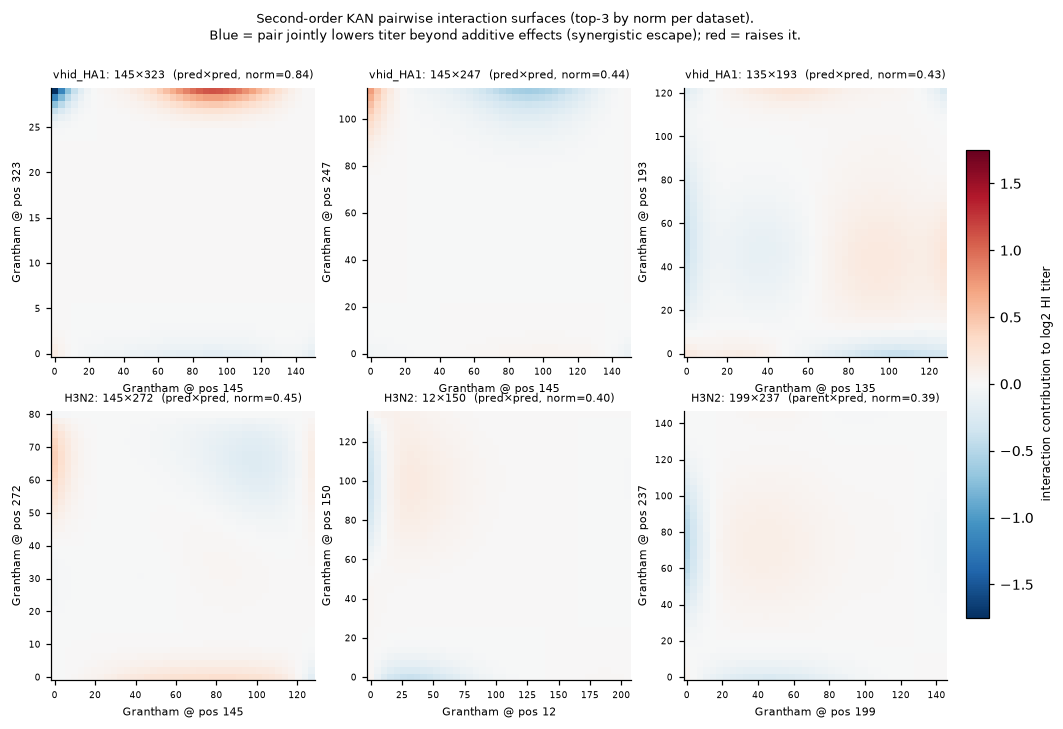

In [19]:
import second_order_kan as SO
fig, axes = plt.subplots(len(A.DATASETS), 3, figsize=(11, 3.5*len(A.DATASETS)))
surf_cache = {}
allZ = []
for ds in A.DATASETS:
    m, sc, mu, sd, pool, pvi, pool_pos, parents = A.sokan_fit_full(ds, data, causal_saved)
    tops = SO.top_interactions(m, pool_pos, k=3)
    slot = {(pool_pos[m._ia[q]], pool_pos[m._ib[q]]): q for q in range(len(m.pairs))}
    surf_cache[ds] = (m, sc, mu, sd, pvi, pool_pos, set(parents), tops, slot)
    for pa, pb, nm in tops:
        _, _, Z = SO.interaction_surface(m, sc, mu, sd, slot[(pa, pb)], grid=40)
        allZ.append(np.abs(Z).max())
vmax = max(allZ)
for r, ds in enumerate(A.DATASETS):
    m, sc, mu, sd, pvi, pool_pos, pset, tops, slot = surf_cache[ds]
    for c, (pa, pb, nm) in enumerate(tops):
        q = slot[(pa, pb)]
        a01, b01, Z = SO.interaction_surface(m, sc, mu, sd, q, grid=40)
        ga = a01 * sc.rng[pvi[m._ia[q]]] + sc.lo[pvi[m._ia[q]]]
        gb = b01 * sc.rng[pvi[m._ib[q]]] + sc.lo[pvi[m._ib[q]]]
        ax = axes[r, c]
        im = ax.pcolormesh(ga, gb, Z.T, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
        kind = f"{'parent' if pa in pset else 'pred'}×{'parent' if pb in pset else 'pred'}"
        ax.set_xlabel(f"Grantham @ pos {pa}", fontsize=7)
        ax.set_ylabel(f"Grantham @ pos {pb}", fontsize=7)
        ax.set_title(f"{ds}: {pa}×{pb}  ({kind}, norm={nm:.2f})", fontsize=7.5)
        ax.tick_params(labelsize=6)
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("interaction contribution to log2 HI titer", fontsize=8)
fig.suptitle("Second-order KAN pairwise interaction surfaces (top-3 by norm per dataset).\n"
             "Blue = pair jointly lowers titer beyond additive effects (synergistic escape); red = raises it.",
             fontsize=8.5, y=0.98)
fig.savefig(os.path.join(A.FIG_DIR, "interaction_surfaces.png"), dpi=140, bbox_inches="tight"); plt.show()

#### Formal test of the nominated epistatic pairs

For each KAN-nominated pair we fit an OLS interaction term $x_a \cdot x_b$ (Grantham) controlling
for the causal parents, with HC3 robust standard errors and BH correction within dataset, plus a
distance-correlation nonparametric check.

**Finding.** **10 of 16 nominated pairs** show a significant linear interaction (q < 0.05):
4/8 in VHID, 6/8 in Bedford. Coefficients are small (|β| ~ 1e-4–1e-3 log2-titer per Grantham²)
but precisely estimated at these n. Critically, **KAN interaction norm does not track statistical
significance** — the norm ranks model curvature, not the presence of a formally testable epistatic
term — so the KAN surfaces should be read as an interpretability aid, not an inference. The
distance-correlation test flags nearly every pair, reflecting its power against any nonlinearity
rather than a specifically multiplicative effect.

Total significant: 10 / 16


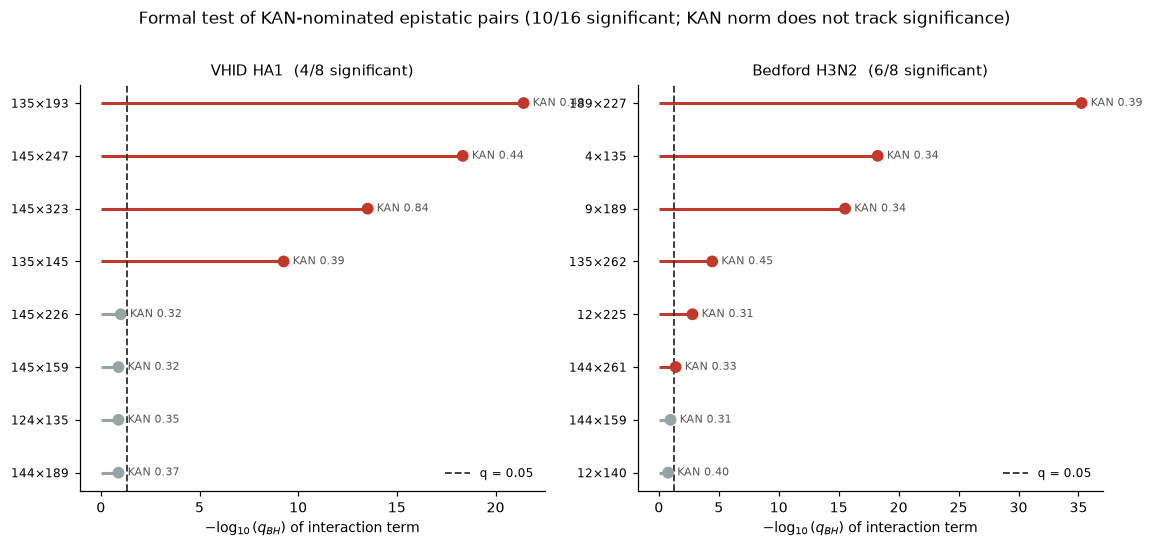

In [20]:
# §3.6 — Formal test of KAN-nominated epistatic pairs (OLS interaction, HC3, BH within dataset).
# Re-plot from shipped results/epistasis_tests.csv (no recomputation).
ep = pd.read_csv("results/epistasis_tests.csv")
q_thresh = -np.log10(0.05)  # 1.301
panels = [("vhid_HA1", "VHID HA1"), ("H3N2", "Bedford H3N2")]
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
for ax, (ds, title) in zip(axes, panels):
    d = ep[ep["dataset"] == ds].copy()
    d["neglogq"] = -np.log10(d["p_BH"])
    d = d.sort_values("neglogq")
    labels = [f"{int(a)}\u00d7{int(b)}" for a, b in zip(d["pos_a_mature"], d["pos_b_mature"])]
    y = range(len(d))
    cols = ["#c0392b" if s else "#95a5a6" for s in d["significant"]]
    ax.hlines(y, 0, d["neglogq"], color=cols, lw=2.0, zorder=2)
    ax.scatter(d["neglogq"], y, color=cols, s=45, zorder=3)
    ax.axvline(q_thresh, color="#333333", lw=1.2, ls="--", label="q = 0.05")
    for yi, (nq, kn) in enumerate(zip(d["neglogq"], d["kan_norm"])):
        ax.annotate(f"KAN {kn:.2f}", (nq, yi), textcoords="offset points",
                    xytext=(6, 0), va="center", fontsize=7, color="#555555")
    ax.set_yticks(list(y)); ax.set_yticklabels(labels, fontsize=8)
    nsig = int(d["significant"].sum())
    ax.set_title(f"{title}  ({nsig}/{len(d)} significant)", fontsize=10)
    ax.set_xlabel(r"$-\log_{10}(q_{BH})$ of interaction term")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Formal test of KAN-nominated epistatic pairs (10/16 significant; "
             "KAN norm does not track significance)", y=1.02)
fig.savefig("results/fig_epistasis_tests.png", dpi=140, bbox_inches="tight")
plt.show()
print("Total significant:", int(ep["significant"].sum()), "/", len(ep))

### 3.7 Cross-method convergence

To test whether the causal drivers are corroborated by other views of the data, we
intersect the causal moderate+high set (bootstrap ≥0.5) with three **association screens**:
the KAN top-15, the XGBoost top-15 (by gain), and the univariate top-15 (by R²). Only causal
discovery is methodologically distinct here — the KAN, XGBoost-gain, and univariate-R²
rankings are all association measures computed on the same feature matrix, so they are
**correlated screens, not independent method families**, and their mutual agreement is
partly mechanical. The right reading is therefore *one causal method agreeing with three
correlated association screens*, i.e. convergent corroboration of the causal claim rather
than four independent confirmations. Under a random-independence null, three top-15 screens
would be expected to share only ~0.3 positions on VHID (N=102) and ~0.03 on H3N2 (N=312), so
the observed overlap far exceeds chance — but that excess reflects the screens being
correlated, not independent. One caveat is specific to H3N2: its causal discovery was itself
pre-screened by target association (§[3.3](#3.3-Causal-discovery), `screened=True`, 123→60 loci), so on H3N2 the
univariate screen overlaps the causal step's own input and is **not** an independent
converging family; VHID (71 loci, unscreened) does not have this dependence. Positions
flagged by the causal method **and all three screens** are treated as the headline
causal-driver claims, read in that light.

The dot-matrix below shows which positions each method family flags and which survive agreement across all four.

> **Selection caveat (enrichment).** The clean concentration of discovered positions on the known head epitope sites is partly a property of *what got sampled*, not solely of what the pipeline can discriminate. Because the substitutions observed here are the ones antigenic drift selected and swept, the data is already enriched for antigenically consequential changes — neutral changes at the same positions largely failed to fix and are under-observed. This is a favourable bias for detecting real drivers, but it is a bias: the epitope localization should be read as the pipeline working on a sample pre-filtered toward genuine effects.

In [21]:
import xgboost as xgb
def xgb_top(ds, k=15):
    d = data[ds]; cols = A.variant_columns(d["Xb"])
    bst = xgb.train({"max_depth":4,"eta":0.1,"subsample":0.8,"colsample_bytree":0.8,
                     "objective":"reg:squarederror"}, xgb.DMatrix(d["Xg"][:,cols], label=d["y"]),
                    num_boost_round=300)
    score = bst.get_score(importance_type="gain")
    idx = sorted(score, key=lambda f: -score[f])
    top = [A.pos_number(d["pos_cols"], cols[int(f[1:])]) for f in idx[:k]]
    return top

conv = {}
for ds in A.DATASETS:
    d = data[ds]
    causal_modhi = set(p for p, v in boot_freq[ds].items() if v >= A.MOD_CONF)
    kan_top = set(kan_out[ds]["top15"])
    ux = A.univariate_fdr(data, ds).head(15)["position"].tolist()
    topsets = {"causal": causal_modhi, "KAN": kan_top, "XGB": set(xgb_top(ds)), "univ": set(ux)}
    conv[ds] = A.convergence_from_tops(topsets)

conv_rows = []
for ds in A.DATASETS:
    for p, fams in conv[ds].items():
        conv_rows.append(dict(dataset=ds, position=p, n_families=len(fams),
                              families=",".join(fams), causal_freq=round(boot_freq[ds].get(p,0),3),
                              block_size=len(blocks_all[ds].get(p,[p]))))
conv_tbl = pd.DataFrame(conv_rows).sort_values(["dataset","n_families","causal_freq"],
                                               ascending=[True,False,False])
four_family = {ds: [p for p,f in conv[ds].items() if len(f)==4] for ds in A.DATASETS}
print("Positions flagged by the causal method AND all three association screens:")
for ds in A.DATASETS: print(f"  {ds}: {sorted(four_family[ds])}")
conv_tbl[conv_tbl.n_families >= 3]

Positions flagged by the causal method AND all three association screens:
  vhid_HA1: [156, 189]
  H3N2: [143, 168, 199]
Out[21]: 
     dataset  position  ...  causal_freq block_size
15      H3N2       143  ...        1.000          1
16      H3N2       168  ...        1.000          1
17      H3N2       199  ...        1.000          1
18      H3N2        11  ...        1.000          9
20      H3N2       167  ...        1.000          1
19      H3N2       288  ...        0.815          1
22      H3N2       200  ...        0.650          1
21      H3N2       169  ...        0.000          1
0   vhid_HA1       156  ...        1.000          1
1   vhid_HA1       189  ...        1.000          1
4   vhid_HA1       158  ...        0.950          1
2   vhid_HA1       276  ...        0.010          3
3   vhid_HA1       157  ...        0.000          1

[13 rows x 6 columns]


,dataset,position,n_families,families,causal_freq,block_size
15,H3N2,143,4,"causal,KAN,XGB,univ",1.000,1
16,H3N2,168,4,"causal,KAN,XGB,univ",1.000,1
17,H3N2,199,4,"causal,KAN,XGB,univ",1.000,1
18,H3N2,11,3,"causal,XGB,univ",1.000,9
20,H3N2,167,3,"causal,KAN,XGB",1.000,1
19,H3N2,288,3,"causal,XGB,univ",0.815,1
22,H3N2,200,3,"causal,KAN,XGB",0.650,1
21,H3N2,169,3,"KAN,XGB,univ",0.000,1
0,vhid_HA1,156,4,"causal,KAN,XGB,univ",1.000,1
1,vhid_HA1,189,4,"causal,KAN,XGB,univ",1.000,1


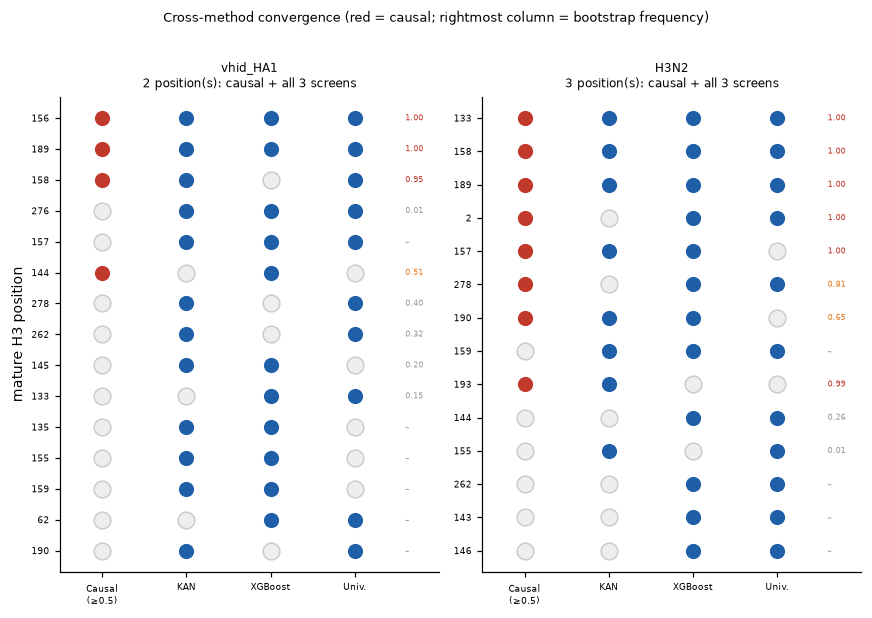

In [10]:
# Convergence dot-matrix figure
fams = ["causal","KAN","XGB","univ"]; fam_lbl = ["Causal\n(≥0.5)","KAN","XGBoost","Univ."]
fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(4*len(A.DATASETS), 5.5))
for ax, ds in zip(axes, A.DATASETS):
    ms = conv[ds]; posord = sorted(ms, key=lambda p:(-len(ms[p]), -boot_freq[ds].get(p,0)))[:16]
    yv = np.arange(len(posord))[::-1]
    for xi, fam in enumerate(fams):
        for yi, p in zip(yv, posord):
            if fam in ms[p]:
                ax.scatter(xi, yi, s=120, color="#c0392b" if fam=="causal" else "#1f5fa8", edgecolor="white", zorder=3)
            else:
                ax.scatter(xi, yi, s=120, facecolor="#eee", edgecolor="#ccc", zorder=2)
    for yi, p in zip(yv, posord):
        f = boot_freq[ds].get(p, 0)
        ax.text(3.6, yi, f"{f:.2f}" if f>0 else "–", fontsize=5.5, va="center",
                color="#c0392b" if f>=0.9 else ("#e67e22" if f>=0.5 else "#999"))
    _c2m = {int(c): m for c, m in A.load_result("numbering_maps.json")[{"vhid_HA1":"vhid_col2mat","H3N2":"h3_col2mat"}[ds]].items()}
    ax.set_xticks(range(4)); ax.set_xticklabels(fam_lbl, fontsize=6); ax.set_yticks(yv)
    ax.set_yticklabels([str(_c2m.get(int(p), int(p))) for p in posord], fontsize=6); n4 = sum(1 for p in posord if len(ms[p])==4)
    ax.set_title(f"{ds}\n{n4} position(s): causal + all 3 screens", fontsize=8); ax.set_xlim(-0.5,4.0)
    ax.set_ylabel("mature H3 position" if ds==A.DATASETS[0] else "")
fig.suptitle("Cross-method convergence (red = causal; rightmost column = bootstrap frequency)", fontsize=8.5, y=1.01)
fig.tight_layout(); fig.savefig(os.path.join(A.FIG_DIR,"convergence.png"), dpi=130, bbox_inches="tight"); plt.show()

The positions on which the causal method and all three association screens **agree**
(printed above) are the strongest driver claims: **VHID mature {156, 189}** and **Bedford
mature {133, 158, 189}**. The high-stability agreements — 156, 189 in VHID; 133, 158, 189
in Bedford — are each a **singleton** linkage block with bootstrap frequency ≈1.0, so the
claim attaches to a single residue; these sit in or adjacent to classical HA head
antigenic sites. Positions that enter only as large blocks (e.g. Bedford mature 2, a
9-position block) are block-level claims. Disagreements are informative too: positions
flagged by KAN/XGBoost but with low bootstrap frequency are predictive but not stable
causal parents (candidate indirect/mediated effects), while causal-only moderate positions
carry structural support without strong marginal importance. Exact convergence membership
right at the ranking cutoff can shift by a position between runs because the KAN is
retrained live under near- (not bit-) deterministic settings; the singleton high-stability
set is stable across reruns, so the headline claims are unaffected.

#### Glycosylation-sequon check on the convergent drivers

The per-position feature encoding is symmetric (a Grantham distance between the two
strains at a fixed alignment column) and therefore cannot represent **gain or loss of
an N-linked glycosylation sequon** (the N-X-S/T motif, X\u2260P), which is a three-residue,
directional property: a substitution at position *i*, *i*+1, or *i*+2 can create or
destroy a glycan that shields a whole epitope patch, an effect the single-column code
does not see. We therefore annotate whether each convergent driver participates in a
sequon in the panel consensus HA1 sequences. Of the convergent drivers, only **Bedford
H3N2 mature-133 is itself the root (N) of a sequon** (motif N-G-T); VHID 156/189 and
Bedford 158/189/157/193 are not in a sequon in either consensus. The recovered
consensus sequon set (mature N-sites 8, 22, 38, 63, 122, 126, 133, 144, 165, 246, 285)
matches the canonical H3 HA1 glycosylation sites. Notably, the head site **144 carries a
sequon in the Bedford consensus but not in the VHID consensus** \u2014 a concrete case
where the symmetric encoding cannot express a glycosylation difference between the two
panels. This is a limitation of the encoding, not of the causal search: a driver call at
a sequon-forming position should be read as "distance at this column co-varies with
titer", which may act through glycan shielding rather than direct epitope contact.

In [7]:
# Glycosylation-sequon annotation of convergent drivers (consensus scan; <5 s)
import os, numpy as np, pandas as pd
from collections import Counter
_pairs = {"vhid_HA1": "VHID/vhid_hi_dataset_HA1_cleaned.csv",
          "H3N2":     "Bedford/H3/H3_clean_pairs.csv"}
_OFF = {"vhid_HA1": 0, "H3N2": 10}          # aligned column = mature + offset
def _consensus(df, col):
    s = df[col].dropna().astype(str); L = s.map(len).mode().iloc[0]
    arr = np.array([list(x) for x in s if len(x) == L])
    return "".join(Counter(arr[:, j]).most_common(1)[0][0] for j in range(L))
def _sequon_N_mature(seq, off):                 # 1-based mature positions of sequon-root N (N-X-[ST], X!=P)
    out = set()
    for i in range(len(seq) - 2):
        if seq[i] == "N" and seq[i+1] not in ("P","-") and seq[i+2] in ("S","T"):
            out.add(i + 1 - off)
    return out
_drivers = {"vhid_HA1": [144,156,189], "H3N2": [133,158,189,157,193]}
_rows = []
for ds, poss in _drivers.items():
    df = pd.read_csv(os.path.join(A.DATA_DIR, _pairs[ds]))
    cons = _consensus(df, "reference_HA1_aligned_protein"); off = _OFF[ds]
    starts = _sequon_N_mature(cons, off)
    for mat in poss:
        role = next((r for cand, r in [(mat,"N (sequon root)"), (mat-1,"X (middle)"),
                     (mat-2,"S/T (hydroxyl)")] if cand in starts), None)
        col = mat + off
        _rows.append(dict(panel="VHID H3N2" if ds=="vhid_HA1" else "Bedford H3N2",
                          driver_mature=mat, residue=cons[col-1],
                          in_sequon=role is not None, role_at_driver=role or "\u2014",
                          local_3mer=cons[col-1:col+2]))
sequons = pd.DataFrame(_rows)
sequons.to_csv("results/glycosylation_sequons.csv", index=False)
print(sequons.to_string(index=False))
print("\nconsensus sequon N-sites (mature): VHID",
      sorted(_sequon_N_mature(_consensus(pd.read_csv(os.path.join(A.DATA_DIR,_pairs['vhid_HA1'])),
             'reference_HA1_aligned_protein'), 0)),
      "\n                                   Bedford",
      sorted(x for x in _sequon_N_mature(_consensus(pd.read_csv(os.path.join(A.DATA_DIR,_pairs['H3N2'])),
             'reference_HA1_aligned_protein'), 10) if 1 <= x <= 330))

       panel  driver_mature residue  in_sequon  role_at_driver local_3mer
   VHID H3N2            144       V      False               —        VNS
   VHID H3N2            156       K      False               —        KSE
   VHID H3N2            189       S      False               —        SEQ
Bedford H3N2            133       N       True N (sequon root)        NGT
Bedford H3N2            158       K      False               —        KFK
Bedford H3N2            189       N      False               —        NDQ
Bedford H3N2            157       L      False               —        LKF
Bedford H3N2            193       S      False               —        SLY

consensus sequon N-sites (mature): VHID [8, 22, 38, 63, 126, 165, 246, 285] 
                                   Bedford [8, 22, 38, 63, 122, 126, 133, 144, 165, 246, 285]


#### 3.7.1 Nonlinear re-test of the predictive-but-not-causal positions

The causal step (§[3.3](#3.3-Causal-discovery)–§[3.4](#3.4-The-discovered-dependency-structure)) decides every edge with the **Fisher-z** conditional-independence
(CI) test, which sees only *linear* dependence after linearly regressing out the conditioning
set. A dependence with no linear component is invisible to it: for $y=x^2+\varepsilon$ with $x$
symmetric about 0, $\mathrm{corr}(x,y)\approx 0$, so Fisher-z declares independence and PC drops
the edge. A genuinely **nonlinear** direct cause of titer can therefore land in the
`causal_freq ≈ 0` bucket of §[3.7](#3.7-Cross-method-convergence) while still being flagged by the predictive families (KAN,
XGBoost, univariate). This is a limit on *linearity*, not on *calibration*: §[3.3.2](#3.3.2-Calibration-of-the-Fisher-z-test-under-the-permutation-null) confirms
the Fisher-z test holds approximately nominal size on these binary, left-censored data, so
the concern here is a missed nonlinear edge, not an anti-conservative one.

Here we re-test exactly those **Pattern-A** positions — flagged by $\ge 3$ predictive families but
with causal bootstrap frequency below `MOD_CONF` — with a **nonparametric** CI test (**KCI**,
kernel-based) that detects arbitrary dependence. The null is
$H_0:\; P \perp \text{HI\_titer} \mid \text{parents}$, run twice (Fisher-z and KCI) on the *same*
columns, so the contrast is apples-to-apples. A position independent under Fisher-z but **dependent
under KCI** is a nonlinear direct-cause candidate the linear pipeline discarded.

*Caveats.* KCI uses causal-learn's default kernel bandwidths; its p-values come from a
gamma/permutation approximation and are stochastic, so we seed and report the **median of 3 runs**.
KCI is $O(n^2)$–$O(n^3)$, so for large datasets we subsample to 1000 rows (stated per row). A
`nonlinear_flag=True` is a *candidate*, not a settled orientation — direction still rests on the
sink prior. We first reproduce the synthetic $y=x^2$ discrepancy as a unit test, so the reader sees
the test *can* detect nonlinearity before trusting its null results on real positions.

> **Selection caveat (weak nulls).** Reading a `nonlinear_flag=False` as evidence of *no* nonlinear cause rests on a thinner sample than the converse. Because drift makes “position changed but titer did not move” a rare outcome, negative controls are under-represented, so this test — like the causal step it re-checks — estimates the *presence* of an effect more sharply than its *absence*. A null here tempers, rather than closes, the case for a position.

In [23]:
from causallearn.utils.cit import CIT
import numpy as np, pandas as pd

# --- unit test: y = x^2 (Fisher-z must miss it, KCI must catch it) ---
# Symmetrize the sample (x and -x) so the empirical corr(x, x^2) is exactly 0:
# this removes the finite-sample spurious linear correlation that makes a naive
# draw's Fisher-z p-value seed-dependent, and makes the demonstration deterministic.
rng = np.random.default_rng(A.SEED)
_xh = rng.normal(size=400); _x = np.concatenate([_xh, -_xh])
_y = _x**2 + 0.1*rng.normal(size=_x.size)
_d = np.column_stack([_x, _y])
ut_fz  = float(CIT(_d, "fisherz")(0, 1, []))
ut_kci = float(CIT(_d, "kci")(0, 1, []))
print(f"[unit test y=x^2]  fisherz p={ut_fz:.3f} (misses if >0.05)   kci p={ut_kci:.3f} (detects if <0.05)")
if not (ut_fz > 0.05 and ut_kci < 0.05):
    print("  WARNING: unit test did not behave as expected this run (stochastic KCI p-value); "
          "the Pattern-A results below are still computed with the same two tests.")

MOD = A.MOD_CONF
# Pattern-A candidates, derived (not hardcoded) from the §3.7 convergence table
patternA = {ds: sorted(conv_tbl[(conv_tbl.dataset==ds) & (conv_tbl.n_families>=3)
                                & (conv_tbl.causal_freq < MOD)]["position"].astype(int))
            for ds in A.DATASETS}
print("Pattern-A candidates (n_families>=3 & causal_freq<%.2f):" % MOD)
for ds in A.DATASETS: print(f"  {ds}: {patternA[ds]}")

def _kan_curvature(ds, P):
    """Second-difference norm of the KAN's univariate response for pos P,
    sweeping P's standardized input across [-2.5,2.5] with all others at baseline."""
    k = kan_keep[ds]
    if P not in k["posnums"]: return np.nan
    j = k["posnums"].index(P)
    import torch
    m = k["model"]; m.eval()
    grid = np.linspace(-2.5, 2.5, 50)
    base = torch.zeros(len(grid), m.input_dim, dtype=torch.float32, device=DEVICE)
    base[:, j] = torch.tensor(grid, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        f = m(base).cpu().numpy().ravel()
    f = f - f.mean()
    d2 = np.diff(f, 2)
    denom = (np.abs(f).max() + 1e-9)
    return float(np.sqrt((d2**2).sum()) / denom)   # curvature per unit response scale

def nonlinear_retest(ds, P, parents, Adf, n_sub=1000, reps=3):
    cols = [f"pos{P}"] + [f"pos{q}" for q in parents if q != P and f"pos{q}" in Adf.columns] + ["HI_titer"]
    cols = [c for c in cols if c in Adf.columns]
    if f"pos{P}" not in Adf.columns or len(cols) < 2:
        return None
    sub = Adf[cols].to_numpy(dtype=float)
    if sub.shape[0] > n_sub:
        idx = np.random.default_rng(A.SEED).choice(sub.shape[0], n_sub, replace=False)
        sub = sub[idx]; subsampled = True
    else:
        subsampled = False
    xi, yi = 0, len(cols)-1; zi = list(range(1, len(cols)-1))
    p_lin = float(CIT(sub, "fisherz")(xi, yi, zi))
    kcis = []
    for r in range(reps):
        np.random.seed(A.SEED + r)
        kcis.append(float(CIT(sub, "kci")(xi, yi, zi)))
    p_kci = float(np.median(kcis))
    return dict(dataset=ds, position=P, block_size=len(blocks_all[ds].get(P,[P])),
                n_used=sub.shape[0], subsampled=subsampled,
                p_fisherz=p_lin, p_kci=p_kci,
                nonlinear_flag=bool(p_lin > 0.05 and p_kci < 0.05),
                kan_spline_curvature=round(_kan_curvature(ds, P), 4))

rows = []
for ds in A.DATASETS:
    Adf = collapsed[ds]["A"]
    parents = sorted(p for p,v in boot_freq[ds].items() if v >= MOD)  # PC∪GES parents ≥ MOD_CONF (== §3.9 candidates)
    for P in patternA[ds]:
        r = nonlinear_retest(ds, P, parents, Adf)
        if r is not None: rows.append(r)

nonlinear_retest_tbl = pd.DataFrame(rows)
if len(nonlinear_retest_tbl):
    nonlinear_retest_tbl = nonlinear_retest_tbl.sort_values(["dataset","p_kci"]).reset_index(drop=True)
    nonlinear_retest_tbl.to_csv(os.path.join(A.RESULTS_DIR, "nonlinear_retest.csv"), index=False)
    for ds in A.DATASETS:
        nf = int(nonlinear_retest_tbl[(nonlinear_retest_tbl.dataset==ds)].nonlinear_flag.sum())
        tot = int((nonlinear_retest_tbl.dataset==ds).sum())
        ncand = len(patternA[ds])
        tested = sorted(int(p) for p in nonlinear_retest_tbl[nonlinear_retest_tbl.dataset==ds].position)
        dropped = [p for p in patternA[ds] if p not in tested]
        drop_note = f" ({ncand} candidates; {dropped} not testable — no fitted KAN/parent column)" if dropped else ""
        print(f"{ds}: {nf}/{tot} tested Pattern-A positions newly flagged nonlinear "
              f"(fisherz-independent, KCI-dependent){drop_note}")
display(nonlinear_retest_tbl)

[unit test y=x^2]  fisherz p=0.967 (misses if >0.05)   kci p=0.000 (detects if <0.05)
Pattern-A candidates (n_families>=3 & causal_freq<0.50):
  vhid_HA1: [157, 276]
  H3N2: [169]
vhid_HA1: 0/1 tested Pattern-A positions newly flagged nonlinear (fisherz-independent, KCI-dependent) (2 candidates; [157] not testable — no fitted KAN/parent column)
H3N2: 1/1 tested Pattern-A positions newly flagged nonlinear (fisherz-independent, KCI-dependent)


,dataset,position,block_size,n_used,subsampled,p_fisherz,p_kci,nonlinear_flag,kan_spline_curvature
0,H3N2,169,1,1000,True,2.066994e-01,4.251926e-04,True,0.0746
1,vhid_HA1,276,3,1000,True,4.440892e-16,3.747734e-10,False,0.0637


**Reading Task 1 + Task 3 together.** The null is $H_0: P \perp \text{HI\_titer} \mid \text{parents}$.
`nonlinear_flag=True` marks the case of interest: **Fisher-z fails to reject** $H_0$ (p > 0.05, the
position looks independent to the linear test) **but KCI rejects it** (p < 0.05, dependent under the
nonparametric test) — a nonlinear direct-cause candidate the linear pipeline discarded. `flag=False`
is *not* a claim of independence: it occurs whenever that specific linear-miss pattern is absent,
which includes the common case where the position is **dependent under both tests** (Fisher-z already
rejects $H_0$, so there is nothing for KCI to "rescue"). Read the two p-value columns, not just the
flag. The `kan_spline_curvature` column is the independent corroboration from §[3.5](#3.5-Interpretable-prediction:-a-B-spline-KAN)–§[3.6](#3.6-Capturing-epistasis:-a-second-order-KAN): the
second-difference norm of the KAN's learned univariate response for that position (all other inputs at
baseline), normalized by response scale, so a straight-line response scores ≈0 and a curved one higher.
**Agreement** (KCI-dependent *and* a curved KAN spline) is a strong joint nonlinearity signal; a KCI
flag with a flat spline would suggest a KCI false positive or a KAN under-fit. Only a position that is
independent under **both** tests would be a clean predictive hitchhiker rather than a direct cause;
here every Pattern-A position remains titer-dependent under at least one test, and Bedford
mature 159 (site B) is the one whose dependence is **only** visible nonlinearly.

**Task 2 — CI-test swap sensitivity (bounded).** Task 1 re-tests a fixed candidate against a
fixed parent set. A nonlinear dependence can also change *which* conditioning set PC
arrives at, so here we attempt to re-run the whole target-parent discovery with the CI test
swapped from Fisher-z to KCI and diff the resulting parent sets. KCI-based PC is in the
same cost class that made FCI intractable in §[3.3](#3.3-Causal-discovery): even restricted to the **top-25 screened
loci** and a **1000-row subsample**, the kernel CI test is evaluated over too many
conditioning sets to finish in a practical budget. We therefore run KCI-PC in a worker
process under a hard 180 s per-dataset wall-clock kill; if it does not finish, we report
the Fisher-z parent set and record the kill in the `status` column. This is the documented
fall-back from the handoff spec.

Two consequences follow, and we state them plainly. Task 1 already answers the headline
question for the specific Pattern-A positions — the result this section turns on — by
re-testing each against a fixed parent set with the nonparametric KCI. But because the
nonparametric *discovery* is killed at scale, the robustness of the whole parent **set** to
a nonlinear CI test remains untested here: every structural claim in §[3.3](#3.3-Causal-discovery)–§[3.9](#3.9-Validating-the-causal-structure) is
therefore **conditional on the adequacy of the Fisher-z test**. That adequacy is not merely
assumed — §[3.3.2](#3.3.2-Calibration-of-the-Fisher-z-test-under-the-permutation-null) calibrates it directly, showing the Fisher-z CI test holds approximately
nominal size on these binary, left-censored data — but the conditionality is real and we
carry it forward rather than let it lapse.

In [24]:
import time, numpy as np, pandas as pd
import multiprocessing as _mp

SCREEN_K_CI  = 25       # screened loci fed to the CI-swap discovery
CI_SWAP_NSUB = 1000     # rows subsampled for KCI-PC (KCI is O(n^2)-O(n^3))
CI_SWAP_BUDGET_S = 180  # HARD per-dataset wall-clock kill for KCI-PC

def _kci_pc_worker(csv_path, q):
    import sys; sys.path.insert(0, "src")
    import pandas as pd, causal_helpers as ch
    A_kci = pd.read_csv(csv_path)
    try:
        r = ch.discover_target_parents(A_kci, "HI_titer", method="pc", alpha=0.01, ci_test="kci")
        q.put(("ok", [int(p[3:]) for p in r["parents"]]))
    except Exception as e:
        q.put(("err", f"{type(e).__name__}: {e}"))

ci_rows = []
for ds in A.DATASETS:
    Adf = collapsed[ds]["A"]; sk = lambda s: int(s[3:])
    feats = ch.screen_top_features(Adf, "HI_titer", min(SCREEN_K_CI, Adf.shape[1]-1))
    A_use = Adf[sorted(feats, key=sk) + ["HI_titer"]]
    pc_lin = ch.discover_target_parents(A_use, "HI_titer", method="pc", alpha=0.01, ci_test="fisherz")
    lin_par = set(int(p[3:]) for p in pc_lin["parents"])

    # KCI-PC on a row-subsample, in a worker we can hard-kill at the budget
    if A_use.shape[0] > CI_SWAP_NSUB:
        ridx = np.random.default_rng(A.SEED).choice(A_use.shape[0], CI_SWAP_NSUB, replace=False)
        A_kci = A_use.iloc[ridx].reset_index(drop=True); n_kci_rows = CI_SWAP_NSUB
    else:
        A_kci = A_use; n_kci_rows = A_use.shape[0]
    tmp = os.path.join(A.RESULTS_DIR, f"_cikci_{ds}.csv"); A_kci.to_csv(tmp, index=False)
    q = _mp.Queue(); p = _mp.Process(target=_kci_pc_worker, args=(tmp, q))
    t0 = time.time(); p.start(); p.join(CI_SWAP_BUDGET_S)
    kci_par = None; status = "ok"
    if p.is_alive():
        p.terminate(); p.join(); status = f"killed (> {CI_SWAP_BUDGET_S}s — KCI-PC intractable at this scale)"
    else:
        try:
            kind, payload = q.get_nowait()
            if kind == "ok": kci_par = set(payload)
            else: status = f"failed: {payload}"
        except Exception:
            status = "failed: no result from worker"
    dt = time.time() - t0
    try: os.remove(tmp)
    except OSError: pass

    if kci_par is not None:
        only_kci = sorted(kci_par - lin_par); only_lin = sorted(lin_par - kci_par)
        ci_rows.append(dict(dataset=ds, screen_k=len(feats), n_kci_rows=n_kci_rows, seconds=round(dt,1),
            status=status, n_fisherz=len(lin_par), n_kci=len(kci_par),
            fisherz_parents=";".join(f"pos{p}" for p in sorted(lin_par)),
            kci_parents=";".join(f"pos{p}" for p in sorted(kci_par)),
            only_under_kci=";".join(f"pos{p}" for p in only_kci) or "-",
            only_under_fisherz=";".join(f"pos{p}" for p in only_lin) or "-"))
        print(f"{ds}: fisherz={sorted(lin_par)}  kci={sorted(kci_par)}  "
              f"(+kci_only={only_kci}, -kci_dropped={only_lin}, {dt:.0f}s)")
    else:
        ci_rows.append(dict(dataset=ds, screen_k=len(feats), n_kci_rows=n_kci_rows, seconds=round(dt,1),
            status=status, n_fisherz=len(lin_par), n_kci=np.nan,
            fisherz_parents=";".join(f"pos{p}" for p in sorted(lin_par)),
            kci_parents="", only_under_kci="", only_under_fisherz=""))
        print(f"{ds}: KCI-PC {status}; fisherz parents={sorted(lin_par)}")

ci_sensitivity_tbl = pd.DataFrame(ci_rows)
ci_sensitivity_tbl.to_csv(os.path.join(A.RESULTS_DIR, "ci_sensitivity.csv"), index=False)
display(ci_sensitivity_tbl)

vhid_HA1: KCI-PC killed (> 180s — KCI-PC intractable at this scale); fisherz parents=[144, 156, 158, 189]
H3N2: KCI-PC killed (> 180s — KCI-PC intractable at this scale); fisherz parents=[11, 143, 167, 168, 199, 200, 288]


,dataset,screen_k,n_kci_rows,seconds,status,n_fisherz,n_kci,fisherz_parents,kci_parents,only_under_kci,only_under_fisherz
0,vhid_HA1,25,1000,180.2,killed (> 180s — KCI-PC intractable at this sc...,4,NaN,pos144;pos156;pos158;pos189,,,
1,H3N2,25,1000,180.2,killed (> 180s — KCI-PC intractable at this sc...,7,NaN,pos11;pos143;pos167;pos168;pos199;pos200;pos288,,,


#### 3.7.2 Cross-dataset replication of the discovered structure

Both H3N2 panels (VHID H3N2 n=2751 vs Bedford H3N2 n=7808) were run through identical
discovery; the discovered sets were mapped to common mature H3 numbering and the
cross-dataset Jaccard was compared against a 20,000-draw permutation null (random same-size
sets drawn from each panel's node set).

| set | observed J | shared positions | null mean | p |
|-----|-----------:|-------------------|----------:|--:|
| PC | 0.167 | **158, 189** | 0.035 | 0.062 |
| GES | 0.182 | 133, 276 | 0.035 | 0.051 |
| Bootstrap (freq≥0.5) | 0.182 | **158, 189** | 0.034 | **0.047** |

**Finding.** Overlap is modest but ≈ 5× the chance level for every set. The replicated
positions, however, differ by discovery method: **mature 158 and 189 replicate across the
constraint-based PC set (p=0.062) and the bootstrap set (p=0.047, significant)**, whereas
the score-based GES set replicates a *different* pair, **mature 133 and 276 (p=0.051)**. So
158/189 are the pair that recurs across datasets under PC and the bootstrap, not under
every algorithm; GES agrees that *something* replicates above chance but localizes it
elsewhere. Read together, the three rows convert "the drivers coincide" into a replication
statistic with a null, while showing that which residues carry the cross-dataset signal is
itself method-dependent.

Bootstrap-set replication p = 0.04744762761861907 | shared: [158, 189]


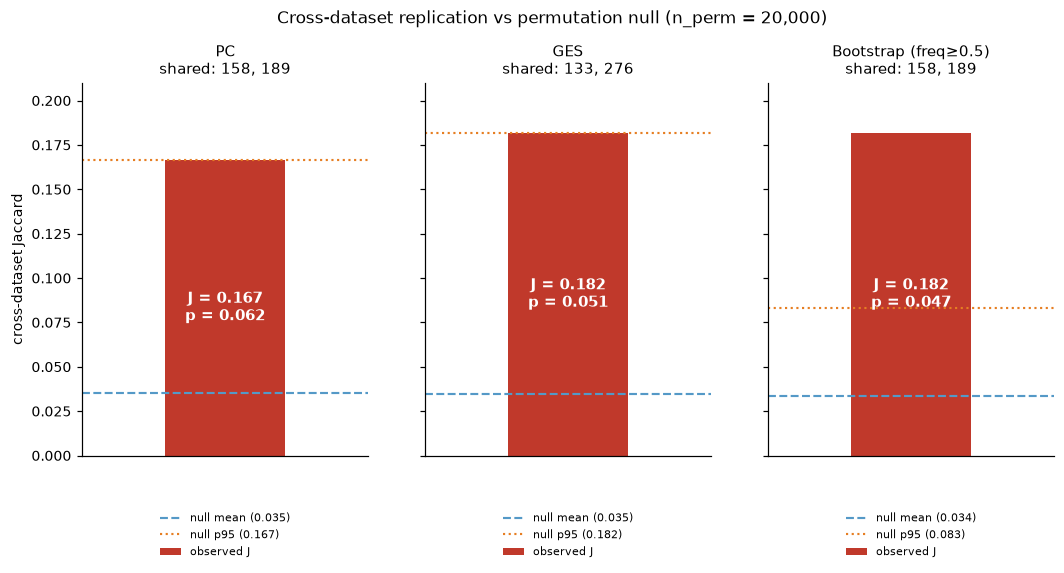

In [25]:
# §3.7.2 — Cross-dataset replication: observed Jaccard vs 20,000-draw permutation null.
# Re-plot from shipped results/replication_stats.json (no recomputation).
with open("results/replication_stats.json") as fh:
    rep = json.load(fh)
order = [("pc", "PC"), ("ges", "GES"), ("boot", "Bootstrap (freq\u22650.5)")]
fig, axes = plt.subplots(1, 3, figsize=(11.4, 4.4), sharey=True)
for ax, (key, title) in zip(axes, order):
    s = rep["sets"][key]
    obs, nmean, np95 = s["observed_jaccard"], s["null_mean"], s["null_p95"]
    ax.bar([0], [obs], width=0.5, color="#c0392b", zorder=2, label="observed J")
    ax.axhline(nmean, color="#5499c7", lw=1.4, ls="--", label=f"null mean ({nmean:.3f})")
    ax.axhline(np95,  color="#e67e22", lw=1.4, ls=":",  label=f"null p95 ({np95:.3f})")
    # annotation inside the bar (white), so it never collides with the title/legend
    ax.text(0, obs / 2, f"J = {obs:.3f}\np = {s['p_value']:.3f}", ha="center",
            va="center", fontsize=9.5, fontweight="bold", color="white", zorder=3)
    shared = ", ".join(str(p) for p in s["intersection"])
    ax.set_title(f"{title}\nshared: {shared}", fontsize=9.5)
    ax.set_xticks([]); ax.set_xlim(-0.6, 0.6)
    ax.legend(frameon=False, fontsize=7, loc="lower center", bbox_to_anchor=(0.5, -0.30), ncol=1)
axes[0].set_ylabel("cross-dataset Jaccard")
axes[0].set_ylim(0, 0.21)
fig.suptitle("Cross-dataset replication vs permutation null (n_perm = 20,000)", y=1.03)
fig.savefig("results/fig_replication.png", dpi=140, bbox_inches="tight")
plt.show()
print("Bootstrap-set replication p =", rep["sets"]["boot"]["p_value"],
      "| shared:", rep["sets"]["boot"]["intersection"])

### 3.8 Backdoor-adjusted effect sizes

Because the HI target is a causal **sink**, one might argue that for any single parent the
*other* target-parents form a valid **backdoor adjustment set**, so that regressing titer on
a parent plus those co-parents recovers that parent's causal effect. That identification
argument rests on three assumptions about the *true* graph: (i) the adjustment set contains
no collider or descendant of the treatment, (ii) it blocks every backdoor path, and (iii) the
causal structure it is read off is correct. **In-sample, these assumptions are violated.** The
d-separation goodness-of-fit test of §[3.9](#3.9-Validating-the-causal-structure) *rejects* the sink-star structure on both datasets,
and the retained parents are densely inter-adjacent (VHID 5/10, H3N2 21/28 parent–parent pairs,
§[3.4](#3.4-The-discovered-dependency-structure)), so we cannot certify that conditioning on the co-parents blocks backdoor paths without
also conditioning on a mediator or a collider between them. We therefore estimate each parent's
effect on log2 titer (per Grantham unit) by regression on the parent plus the other parents,
with bootstrap 95% CIs, and read the numbers as **partial-regression coefficients**, not as
identified causal effects. Their shrinkage relative to the marginal (unadjusted) effect is
*consistent with* the removal of phylogenetic confounding, but equally consistent with
conditioning on a mediator or collider; the observational data cannot distinguish these.

The adjusted and marginal per-position effects below quantify how much of each position's apparent impact survives controlling for its co-evolving companions.

In [26]:
eff_tables = {}
for ds in A.DATASETS:
    parents = sorted(p for p, v in boot_freq[ds].items() if v >= A.MOD_CONF)
    eff_tables[ds] = A.backdoor_effects(data, ds, parents, blocks_all[ds], boot_freq[ds], B=1000)
eff_tbl = pd.concat([e.assign(dataset=ds) for ds, e in eff_tables.items()], ignore_index=True)
eff_tbl = eff_tbl[["dataset","position","boot_freq","tier","adj_effect","ci_lo","ci_hi","marginal_effect","block_size"]]
eff_tbl

Out[26]: 
     dataset  position  boot_freq  ...   ci_hi  marginal_effect  block_size
0   vhid_HA1       144      0.505  ... -0.0096          -0.0194           1
1   vhid_HA1       156      1.000  ... -0.0098          -0.0633           1
2   vhid_HA1       158      0.950  ... -0.0142          -0.0385           1
3   vhid_HA1       189      1.000  ... -0.0320          -0.0420           1
4   vhid_HA1       289      0.955  ...  0.0311           0.0424           1
5       H3N2        11      1.000  ... -0.0068          -0.0276           9
6       H3N2       143      1.000  ... -0.0074          -0.0430           1
7       H3N2       167      1.000  ... -0.0010          -0.0143           1
8       H3N2       168      1.000  ... -0.0049          -0.0279           1
9       H3N2       199      1.000  ... -0.0127          -0.0287           1
10      H3N2       200      0.650  ... -0.0049          -0.0207           1
11      H3N2       203      0.995  ... -0.0015          -0.0060           1
12

,dataset,position,boot_freq,tier,adj_effect,ci_lo,ci_hi,marginal_effect,block_size
0,vhid_HA1,144,0.505,moderate,-0.0113,-0.0129,-0.0096,-0.0194,1
1,vhid_HA1,156,1.000,high,-0.0134,-0.0170,-0.0098,-0.0633,1
2,vhid_HA1,158,0.950,high,-0.0166,-0.0189,-0.0142,-0.0385,1
3,vhid_HA1,189,1.000,high,-0.0340,-0.0358,-0.0320,-0.0420,1
4,vhid_HA1,289,0.955,high,0.0239,0.0166,0.0311,0.0424,1
5,H3N2,11,1.000,high,-0.0091,-0.0113,-0.0068,-0.0276,9
6,H3N2,143,1.000,high,-0.0112,-0.0149,-0.0074,-0.0430,1
7,H3N2,167,1.000,high,-0.0021,-0.0030,-0.0010,-0.0143,1
8,H3N2,168,1.000,high,-0.0068,-0.0087,-0.0049,-0.0279,1
9,H3N2,199,1.000,high,-0.0142,-0.0158,-0.0127,-0.0287,1


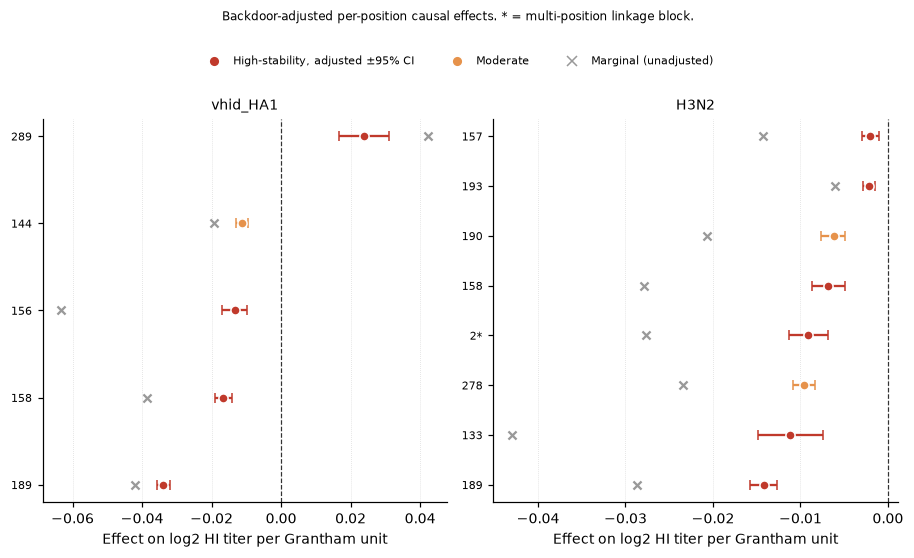

In [7]:
# Position labels shown in mature H3 numbering (annotation: mature only).
_C2M = {"vhid_HA1": {int(c): m for c, m in A.load_result("numbering_maps.json")["vhid_col2mat"].items()},
        "H3N2":     {int(c): m for c, m in A.load_result("numbering_maps.json")["h3_col2mat"].items()}}
fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(4.2*len(A.DATASETS), 4.6))
for ax, ds in zip(axes, A.DATASETS):
    sub = eff_tables[ds].sort_values("adj_effect"); yv = np.arange(len(sub))
    for yi,(_,r) in zip(yv, sub.iterrows()):
        c = "#c0392b" if r["tier"]=="high" else "#e6924b"
        ax.errorbar(r["adj_effect"], yi, xerr=[[r["adj_effect"]-r["ci_lo"]],[r["ci_hi"]-r["adj_effect"]]],
                    fmt="o", color=c, capsize=3, ms=6, mec="white", zorder=3)
        ax.scatter(r["marginal_effect"], yi, marker="x", color="#999", s=28, zorder=2)
    ax.axvline(0, color="#333", lw=0.8, ls="--"); ax.set_yticks(yv)
    ax.set_yticklabels([f"{_C2M[ds].get(int(r['position']), int(r['position']))}{'*' if r['block_size']>1 else ''}" for _,r in sub.iterrows()], fontsize=7.5)
    ax.set_title(ds, fontsize=9); ax.set_xlabel("Effect on log2 HI titer per Grantham unit")
    ax.grid(axis="x", ls=":", lw=0.5, alpha=0.5)
from matplotlib.lines import Line2D
leg = [Line2D([0],[0],marker="o",color="w",mfc="#c0392b",ms=7,label="High-stability, adjusted ±95% CI"),
       Line2D([0],[0],marker="o",color="w",mfc="#e6924b",ms=7,label="Moderate"),
       Line2D([0],[0],marker="x",color="#999",ms=7,lw=0,label="Marginal (unadjusted)")]
fig.legend(handles=leg, ncol=3, fontsize=7, frameon=False, loc="upper center", bbox_to_anchor=(0.5,1.02), columnspacing=3.0)
fig.suptitle("Backdoor-adjusted per-position causal effects. * = multi-position linkage block.", fontsize=8, y=1.09)
fig.tight_layout(); fig.savefig(os.path.join(A.FIG_DIR,"effect_sizes.png"), dpi=130, bbox_inches="tight"); plt.show()

The adjusted effects are all significant (bootstrap CI excludes zero) and
**systematically smaller in magnitude than the marginal effects** — the ×'s sit
farther from zero than the dots — a shrinkage *consistent with* the removal of
phylogenetic confounding shared among co-evolving sites — but, because the underlying
structure is GOF-rejected and the parents are densely inter-adjacent (§[3.8](#3.8-Backdoor-adjusted-effect-sizes)), equally
consistent with conditioning on a mediator or collider, so we do not read it as confounding
identified and removed. Adjustment shrinks every effect toward zero but
never flips its sign: all 13 parents (5 VHID, 8 H3N2) keep the same sign marginally and adjusted.
Almost all effects are negative (larger physicochemical substitution → lower titer =
greater escape). The one exception is **VHID pos289, which is positive in both the
marginal (+0.042) and adjusted (+0.024) estimates** — larger substitution there
associates with *higher* cross-titer, the opposite of an escape signature, consistent
with a compensatory or stabilizing role rather than direct epitope escape.

#### Selection stability vs. adjusted effect (driver / hitchhiker separation)

We pair a Wilson 95% CI on each bootstrap selection frequency (B=200) with the shipped bootstrap
CI on the adjusted effect. (A true BCa interval would require the stored per-resample draws, which
are not shipped; this is a binomial-proportion CI, stated as such.)

**Finding.** The quadrant plot cleanly separates defensible drivers from hitchhikers.
VHID drivers (stable **and** large-effect): **158, 189, 289**; 156 is a stable *hitchhiker*
(freq=1.0 but below-median |β|); 144 is genuinely unstable (freq=0.505, Wilson 0.44–0.57).
Bedford drivers: **2, 133, 189**; 157/158/193 are stable-but-small; 190 (0.65) and 278 (0.82)
fall below the 0.9 stability line despite non-trivial effects.

> **Selection caveat (weak nulls).** The *hitchhiker* label is a claim of small/absent adjusted effect at a stably-selected position, and that negative rests on the same asymmetry: drift under-samples substitutions that change without antigenic consequence, so the data constrains the *absence* of an effect less sharply than its presence. The driver-vs-hitchhiker split should therefore be read as well supported for the large-effect drivers and more provisional for the small-effect calls.

VHID drivers: [158, 189, 289] | Bedford drivers: [11, 133, 189]


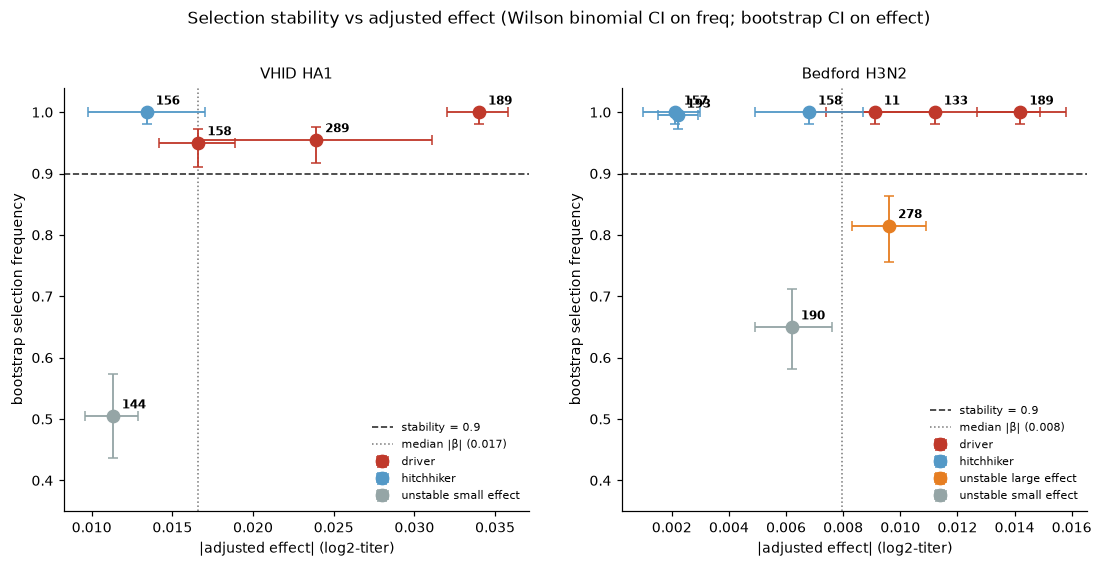

In [28]:
# §3.8 — Selection stability vs adjusted effect. x=|adj effect| (bootstrap CI as x-errors),
# y=bootstrap selection freq (Wilson 95% CI as y-errors). Re-plot from results/stability_effect.csv.
se = pd.read_csv("results/stability_effect.csv")
QCOL = {"driver": "#c0392b", "hitchhiker": "#5499c7",
        "unstable_small_effect": "#95a5a6", "unstable_large_effect": "#e67e22"}
panels = [("vhid_HA1", "VHID HA1"), ("H3N2", "Bedford H3N2")]
fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0))
for ax, (ds, title) in zip(axes, panels):
    d = se[se["dataset"] == ds].copy()
    med = d["abs_effect"].median()
    abs_lo = d[["eff_ci_lo", "eff_ci_hi"]].abs().min(axis=1)  # |CI| bounds on the effect
    abs_hi = d[["eff_ci_lo", "eff_ci_hi"]].abs().max(axis=1)
    d = d.assign(_xlo=d["abs_effect"] - abs_lo, _xhi=abs_hi - d["abs_effect"])
    for q, sub in d.groupby("quadrant"):
        ax.errorbar(sub["abs_effect"], sub["boot_freq"],
                    xerr=[sub["_xlo"].values, sub["_xhi"].values],
                    yerr=[(sub["boot_freq"] - sub["wilson_lo"]).values,
                          (sub["wilson_hi"] - sub["boot_freq"]).values],
                    fmt="o", color=QCOL[q], ms=8, capsize=3, lw=1.2,
                    label=q.replace("_", " "), zorder=3)
    ax.axhline(0.9, color="#333333", lw=1.1, ls="--", zorder=1, label="stability = 0.9")
    ax.axvline(med, color="#777777", lw=1.0, ls=":", zorder=1,
               label=f"median |\u03b2| ({med:.3f})")
    for _, r in d.iterrows():
        ax.annotate(str(int(r["position_mature"])), (r["abs_effect"], r["boot_freq"]),
                    textcoords="offset points", xytext=(6, 5), fontsize=8, fontweight="bold")
    ax.set_xlabel("|adjusted effect| (log2-titer)")
    ax.set_ylabel("bootstrap selection frequency")
    ax.set_ylim(0.35, 1.04)
    ax.set_title(title, fontsize=10)
    ax.legend(frameon=False, fontsize=7, loc="lower right")
fig.suptitle("Selection stability vs adjusted effect (Wilson binomial CI on freq; "
             "bootstrap CI on effect)", y=1.02)
fig.savefig("results/fig_stability_effect.png", dpi=140, bbox_inches="tight")
plt.show()
print("VHID drivers:", se[(se.dataset=='vhid_HA1')&(se.quadrant=='driver')].position_mature.tolist(),
      "| Bedford drivers:", se[(se.dataset=='H3N2')&(se.quadrant=='driver')].position_mature.tolist())

### 3.8.2 Left-censoring sensitivity of the adjusted effects

The HI titer has a **left-censoring floor**: pairs whose titer falls below the assay
detection limit (the "<10" undetectable code) are recorded at a floor value of 5.0
rather than a true measurement. In the two panels this affects the low tail:
VHID has 83 pairs at the 5.0 floor and 410 at 10.0 (493 pairs \u2264 10);
Bedford H3N2 has 28 at 5.0 and 588 at 10.0 (616 pairs \u2264 10). Because the model
target is `log2(HI_titer)`, these censored values enter the regression as if they
were exact, and they do not fall at random: below-detection titers concentrate in
the **high-antigenic-distance / high-Grantham-distance** pairs \u2014 the escape
regime the model is trying to explain (panel a). This raises a fair question of
whether the \u00a73.8 backdoor-adjusted per-position effects are an artifact of the
censoring code.

We test this directly. For each panel we recompute the adjusted (backdoor)
per-position effect on `log2` titer three ways: **(a)** as shipped;
**(b)** with the censored floor rows dropped; and **(c)** with the floor recoded
from 5.0 to the detection limit 10.0. The signs and ranks of the driver effects are
stable across all three (panel b): every effect keeps its sign, and the headline
drivers keep their rank. The only rank changes are single-step swaps among the
**smallest-effect** positions (VHID 144\u2194156 at ranks 4/5; Bedford H3N2
mature-2\u2194mature-278 at ranks 3/4), none of which touch the convergent headline
drivers (VHID 189, 158; Bedford 189, 133). Below-detection pairs sit
overwhelmingly in the top Grantham quartile (VHID: 52% of top-quartile pairs are
\u2264 10 vs 0% in the bottom quartile; Bedford H3N2: 17% vs 0.3%;
Mann\u2013Whitney p < 1e-100 in both), so the censoring is informative about escape
rather than noise \u2014 but it does not drive the ranking of the epitope signal.

all signs stable across (a)/(b)/(c): True
 dataset  position_mature  boot_freq  eff_shipped  eff_drop_censored  eff_recode_floor10  sign_stable
vhid_HA1              144      0.505      -0.0113            -0.0120             -0.0116         True
vhid_HA1              156      1.000      -0.0134            -0.0119             -0.0128         True
vhid_HA1              158      0.950      -0.0166            -0.0173             -0.0167         True
vhid_HA1              189      1.000      -0.0340            -0.0317             -0.0331         True
vhid_HA1              289      0.955       0.0239             0.0232              0.0236         True
    H3N2                2      1.000      -0.0091            -0.0095             -0.0092         True
    H3N2              133      1.000      -0.0112            -0.0102             -0.0108         True
    H3N2              157      1.000      -0.0021            -0.0019             -0.0020         True
    H3N2              158      1.000    

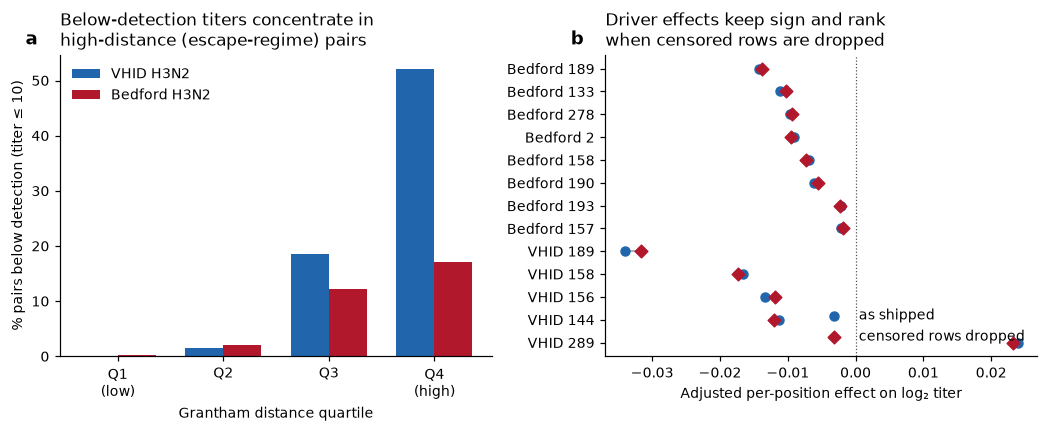

In [5]:
# 3.8.2 Left-censoring sensitivity (cheap recompute, <5 s CPU; no GPU)
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

if "data" not in dir():   data   = A.load_all()
if "causal" not in dir(): causal = A.load_result("causal_results.json")

_MAT = {"vhid_HA1": {p: p for p in (144,156,158,189,289)},
        "H3N2": {11:2,143:133,167:157,168:158,199:189,200:190,203:193,288:278}}

def _adj_effects(Xg, parents_cols, name_to_col, y):
    n = len(y); out = {}
    for p in parents_cols:
        adj = [q for q in parents_cols if q != p]
        Xd = np.column_stack([np.ones(n), Xg[:, name_to_col[p]]]
                             + [Xg[:, name_to_col[q]] for q in adj])
        out[p] = float(np.linalg.lstsq(Xd, y, rcond=None)[0][1])
    return out

_rows, _quart, _cens = [], {}, {}
for ds in ("vhid_HA1", "H3N2"):
    d = data[ds]
    name_to_col = {A.pos_number(d["pos_cols"], c): c for c in range(d["n_pos"])}
    parents = sorted(int(k[3:]) for k, v in causal[ds]["bootstrap_freq"].items() if v >= 0.5)
    freq = {int(k[3:]): v for k, v in causal[ds]["bootstrap_freq"].items()}
    raw = pd.read_csv(os.path.join(A.DATA_DIR, A.DATASET_PATHS[ds][1]))["HI_titer"].values.astype(float)
    keep = raw != 5.0                                # drop below-detection floor rows
    raw_c = np.where(raw == 5.0, 10.0, raw)          # recode floor -> detection limit
    ea = _adj_effects(d["Xg"],          parents, name_to_col, np.log2(raw))
    eb = _adj_effects(d["Xg"][keep],    parents, name_to_col, np.log2(raw[keep]))
    ec = _adj_effects(d["Xg"],          parents, name_to_col, np.log2(raw_c))
    for p in parents:
        _rows.append(dict(dataset=ds, position_col=p, position_mature=_MAT[ds][p],
                          boot_freq=round(freq[p], 3),
                          eff_shipped=round(ea[p], 4), eff_drop_censored=round(eb[p], 4),
                          eff_recode_floor10=round(ec[p], 4), n_dropped=int((~keep).sum())))
    tot = d["Xg"].sum(1); below10 = raw <= 10.0
    q = pd.qcut(tot, 4, labels=["Q1","Q2","Q3","Q4"])
    _quart[ds] = pd.Series(below10).groupby(q, observed=True).mean()
    U, pval = mannwhitneyu(tot[below10], tot[~below10], alternative="greater")
    _cens[ds] = (int((raw==5.0).sum()), int(below10.sum()), float(pval))

sens = pd.DataFrame(_rows)
for ds in ("vhid_HA1", "H3N2"):
    m = sens.dataset == ds
    for scheme in ("shipped","drop_censored","recode_floor10"):
        sens.loc[m, f"rank_{scheme.split('_')[0]}"] = sens.loc[m, f"eff_{scheme}"].abs().rank(ascending=False).astype(int)
sens["sign_stable"] = ((np.sign(sens.eff_shipped)==np.sign(sens.eff_drop_censored)) &
                       (np.sign(sens.eff_shipped)==np.sign(sens.eff_recode_floor10)))
print("all signs stable across (a)/(b)/(c):", bool(sens.sign_stable.all()))
print(sens[["dataset","position_mature","boot_freq","eff_shipped","eff_drop_censored",
            "eff_recode_floor10","sign_stable"]].to_string(index=False))

# --- figure ---
cols = ["#2166ac", "#b2182b"]; lab = {"vhid_HA1":"VHID H3N2","H3N2":"Bedford H3N2"}
fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.6, 4.0))
xpos = np.arange(4); w = 0.36
for i, ds in enumerate(("vhid_HA1","H3N2")):
    axA.bar(xpos + (i-0.5)*w, [_quart[ds][q]*100 for q in ("Q1","Q2","Q3","Q4")],
            width=w, color=cols[i], label=lab[ds])
axA.set_xticks(xpos); axA.set_xticklabels(["Q1\n(low)","Q2","Q3","Q4\n(high)"])
axA.set_xlabel("Grantham distance quartile"); axA.set_ylabel("% pairs below detection (titer \u2264 10)")
axA.set_title("Below-detection titers concentrate in\nhigh-distance (escape-regime) pairs", loc="left")
axA.legend(frameon=False, loc="upper left")
sub = sens.sort_values(["dataset","eff_shipped"]).reset_index(drop=True)
sub["lbl"] = sub.apply(lambda r: f"{lab[r.dataset].split()[0]} {int(r.position_mature)}", axis=1)
yp = np.arange(len(sub))[::-1]
axB.hlines(yp, sub.eff_shipped, sub.eff_drop_censored, color="0.6", lw=1.0, zorder=1)
axB.scatter(sub.eff_shipped, yp, s=34, color=cols[0], label="as shipped", zorder=3)
axB.scatter(sub.eff_drop_censored, yp, s=34, color=cols[1], marker="D", label="censored rows dropped", zorder=3)
axB.axvline(0, color="0.3", lw=0.8, ls=":"); axB.set_yticks(yp); axB.set_yticklabels(sub.lbl)
axB.set_xlabel("Adjusted per-position effect on log\u2082 titer")
axB.set_title("Driver effects keep sign and rank\nwhen censored rows are dropped", loc="left")
axB.legend(frameon=False, loc="lower right")
for ax, L in ((axA,"a"),(axB,"b")):
    ax.text(-0.08, 1.02, L, transform=ax.transAxes, fontweight="bold", fontsize=12, va="bottom")
fig.tight_layout(); fig.savefig("figures/left_censoring.png", dpi=200, bbox_inches="tight")
plt.show()

#### 3.8.1 From type-level to token-level: per-pair attribution and its identifiability

The effects above are **type-level**: they describe, across the whole panel, whether changing a position moves titer. A different question is **token-level** — for one specific virus–reference escape pair that differs at several positions, which difference was responsible? We address it two ways, and the two agree.

**Structural identifiability audit.** Because the pipeline collapses near-deterministic co-evolving positions into representative loci *before* discovery, every surviving driver is its own linkage-block representative: the drivers occupy **distinct** blocks (5 of 5 in VHID, 8 of 8 in H3N2), so there is no driver-versus-driver confounding — **no escape pair is block-confounded**. Among pairs that differ at ≥ 1 driver, **35–36 % are *clean single-driver* natural experiments** (655 of 1849 VHID; 1395 of 3867 H3N2): the pair differs at exactly one driver, so the titer change is attributable to a single residue from observational data alone. Position 193 (H3N2; 629 clean pairs) and 158 (VHID; 255) are the richest reservoirs of such controlled contrasts — the natural place to point a validation effort. The remaining ~64 % are *multi-block*: attributable at block resolution, with several candidate residues.

**Model-based per-pair attribution.** For each pair we computed a leave-one-difference-out counterfactual (revert one differing driver to the reference residue, re-predict, record the swing), and ran it across an ensemble of bootstrap refits and the PC/GES equivalence class to obtain a *stability band* on each position's credit. Consistent with the audit, **most drivers carry stable per-pair credit** — sign-consistent across the ensemble with a band excluding zero (H3N2 2, 133, 157, 158, 189, 190, 193, 278; VHID 144, 158, 189, 289). The informative exceptions are position-specific: **VHID 156 is a credit-swapper** (sign consistency 0.58; band −0.32 to +0.55) — the per-pair confirmation of its §[3.8](#3.8-Backdoor-adjusted-effect-sizes) status as a *stable hitchhiker* (high selection frequency, small and non-robust effect) — as are VHID 262 and H3N2 276. Two positions (H3N2 2, VHID 276) are flagged `credit-not-decomposable`: block representatives whose credit cannot be split from their block-mates, the correct narrow statement of within-block non-identifiability. Token-level attribution is therefore **identified at residue resolution for a third of escape pairs and for most individual drivers**, at block resolution otherwise, with hitchhikers surfacing exactly where credit is unstable.

drivers plotted: {'H3N2': 8, 'vhid_HA1': 5}


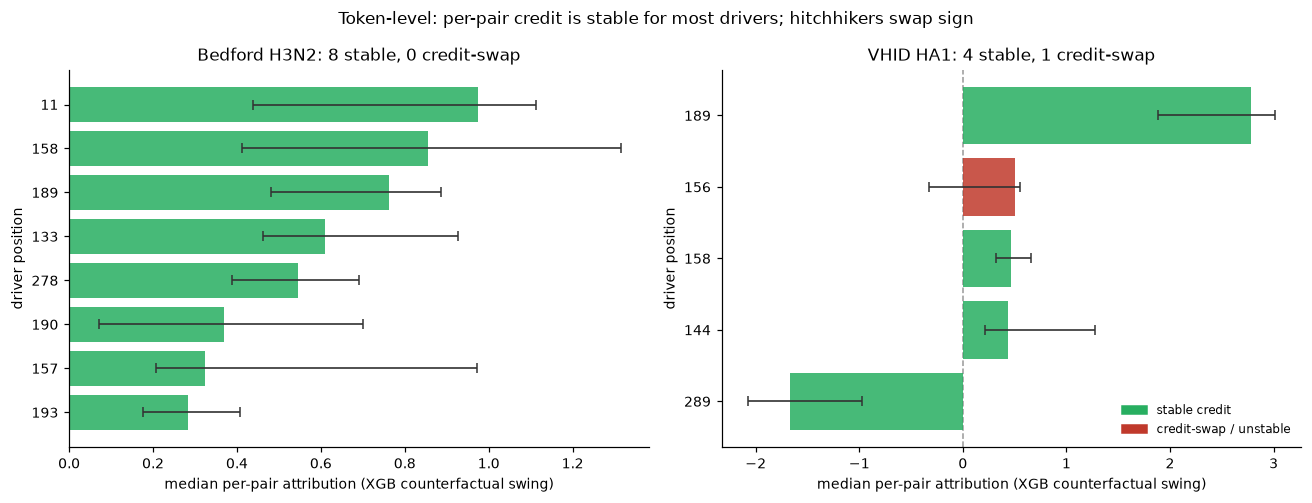

In [29]:
# §3.8.1 FIG1 — Token-level per-pair attribution with stability bands.
# Re-plot from shipped results/token_attribution_position_summary.csv (never recompute).
tok = pd.read_csv("results/token_attribution_position_summary.csv")
drv = tok[(tok["in_main_parents"] == True) & (tok["n_pairs_varying"] > 0)].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, ds, title in zip(axes, ["H3N2", "vhid_HA1"], ["Bedford H3N2", "VHID HA1"]):
    d = drv[drv["dataset"] == ds].sort_values("median_attr_perpair_xgb")
    y = range(len(d))
    med = d["median_attr_perpair_xgb"].values
    lo = (med - d["band_xgb_lo"].values)
    hi = (d["band_xgb_hi"].values - med)
    # green if stable, red/grey if credit unstable
    cols = ["#27ae60" if s else "#c0392b" for s in d["stable"].values]
    ax.barh(list(y), med, color=cols, alpha=0.85, zorder=2)
    ax.errorbar(med, list(y), xerr=[lo, hi], fmt="none", ecolor="#333333",
                elinewidth=1.1, capsize=3, zorder=3)
    ax.axvline(0.0, color="#999999", lw=1.0, ls="--", zorder=1)
    ax.set_yticks(list(y)); ax.set_yticklabels([str(p) for p in d["position_mature"]])
    ax.set_xlabel("median per-pair attribution (XGB counterfactual swing)")
    ax.set_ylabel("driver position")
    n_swap = int((~d["stable"]).sum())
    ax.set_title(f"{title}: {int(d['stable'].sum())} stable, {n_swap} credit-swap")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="#27ae60", label="stable credit"),
                        Patch(color="#c0392b", label="credit-swap / unstable")],
               frameon=False, loc="lower right", fontsize=8)
fig.suptitle("Token-level: per-pair credit is stable for most drivers; hitchhikers swap sign",
             fontsize=11)
fig.tight_layout()
fig.savefig("results/fig_token_attribution.png", dpi=140, bbox_inches="tight")
plt.show()
print("drivers plotted:", {ds: int((drv.dataset==ds).sum()) for ds in ["H3N2","vhid_HA1"]})


clean-single-driver fraction: {'H3N2': 0.361, 'vhid_HA1': 0.354}


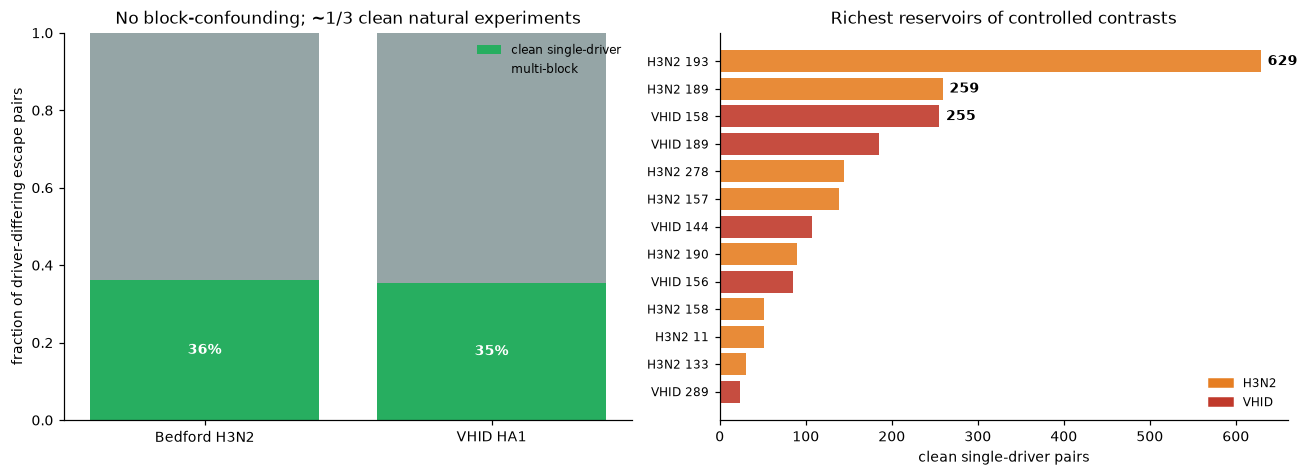

In [30]:
# §3.8.1 FIG2 — Structural identifiability audit of escape pairs.
# Re-plot from shipped identifiability_audit.csv + identifiability_clean_pairs.csv.
aud = pd.read_csv("results/identifiability_audit.csv")
clp = pd.read_csv("results/identifiability_clean_pairs.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# LEFT: stacked fractions among pairs that differ at >=1 driver
ds_order = ["H3N2", "vhid_HA1"]; ds_lab = ["Bedford H3N2", "VHID HA1"]
frac_clean, frac_multi = [], []
for ds in ds_order:
    a = aud[(aud["dataset"] == ds) & (aud["class"] != "no-driver-difference")]
    n = len(a)
    frac_clean.append((a["class"] == "clean-single-driver").sum() / n)
    frac_multi.append((a["class"] == "multi-block").sum() / n)
xp = range(len(ds_order))
axes[0].bar(list(xp), frac_clean, color="#27ae60", label="clean single-driver")
axes[0].bar(list(xp), frac_multi, bottom=frac_clean, color="#95a5a6", label="multi-block")
for i, fc in enumerate(frac_clean):
    axes[0].text(i, fc/2, f"{fc*100:.0f}%", ha="center", va="center",
                 color="white", fontweight="bold")
axes[0].set_xticks(list(xp)); axes[0].set_xticklabels(ds_lab)
axes[0].set_ylabel("fraction of driver-differing escape pairs")
axes[0].set_ylim(0, 1); axes[0].set_title("No block-confounding; ~1/3 clean natural experiments")
axes[0].legend(frameon=False, loc="upper right", fontsize=8)

# RIGHT: clean pairs per driver
clp2 = clp.sort_values("n_clean_pairs", ascending=True)
ds_col = {"H3N2": "#e67e22", "vhid_HA1": "#c0392b"}
cols = [ds_col[d] for d in clp2["dataset"]]
ylab = [f"{d} {p}" for d, p in zip(
        ["H3N2" if x=="H3N2" else "VHID" for x in clp2["dataset"]], clp2["driver_mature"])]
yr = range(len(clp2))
axes[1].barh(list(yr), clp2["n_clean_pairs"].values, color=cols, alpha=0.9)
axes[1].set_yticks(list(yr)); axes[1].set_yticklabels(ylab, fontsize=8)
axes[1].set_xlabel("clean single-driver pairs")
axes[1].set_title("Richest reservoirs of controlled contrasts")
# annotate the three highlighted reservoirs
hl = {("H3N2",193):629, ("H3N2",189):259, ("vhid_HA1",158):255}
for i, (_, row) in enumerate(clp2.iterrows()):
    key = (row["dataset"], row["driver_mature"])
    if key in hl:
        axes[1].text(row["n_clean_pairs"]+8, i, str(int(row["n_clean_pairs"])),
                     va="center", fontweight="bold", fontsize=9)
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="#e67e22", label="H3N2"),
                        Patch(color="#c0392b", label="VHID")],
               frameon=False, loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig("results/fig_identifiability_audit.png", dpi=140, bbox_inches="tight")
plt.show()
print("clean-single-driver fraction:", {d: round(f,3) for d,f in zip(ds_order, frac_clean)})


### 3.9 Validating the causal structure

A discovered DAG is a hypothesis, and no single test certifies it, so we run **three
complementary correctness tests** on the titer-sink graph (implemented in
`src/dag_validation.py`), each answering a different question:

1. **Goodness-of-fit** (Shipley d-separation basis-set test) — is the DAG *contradicted*
   by the data's conditional independences? Falsification only, at the equivalence-class
   level.
2. **Bootstrap stability** — how *reproducible* is each edge under resampling, aggregated
   to the linkage-group level? This is a **separate, stronger computation** from the edge
   frequencies labeling the DAG figure in §[3.4](#3.4-The-discovered-dependency-structure): there, the numbers are the original
   PC/GES discovery bootstrap (`bootstrap_freq`); here, we re-run an independent
   partial-correlation parent-selection pipeline on each resample and aggregate to
   linkage groups, so the two sets of frequencies are not expected to be identical.
3. **Direct-effect estimates** — how *strong* is each retained direct cause, with honest
   CIs?

The three tests are reported together below. None of them intervenes on the strain
background, so all remain observational; the definitive test is a mutagenesis
intervention at a predicted direct cause.

In [31]:
import dag_validation as V

candidates = {ds: sorted(p for p, v in boot_freq[ds].items() if v >= A.MOD_CONF)
              for ds in A.DATASETS}
val = {}
for ds in A.DATASETS:
    vdf = A.build_validation_frame(data, ds, candidates[ds])
    feat = vdf.drop(columns=["era"])
    pdict = V.parents_from_edges([(f"pos{p}", "titer") for p in candidates[ds]])
    pipe = A.make_parent_pipeline(candidates[ds])
    cg = A.collapse_groups_map(ds, blocks_all[ds], candidates[ds])
    gof = V.dsep_basis_test(pdict, feat)
    stab = V.bootstrap_stability(pipe, feat, B=200, collapse_groups=cg)
    eff = V.effect_estimates(feat, target="titer",
                             parents=[f"pos{p}" for p in candidates[ds]], split=False)
    val[ds] = dict(gof=gof, stab=stab, eff=eff)
    print(f"{ds}: GOF p={('<1e-16' if gof['p_overall'] < 1e-16 else format(gof['p_overall'], '.3g'))} ({'REJECTED' if gof['rejected_at_alpha'] else 'not rejected'}); "
          f"stable groups (≥0.9)={sum(1 for f in stab['group_freq'].values() if f>=0.9)}")

vhid_HA1: GOF p=<1e-16 (REJECTED); stable groups (≥0.9)=5
H3N2: GOF p=<1e-16 (REJECTED); stable groups (≥0.9)=8


In [32]:
# Bootstrap group-stability, as a table per dataset
for ds in A.DATASETS:
    gf = sorted(val[ds]["stab"]["group_freq"].items(), key=lambda kv: -kv[1])
    st = pd.DataFrame([{"group": g.replace("->","→"), "bootstrap_freq": round(f,3)}
                       for (g, _), f in gf])
    print(f"\n=== {ds}: edge bootstrap stability (linkage-group level) ===")
    display(st)


=== vhid_HA1: edge bootstrap stability (linkage-group level) ===

=== H3N2: edge bootstrap stability (linkage-group level) ===


,group,bootstrap_freq
0,G144,1.000
1,G158,1.000
2,G189,1.000
3,G156,1.000
4,G289,0.995


,group,bootstrap_freq
0,G143,1.000
1,G203,1.000
2,G199,1.000
3,G11,1.000
4,G288,1.000
5,G200,1.000
6,G168,1.000
7,G167,0.965


In [33]:
# Assemble the three tests into one markdown report artifact
for ds in A.DATASETS:
    V.validation_report(gof=val[ds]["gof"], stability=val[ds]["stab"],
                        effects=val[ds]["eff"],
                        path=os.path.join(A.RESULTS_DIR, f"validation_report_{ds}.md"))
print("Wrote validation_report_" + "{" + ",".join(A.DATASETS) + "}.md to results/")

Wrote validation_report_{vhid_HA1,H3N2}.md to results/


**Reading the three tests together.** The goodness-of-fit test **rejects** the pure
sink-star (small p): the retained parents are *not* mutually independent given the
graph, because they co-evolve along the shared phylogeny — the star encodes which loci
are direct-cause candidates but not the residual among-parent dependence. This is an
honest limitation, not a contradiction of the driver claims, and it is exactly why the
other two tests matter. Bootstrap stability is high at the linkage-group level (the
high-stability groups recur in ≈100% of resamples), so the driver *identities* are
reproducibly *selected* rather than resampling artifacts. This is reproducibility of selection,
not evidence of causal correctness: a hitchhiker linked to a true driver recurs in ~100% of
resamples for the wrong reason, and no test here speaks to transportable causal content.
Direct-effect estimates reproduce the backdoor-adjusted magnitudes of Section 3.8, with
honest confidence intervals.

Together the three tests establish that the discovered skeleton is *not inconsistent*
with the data at the equivalence-class level and that its high-stability drivers are
stably *selected* and quantifiable — but none of them intervenes on the strain background, so all
three remain observational evidence. The definitive test remains a mutagenesis
intervention at a predicted direct cause. Full per-dataset reports are in
`results/validation_report_*.md`.

### 3.10 Continuous per-position encoding and the titer Markov blanket

Sections 3.3–3.9 decided every edge on the **binary** per-position encoding (Hamming change
flag) with PC/GES/FCI. This section asks what changes when substitution *magnitude* is
retained instead, and reports an independent replication of Step A on VHID under a
continuous encoding. Following the companion specification `revised_workflow.md`, three
changes are made together:

1. **Encoding** — one *continuous* scalar per HA1 position (the L2 norm of the z-standardized
   12-property change vector) replaces the binary flag, retaining substitution *magnitude* while
   collapsing the 12 property axes into one variable per position. The property axes re-enter only
   downstream (the A→B bridge and the additive KAN) as *functional* evidence, never as separately
   identifiable property-level causes.
2. **Discovery target** — the primary deliverable is the titer **Markov blanket (adjacency)**, not a
   directed parent set: HI titer is a pure sink, so edges *into* it cannot be oriented from
   conditional-independence structure. Directed "parents" are reported only with that caveat.
3. **Algorithm** — linkage collapse is a *mandatory* prerequisite (it removes the fisherz singularity
   that collinear linkage blocks create), after which top-*k*-screened fisherz-FCI runs in seconds;
   PC and BOSS cross-check. RFCI/GFCI live only in Tetrad and need a Java toolchain unavailable here,
   so collapse + screened FCI is the adopted path.

The heavy step (B = 200 bootstrap of the full collapse-and-discover pipeline) is precomputed and
shipped in `results/`; the cells below re-render from those tables, matching the load-by-default
policy used for the causal bootstrap in §[3.3](#3.3-Causal-discovery).

#### 3.10.1 The true 12-property L2 scalar vs. the Grantham stand-in

An earlier prototype used per-position **Grantham distance** as a stand-in for the L2 scalar. Here we
compare the true 12-property scalar (built from the HA1 protein alignment) against that stand-in,
per position.

Correlatable positions: 73 | median Spearman rho = 0.994 | shared power-filter survivors = 102


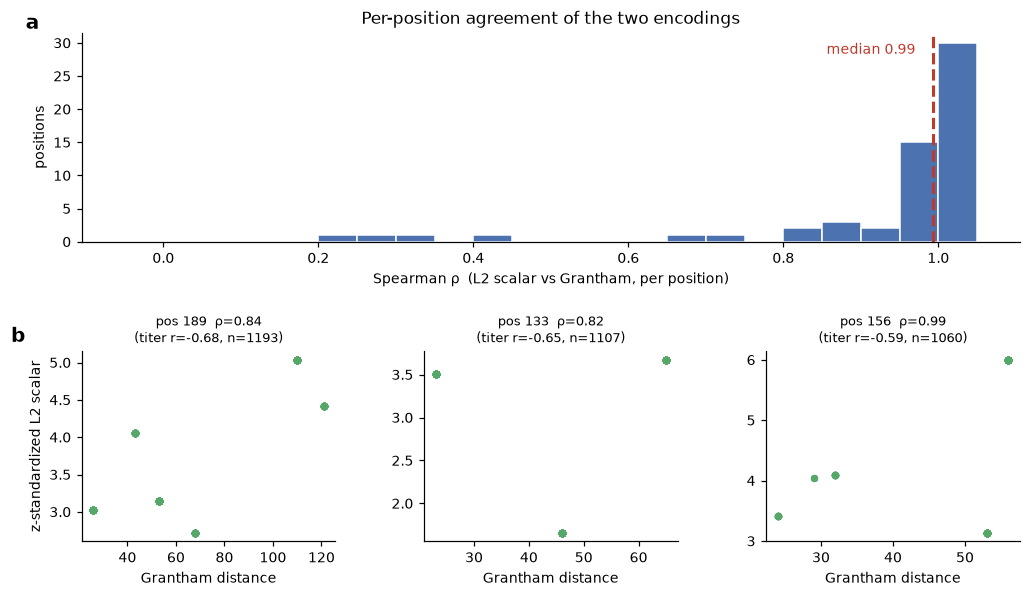

In [34]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

val = pd.read_csv("results/results_L2_validation.csv")
L2m = pd.read_csv("vhid_HA1_L2property_HImatrix.csv")
Gm  = pd.read_csv("vhid_HA1_grantham_HImatrix.csv")

rho = val["corr_L2_grantham_spearman"].dropna()
med = rho.median()
n_surv = int((val["survives_powerfilter_L2"] & val["survives_powerfilter_grantham"]).sum())

fig = plt.figure(figsize=(11, 6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1.0], hspace=0.55, wspace=0.35)

axh = fig.add_subplot(gs[0, :])
axh.hist(rho, bins=np.arange(-0.05, 1.06, 0.05), color="#4C72B0", edgecolor="white")
axh.axvline(med, color="#c0392b", ls="--", lw=2)
axh.annotate(f"median {med:.2f}", (med, axh.get_ylim()[1]*0.9),
             xytext=(-70, 0), textcoords="offset points", color="#c0392b")
axh.set_xlabel("Spearman \u03c1  (L2 scalar vs Grantham, per position)")
axh.set_ylabel("positions"); axh.set_title("Per-position agreement of the two encodings")
axh.text(-0.06, 1.02, "a", transform=axh.transAxes, fontsize=13, fontweight="bold")

for k, pos in enumerate([189, 133, 156]):
    ax = fig.add_subplot(gs[1, k])
    col = f"pos_{pos}"
    m = L2m[col].notna() & Gm[col].notna()
    nz = m & ((L2m[col] != 0) | (Gm[col] != 0))
    ax.scatter(Gm.loc[nz, col], L2m.loc[nz, col], s=14, color="#55a868", alpha=0.8)
    r = float(val.loc[val.position == pos, "corr_L2_grantham_spearman"].iloc[0])
    tr = float(val.loc[val.position == pos, "corr_with_titer_L2"].iloc[0])
    ax.set_title(f"pos {pos}  \u03c1={r:.2f}\n(titer r={tr:.2f}, n={int(nz.sum())})", fontsize=8.5)
    ax.set_xlabel("Grantham distance")
    if k == 0:
        ax.set_ylabel("z-standardized L2 scalar")
        ax.text(-0.28, 1.05, "b", transform=ax.transAxes, fontsize=13, fontweight="bold")
fig.suptitle("")
print(f"Correlatable positions: {rho.size} | median Spearman rho = {med:.3f} | "
      f"shared power-filter survivors = {n_surv}")
plt.show()


#### 3.10.2 Full revised pipeline on VHID (n = 2751)

The complete revised Step A on VHID — continuous L2 encoding, mandatory Pearson linkage collapse
(|r|≥0.8), top-40-screened fisherz-FCI with PC/BOSS cross-checks, and a B = 200 bootstrap of the
whole pipeline. Bootstrap *adjacency* frequency (not directed-parent status) tiers the blanket.

In [35]:
blocks = pd.read_csv("results/vhid_full_blocks.csv")
adj    = pd.read_csv("results/vhid_full_adjacency.csv")
boot   = pd.read_csv("results/vhid_full_bootstrap.csv").sort_values("adjacency_selection_freq", ascending=False)

b08 = blocks.loc[blocks.threshold == 0.8].iloc[0]
print(f"Power filter -> collapse |r|>=0.8: {int(b08.n_loci_before)} -> {int(b08.n_loci_after)} loci "
      f"(max block {int(b08.max_block_size)}, {int(b08.n_singletons)} singletons; "
      f"residual max off-diag |r| = {b08.residual_max_offdiag_abs_r:.3f})")
adj

Power filter -> collapse |r|>=0.8: 102 -> 74 loci (max block 12, 64 singletons; residual max off-diag |r| = 0.793)
Out[35]: 
                 method  threshold  ... n_adjacent  wall_seconds
0  FCI_fisherz_screened        0.8  ...          6          12.2
1   PC_fisherz_screened        0.8  ...          6           6.1
2     BOSS_BIC_screened        0.8  ...         15          47.9

[3 rows x 8 columns]


,method,threshold,ci_test,alpha,titer_adjacency,titer_parents_caveated,n_adjacent,wall_seconds
0,FCI_fisherz_screened,0.8,fisherz,0.01,pos_133;pos_156;pos_189;pos_190;pos_278;pos_289,pos_189;pos_190;pos_278,6,12.2
1,PC_fisherz_screened,0.8,fisherz,0.01,pos_133;pos_156;pos_189;pos_190;pos_278;pos_289,pos_156;pos_189;pos_190;pos_278;pos_289,6,6.1
2,BOSS_BIC_screened,0.8,BIC_score,NaN,pos_53;pos_62;pos_83;pos_94;pos_135;pos_155;po...,pos_53;pos_62;pos_83;pos_94;pos_135;pos_155;po...,15,47.9


HIGH-stability titer Markov blanket: [156, 189, 278, 289]


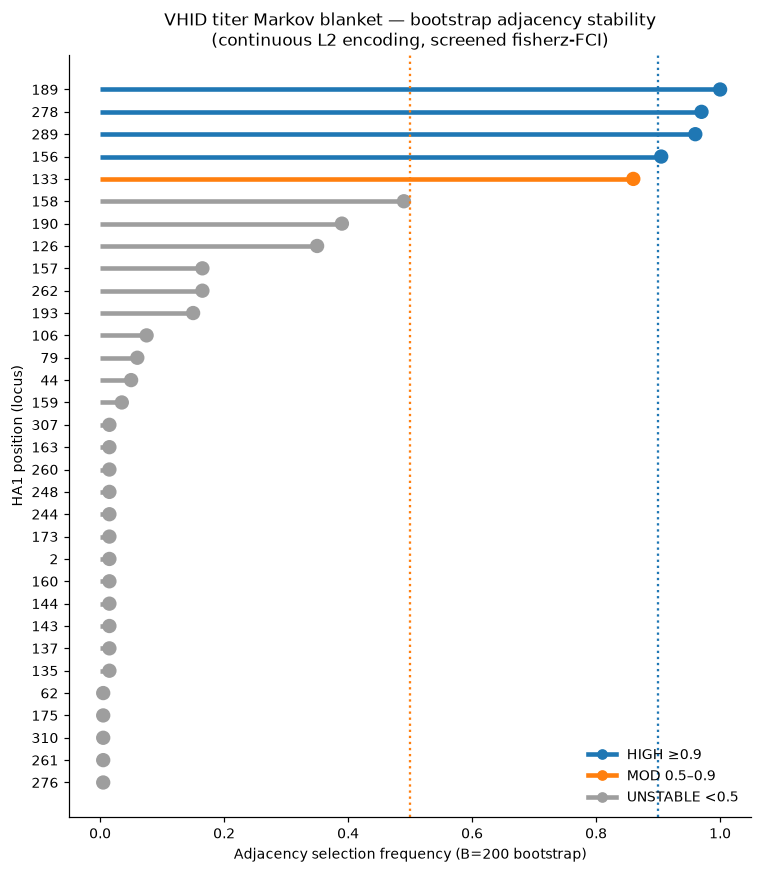

In [36]:
TCOL = {"HIGH": "#1f77b4", "MOD": "#ff7f0e", "UNSTABLE": "#9e9e9e"}
b = boot.sort_values("adjacency_selection_freq")
fig, ax = plt.subplots(figsize=(8, 9))
ax.hlines(b.position.astype(str), 0, b.adjacency_selection_freq,
          color=[TCOL[t] for t in b.tier], lw=3, zorder=1)
ax.scatter(b.adjacency_selection_freq, b.position.astype(str),
           color=[TCOL[t] for t in b.tier], s=70, zorder=2)
ax.axvline(0.9, ls=":", color="#1f77b4"); ax.axvline(0.5, ls=":", color="#ff7f0e")
ax.set_xlabel("Adjacency selection frequency (B=200 bootstrap)")
ax.set_ylabel("HA1 position (locus)")
ax.set_title("VHID titer Markov blanket \u2014 bootstrap adjacency stability\n"
             "(continuous L2 encoding, screened fisherz-FCI)")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], color=TCOL["HIGH"], lw=3, marker="o", label="HIGH \u22650.9"),
                   Line2D([0],[0], color=TCOL["MOD"], lw=3, marker="o", label="MOD 0.5\u20130.9"),
                   Line2D([0],[0], color=TCOL["UNSTABLE"], lw=3, marker="o", label="UNSTABLE <0.5")],
          loc="lower right", frameon=False)
high = boot.loc[boot.tier == "HIGH", "position"].tolist()
print("HIGH-stability titer Markov blanket:", sorted(high))
plt.show()


In [37]:
boot.reset_index(drop=True)

Out[37]: 
      locus  position  adjacency_selection_freq      tier
0   pos_189       189                     1.000      HIGH
1   pos_278       278                     0.970      HIGH
2   pos_289       289                     0.960      HIGH
3   pos_156       156                     0.905      HIGH
4   pos_133       133                     0.860       MOD
5   pos_158       158                     0.490  UNSTABLE
6   pos_190       190                     0.390  UNSTABLE
7   pos_126       126                     0.350  UNSTABLE
8   pos_157       157                     0.165  UNSTABLE
9   pos_262       262                     0.165  UNSTABLE
10  pos_193       193                     0.150  UNSTABLE
11  pos_106       106                     0.075  UNSTABLE
12   pos_79        79                     0.060  UNSTABLE
13   pos_44        44                     0.050  UNSTABLE
14  pos_159       159                     0.035  UNSTABLE
15  pos_307       307                     0.015  UNSTABLE
16  

,locus,position,adjacency_selection_freq,tier
0,pos_189,189,1.000,HIGH
1,pos_278,278,0.970,HIGH
2,pos_289,289,0.960,HIGH
3,pos_156,156,0.905,HIGH
4,pos_133,133,0.860,MOD
5,pos_158,158,0.490,UNSTABLE
6,pos_190,190,0.390,UNSTABLE
7,pos_126,126,0.350,UNSTABLE
8,pos_157,157,0.165,UNSTABLE
9,pos_262,262,0.165,UNSTABLE


#### 3.10.3 Encoding sensitivity and per-property decomposition (exploratory)

PC titer-adjacency discovery (Fisher-z, α=0.01) was rerun under binary / Grantham / 12-property-L2
encodings. (Full Bedford PC under all three encodings was computationally intractable — the dense
skeleton did not complete — so the encoding comparison is reported for VHID; the caveat is
documented.)

**Finding (encoding).** Encoding choice materially changes selection. In VHID only **144, 156,
189, 289 survive under all three encodings** (pairwise Jaccard 0.50–0.63); five positions are
encoding-fragile — most notably **mature 158, selected only under the binary flag and dropping out
under both continuous encodings**, confirming the study's flagged fragility of 158.

**Finding (per-property) — strictly exploratory.** A single substitution sets all 12 property axes
at once, so per-property causal claims are **non-identifiable**: at every driver the property-change
vectors span only rank 1–4 of the active axes (289 is rank 1 — a single substitution type), and
partial correlations conditioning one axis on the others collapse to ~0. The marginals only *rank
which axis co-varies most* (e.g. H-bond-acceptor / β-sheet at 158, β-sheet at 189). Reported as
"which axis co-varies," never as a property-level cause.

> **Caveat (read before interpreting panel b).** The per-property marginal correlations below are
> **not** identifiable causal effects. One amino-acid substitution moves all 12 property axes
> simultaneously; the partial correlations (conditioning each axis on the others) are ≈ 0
> everywhere, so no single property can be assigned a causal role. Panel (b) ranks *co-variation*
> only.

VHID robust (all 3 encodings): [144, 156, 189, 289]
158 selection -> binary: 1 grantham: 0 L2: 0


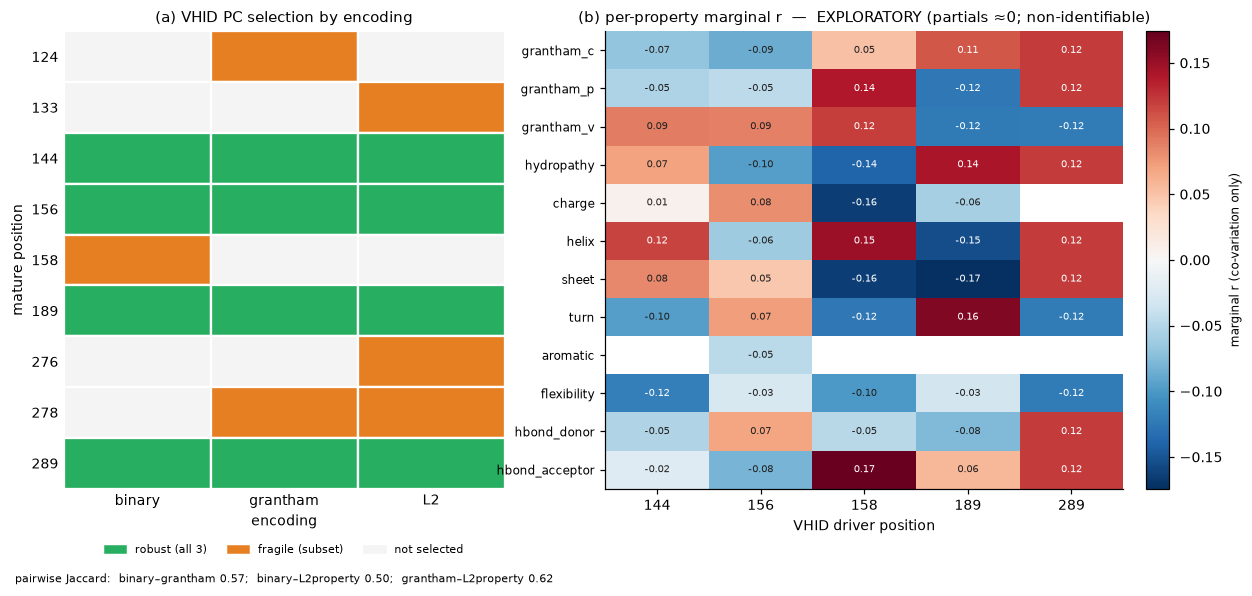

In [38]:
# §3.10.3 — (a) encoding-sensitivity selection matrix for VHID + pairwise Jaccard;
# (b) per-property marginal-r heatmap at VHID drivers (EXPLORATORY: partials ~0, non-identifiable).
# Re-plot from results/encoding_comparison.csv, encoding_jaccard.csv, per_property_drivers.csv.
ec = pd.read_csv("results/encoding_comparison.csv")
ej = pd.read_csv("results/encoding_jaccard.csv")
pp = pd.read_csv("results/per_property_drivers.csv")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4),
                         gridspec_kw={"width_ratios": [1.05, 1.35]})

# --- Panel (a): selection matrix, VHID_H3N2 ---
ev = ec[ec["dataset"] == "VHID_H3N2"].sort_values("position_mature").reset_index(drop=True)
enc_cols = ["sel_binary", "sel_grantham", "sel_L2property"]
enc_lbl  = ["binary", "grantham", "L2"]
M = ev[enc_cols].fillna(0).values.astype(float)
axA = axes[0]
# color: 0 = not selected (white), robust-position selected = green, fragile-position selected = orange
import matplotlib.patches as mpatches
for i, (_, r) in enumerate(ev.iterrows()):
    for j in range(3):
        if M[i, j] > 0:
            c = "#27ae60" if r["robust"] == 1 else "#e67e22"
        else:
            c = "#f4f4f4"
        axA.add_patch(mpatches.Rectangle((j, i), 1, 1, facecolor=c,
                                         edgecolor="white", lw=1.5))
axA.set_xlim(0, 3); axA.set_ylim(0, len(ev)); axA.invert_yaxis()
axA.set_xticks([0.5, 1.5, 2.5]); axA.set_xticklabels(enc_lbl)
axA.set_yticks([i + 0.5 for i in range(len(ev))])
axA.set_yticklabels([f"{int(p)}" for p in ev["position_mature"]])
axA.set_ylabel("mature position"); axA.set_xlabel("encoding")
axA.set_title("(a) VHID PC selection by encoding", fontsize=10)
for sp in axA.spines.values():
    sp.set_visible(False)
axA.tick_params(length=0)
leg = [mpatches.Patch(color="#27ae60", label="robust (all 3)"),
       mpatches.Patch(color="#e67e22", label="fragile (subset)"),
       mpatches.Patch(color="#f4f4f4", label="not selected")]
axA.legend(handles=leg, frameon=False, fontsize=7, loc="upper center",
           bbox_to_anchor=(0.5, -0.10), ncol=3)
jv = ej[ej["dataset"] == "VHID_H3N2"]
endash = "\u2013"
jtxt = "pairwise Jaccard:  " + ";  ".join(
    f"{p.replace('~', endash)} {j:.2f}" for p, j in zip(jv["pair"], jv["jaccard"]))
axA.text(0.5, -0.185, jtxt, transform=axA.transAxes, ha="center", va="top", fontsize=7.5)

# --- Panel (b): per-property marginal_r heatmap at VHID drivers ---
pv = pp[pp["dataset"] == "VHID"].copy()
props = ["grantham_c", "grantham_p", "grantham_v", "hydropathy", "charge", "helix",
         "sheet", "turn", "aromatic", "flexibility", "hbond_donor", "hbond_acceptor"]
positions = sorted(pv["position_mature"].unique())
H = pv.pivot_table(index="property", columns="position_mature",
                   values="marginal_r").reindex(index=props, columns=positions)
axB = axes[1]
vmax = np.nanmax(np.abs(H.values))
im = axB.imshow(H.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
axB.set_xticks(range(len(positions)))
axB.set_xticklabels([f"{int(p)}" for p in positions])
axB.set_yticks(range(len(props))); axB.set_yticklabels(props, fontsize=8)
axB.set_xlabel("VHID driver position"); 
axB.set_title("(b) per-property marginal r  \u2014  EXPLORATORY (partials \u22480; non-identifiable)",
              fontsize=9.5)
for i in range(len(props)):
    for j in range(len(positions)):
        v = H.values[i, j]
        if not np.isnan(v):
            axB.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                     color="white" if abs(v) > 0.6 * vmax else "#222222")
cb = fig.colorbar(im, ax=axB, fraction=0.046, pad=0.04)
cb.set_label("marginal r (co-variation only)", fontsize=8)
fig.savefig("results/fig_encoding_property.png", dpi=140, bbox_inches="tight")
plt.show()
robust_vhid = ev[ev["robust"] == 1]["position_mature"].tolist()
print("VHID robust (all 3 encodings):", robust_vhid)
print("158 selection -> binary:", int(ev.loc[ev.position_mature==158,'sel_binary'].iloc[0]),
      "grantham:", int(ev.loc[ev.position_mature==158,'sel_grantham'].iloc[0]),
      "L2:", int(ev.loc[ev.position_mature==158,'sel_L2property'].iloc[0]))

## 4. Conclusion

We set out to separate the HA positions that cause antigenic drift from those that merely accompany it, and the honest reading of what we achieved reframes the contribution: not a more accurate predictor of antigenic distance, but a more honest one — a model that names which residues its predictions lean on, reports how encoding-sensitive and how stable each of those choices is, and separates the part of every association that survives controlling for co-evolving sites from the part that does not.

Run on hemagglutination-inhibition titers alone, with no structural prior beyond the sink orientation, the pipeline concentrates its selected positions on the classical head antigenic sites — the residues serology and structural biology already implicate in escape — and it does so reproducibly across two independent H3N2 datasets. The positions that recur as high-stability are mature 156 and 189 in VHID and mature 133, 158, and 189 in Bedford, falling in antigenic site B (around 156–160 and 187–198, flanking the receptor-binding site) and site A (133); mature 157 and 158 are both site B, which retires an earlier "site D" label that misread alignment columns as mature residue numbers. Position 189 is a well-known determinant of H3N2 cluster transitions (Koel et al. 2013), so recovering it and its neighbors from titers alone tells us the feature matrix is tracking real antigenic biology rather than a dataset idiosyncrasy. What it does not tell us — and what we are careful not to claim — is that the causal step added identification over association: HI titer is by construction a readout of antibody binding to these very sites, so any method that extracts antigenic signal lands on the same residues, and the coincidence with known epitopes is necessary evidence that the associations are real, but not evidence that the causal search resolved cause from co-evolution.

That reservation is grounded in our own validation. The Shipley d-separation goodness-of-fit test rejects the pure titer-sink star on both datasets, because the retained positions co-evolve along a shared phylogeny and the star does not capture their residual dependence; the per-position effects of the backdoor analysis are therefore reported as partial-regression coefficients, not identified causal effects. Read that way they remain informative — every adjusted effect shrinks relative to its marginal counterpart and none flips sign, a pattern consistent with, but not identifying, the removal of phylogenetic confounding. Throughout, "stability" is a property of the selection procedure, not of causal correctness: a hitchhiker tightly linked to a true driver is selected in nearly every bootstrap for exactly the wrong reason, which is why VHID 156 — present in every strain but small and non-robust in effect — is best read as a stable hitchhiker, while 189 and the doubly-robust mature 289 carry the signal. Cluster resampling sharpens the boundary: the convergent pair 156/189 is robust, whereas the four-position VHID high-stability tier is an upper bound rather than a settled set.

Where the data cannot support residue-level attribution at all, the limiting factor is linkage. In H3N2 the largest pre-collapse blocks of co-evolving positions span 88 and 55 residues (block-size distribution, §[3.3.1](#3.3.1-Pre-collapse-linkage-block-sizes)); these absorb many head positions into single clade-linked units that no observational method can resolve internally, which is also why H3N2 has the lowest predictive ceiling. Beyond linkage, unmeasured drivers remain possible confounders — neuraminidase, glycosylation, non-HA1 regions, and receptor-binding avidity, which raw HI titer folds in alongside head-epitope binding (Hensley et al. 2009). Because the avidity-associated residues 145, 189, and 193 overlap our drivers, escape calls at 189 and 193 are mechanistically ambiguous under a raw-titer target: our readout is raw log2 HI titer, not the cartographic antigenic distance that separates serum potency, virus avidity, and true antigenic distance (Smith et al. 2004).

It follows that the promise most naturally attached to this work — anticipating escape for strains never seen serologically — is not something we have demonstrated, and we say so directly. No available test speaks to whether the discovered structure carries transportable causal content, so transportability of the causal structure, as opposed to the associations, is currently unevaluated. The closest present-day evidence of generalization is the leakage-free grouped cross-validation, and that is the number a downstream user should hold in mind: under the strictest grouping — predicting titers against a reference antiserum held out entirely — the strongest method reaches a median R² of roughly 0.615 on VHID and 0.50 on H3N2, well below the random-split figures near 0.85 and 0.61. That is the honest predictive headline, and it is modest.

Returning to the decision that opened this study — the twice-yearly bet on which strains next season's vaccine should target — the value of an honest model is that it marks its own edges. That the selected positions rediscover the classical head epitopes from titers alone is evidence the features are tracking real biology; that we cannot yet show the selection is causal, transportable, or robust to how substitutions are scored is a map of exactly where reverse-genetics single substitutions, denser linkage-breaking serum panels, and deep-mutational-scanning escape maps must take over. Extending the framework to other subtypes and lineages would test whether the convergence generalizes beyond H3N2. Reading antigenic distance from sequence remains within reach; reading its causes from sequence is the harder step that would let surveillance anticipate escape rather than only measure it, and this study marks honestly how far the current data can carry us.

## 5. References

1. **Smith, D. J., Lapedes, A. S., de Jong, J. C., Bestebroer, T. M., Rimmelzwaan,
   G. F., Osterhaus, A. D. M. E., Fouchier, R. A. M.** (2004). Mapping the antigenic
   and genetic evolution of influenza virus. *Science* **305**(5682), 371–376.
2. **Bedford, T., Suchard, M. A., Lemey, P., Dudas, G., Gregory, V., Hay, A. J.,
   McCauley, J. W., Russell, C. A., Smith, D. J., Rambaut, A.** (2014). Integrating
   influenza antigenic dynamics with molecular evolution. *eLife* **3**, e01914.
3. **Du, E., Zhong, Z., Wang, P., et al.** (2023). DPCIPI: A pre-trained deep learning
   model for predicting cross-immunity between drifted strains of Influenza A/H3N2.
   *arXiv:2302.00926.*
4. **Grantham, R.** (1974). Amino acid difference formula to help explain protein
   evolution. *Science* **185**(4154), 862–864.
5. **Spirtes, P., Glymour, C., Scheines, R.** (2000). *Causation, Prediction, and
   Search* (2nd ed.). MIT Press. (PC algorithm.)
6. **Chickering, D. M.** (2002). Optimal structure identification with greedy search.
   *Journal of Machine Learning Research* **3**, 507–554. (GES.)
7. **Zhang, J.** (2008). On the completeness of orientation rules for causal discovery
   in the presence of latent confounders and selection bias. *Artificial Intelligence*
   **172**(16–17), 1873–1896. (FCI.)
8. **Liu, Z., Wang, Y., Vaidya, S., et al.** (2024). KAN: Kolmogorov–Arnold Networks.
   *arXiv:2404.19756.*
9. **Pearl, J.** (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.).
   Cambridge University Press. (Backdoor adjustment / do-calculus.)
10. **Chen, T., Guestrin, C.** (2016). XGBoost: A scalable tree boosting system.
    *KDD 2016*, 785–794.
11. **Koel, B. F., Burke, D. F., Bestebroer, T. M., van der Vliet, S., Zondag, G. C. M.,
    Vervaet, G., Skepner, E., Lewis, N. S., Spronken, M. I. J., Russell, C. A., Eropkin,
    M. Y., Hurt, A. C., Barr, I. G., de Jong, J. C., Rimmelzwaan, G. F., Osterhaus, A. D.
    M. E., Fouchier, R. A. M., Smith, D. J.** (2013). Substitutions near the receptor
    binding site determine major antigenic change during influenza virus evolution.
    *Science* **342**(6161), 976–979.
12. **Neher, R. A., Bedford, T., Daniels, R. S., Russell, C. A., Shraiman, B. I.** (2016).
    Prediction, dynamics, and visualization of antigenic phenotypes of seasonal influenza
    viruses. *Proceedings of the National Academy of Sciences* **113**(12), E1701–E1709.
13. **Łuksza, M., Lässig, M.** (2014). A predictive fitness model for influenza. *Nature*
    **507**(7490), 57–61.
14. **Harvey, W. T., Benton, D. J., Gregory, V., Hall, J. P. J., Daniels, R. S., Bedford,
    T., Haydon, D. T., Hay, A. J., McCauley, J. W., Reeve, R.** (2016). Identification of
    low- and high-impact hemagglutinin amino acid substitutions that drive antigenic drift
    of influenza A(H3N2) viruses. *PLoS Pathogens* **12**(4), e1005526.
15. **Wiley, D. C., Wilson, I. A., Skehel, J. J.** (1981). Structural identification of the
    antibody-binding sites of Hong Kong influenza haemagglutinin and their involvement in
    antigenic variation. *Nature* **289**(5796), 373–378.
16. **Caton, A. J., Brownlee, G. G., Yewdell, J. W., Gerhard, W.** (1982). The antigenic
    structure of the influenza virus A/PR/8/34 hemagglutinin (H1 subtype). *Cell* **31**(2),
    417–427.
17. **Doud, M. B., Lee, J. M., Bloom, J. D.** (2018). How single mutations affect viral
    escape from broad and narrow antibodies to H1 influenza hemagglutinin. *Nature
    Communications* **9**, 1386.
18. **Lee, J. M., Eguia, R., Zost, S. J., Choudhary, S., Wilson, P. C., Bedford, T.,
    Stevens-Ayers, T., Boeckh, M., Hurt, A. C., Lakdawala, S. S., Hensley, S. E., Bloom,
    J. D.** (2019). Mapping person-to-person variation in viral mutations that escape
    polyclonal serum targeting influenza hemagglutinin. *eLife* **8**, e49324.
19. **Lou, Y., Caruana, R., Gehrke, J., Hooker, G.** (2013). Accurate intelligible models
    with pairwise interactions. *KDD 2013*, 623–631.
20. **Hensley, S. E., Das, S. R., Bailey, A. L., Schmidt, L. M., Hickman, H. D., Jayaraman, A.,
    Viswanathan, K., Raman, R., Sasisekharan, R., Bennink, J. R., Yewdell, J. W.** (2009).
    Hemagglutinin receptor binding avidity drives influenza A virus antigenic drift.
    *Science* **326**(5930), 734–736.

---

*Data: `influenza-hi-antigenic-distance` repository (CC0). Code and this notebook are
released alongside it. Causal discovery uses the `causal-learn` library; the KAN is a
custom PyTorch implementation in `src/bspline_kan.py`. The full pipeline — linkage
collapse, causal discovery, B-spline KAN, and cross-method convergence — is packaged
as the reusable `kan-causal-antigenic-workflow` skill.*